# EuroSAT land-use classification: RGB vs all 13 Sentinel-2 bands

**Question.** Sentinel-2 records 13 spectral bands, but most image models use only 3 (red, green,
blue). Does a pretrained vision transformer (ViT-S/16) classify land use better when it sees all 13
bands instead of RGB, with everything else kept the same?

**Short answer: no.** Both inputs reach about 99% test accuracy, and the 13-band model is
consistently a little *worse* (4 to 26 more wrong tiles out of 5,400, depending on the training
recipe). In the main test the gap is too small to be statistically significant (p = 0.13), but it
points the same way in every comparison.

**How the study is built.** Three experiments, each building on the previous one. Every decision
is made on the validation split (held-out tiles); the test split is only used to score the final
models, once.

| Experiment | Question | Runs (as named in the tables) |
|---|---|---|
| 1 · Sanity check | Before any training, are the models at chance level (~10%)? | `vit_rgb`, `vit_all_bands` (untrained) |
| 2 · Training recipe (RGB only) | Which training settings work best? Does data augmentation help? | `vit_rgb_baseline` (default recipe), a 40-trial Optuna search, then `vit_rgb_tuned` (arm A) vs `vit_rgb_tuned_aug` (arm B, + augmentation) |
| 3 · **Main question** | With that recipe, do 13 bands beat RGB? | `vit_all_bands_t20` vs `vit_rgb_tuned` |
| 3b · Robustness | Does the answer depend on the recipe (which was tuned on RGB)? | the 5 best recipes, each on RGB and on 13 bands: `vit_rgb_t23` / `vit_all_bands_t23`, t38, t37, t22 (t20 is Experiment 3) |
| Extra | The same question with the default recipe + augmentation | `vit_rgb`, `vit_all_bands` |

**How every model is trained.** Take a network pretrained on ImageNet photos and add a new output
layer for the 10 classes. Optionally train only that layer for a few *probe* epochs (backbone
frozen; one epoch = one pass over the training tiles), then fine-tune the whole network for up to
15 epochs. Training stops early when the validation loss (cross-entropy on held-out tiles; lower is
better) stops improving, and the weights with the lowest validation loss are kept.

**How to read this notebook.** Sections 2–8 are code (training engine, data, model, evaluation);
sections 9–11 run the experiments and compare them. Under every result there is a short note on
what it means. Section 8.1 explains the McNemar test used for all comparisons.

*Libraries:* torchgeo (EuroSAT), timm (pretrained backbone), PyTorch and PyTorch Ignite (training,
metrics), Optuna (hyperparameter search), scikit-learn, scipy, pandas, matplotlib and seaborn.

## 1. Setup

Install the libraries, import them, and define the constants used throughout: file paths, the 13
band names with their wavelengths, the pretrained backbone and the plot colours.

In [ ]:
%pip install -q torchgeo timm pytorch-ignite optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.4/812.4 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.8/371.8 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.2/891.2 kB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import json
import math
import random
import time
import sys
import copy
from collections.abc import Iterable, Sequence
from dataclasses import asdict, dataclass, field, fields, replace
from enum import Enum
from pathlib import Path
from typing import Any, Tuple, Dict, List, Optional, Union
import hashlib
from collections import defaultdict
from itertools import combinations
import math

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn as nn
import torchvision.transforms.v2 as T
from IPython.display import display
from ignite.metrics import Accuracy, Fbeta, Loss, Metric
from matplotlib.colors import PowerNorm
from matplotlib.ticker import MaxNLocator, PercentFormatter
from scipy.stats import binomtest
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import CosineAnnealingLR, LRScheduler, StepLR
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
from torchgeo.datasets import EuroSAT
from torch.nn import functional as F
from tqdm import tqdm   # Using plain text bar to prevent iterators from being kept alive

# --- CONSTANTS AND CONFIGURATION ---

# File paths
DATA_ROOT: Path = Path("data/eurosat")   # EuroSAT multispectral (~2 GB) download location
RESULTS_DIR: Path = Path("results")      # Storage for band statistics and arm results

# Dataset properties
TILE_SIZE: int = 64                      # EuroSAT tiles are 64 x 64 pixels
INPUT_SIZE: int = 224                    # Tiles are upsampled to the backbone's pretraining resolution
NUM_WORKERS: int = 2                     # Number of subprocesses for data loading

# Spectral Bands Configuration
# timm builds a 13-channel first layer by tiling pretrained RGB filters.
# RGB bands are placed first to match exactly the RGB model.
RGB_BANDS: Tuple[str, ...] = tuple(EuroSAT.rgb_bands)
ALL_BANDS: Tuple[str, ...] = tuple(EuroSAT.all_band_names)

# Central wavelength (nm) and usual name of every Sentinel-2 band
WAVELENGTH_NM: Dict[str, int] = {
    "B01": 443, "B02": 490, "B03": 560, "B04": 665, "B05": 705, "B06": 740, "B07": 783,
    "B08": 842, "B8A": 865, "B09": 945, "B10": 1375, "B11": 1610, "B12": 2190
}

BAND_LABELS: Dict[str, str] = {
    "B01": "coastal aerosol", "B02": "blue", "B03": "green", "B04": "red", "B05": "red edge 1",
    "B06": "red edge 2", "B07": "red edge 3", "B08": "NIR", "B8A": "narrow NIR", "B09": "water vapour",
    "B10": "cirrus", "B11": "SWIR 1", "B12": "SWIR 2"
}
BANDS_BY_WAVELENGTH: Tuple[str, ...] = tuple(sorted(ALL_BANDS, key=WAVELENGTH_NM.get))

# Model and Hardware Configuration
VIT_S16: str = "vit_small_patch16_224.augreg_in1k"  # Backbone pretrained on ImageNet-1k
DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Visualization Colors
SPLIT_COLORS: Dict[str, str] = {"train": "#2a78d6", "val": "#eb6834", "test": "#1baf7a"}
ARM_COLORS: Dict[str, str] = {
    "vit_rgb_baseline": "#7f7f7f",
    "vit_rgb_tuned": "#2a78d6",
    "vit_rgb_tuned_aug": "#eb6834",
    "vit_all_bands_tuned": "#a23bd6",
    "vit_rgb": "#1baf7a",
    "vit_all_bands": "#eda100"
}

# --- UTILITY FUNCTIONS ---

def float_format(x: float) -> str:
    """
    Format floats for table display:
    - 4 decimals by default.
    - Scientific notation for values below 1e-3.
    - 1 decimal for values >= 100.

    Args:
        x: The floating point value to format.

    Returns:
        A string representation of the float.
    """
    if x == 0 or not math.isfinite(x):
        return f"{x:.4f}"
    if abs(x) < 1e-3:
        return f"{x:.3e}"
    return f"{x:.1f}" if abs(x) >= 100 else f"{x:.4f}"


def round_sig(table: pd.DataFrame, digits: int = 6) -> pd.DataFrame:
    """
    Round floats in a DataFrame to a specified number of significant digits.

    Args:
        table: The pandas DataFrame to process.
        digits: The number of significant digits to retain.

    Returns:
        A new DataFrame with rounded float values.
    """
    return table.apply(
        lambda col: col.map(lambda x: float(f"{x:.{digits - 1}e}") if math.isfinite(x) else x)
        if col.dtype.kind == "f" else col
    )


pd.set_option("display.float_format", float_format)

print(f"torch {torch.__version__} | timm {timm.__version__} | device {DEVICE}")
print(f"13 bands in model order: {ALL_BANDS}")


torch 2.11.0+cu128 | timm 1.0.29 | device cuda
13 bands in model order: ('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A')


## 2. Training engine

A small, hand-written training loop shared by every run. One call does it all:
`model, history = train(model, train_ds, config, val_dataset=val_ds, callbacks=[...])`.
It trains, scores the validation split after every epoch, stops early when validation stops
improving, returns the best weights together with a full record of the run, and shows a progress
bar and a live plot while it works.

### 2.1 Configuration

Every setting of a run lives in one read-only `TrainingConfig` object, so two runs differ exactly
where their configs differ. `replace(config, ...)` makes a modified copy; `validate_config` rejects
bad values before a run starts. Settings worth knowing:

* `early_stopping_patience`: how many epochs without a new lowest validation loss before training
  stops; `restore_best_weights=True` then returns the best weights, not the last ones.
* `probe_epochs`: how many epochs the pretrained backbone stays frozen at the start (section 6).
* `weight_decay`: classic L2 regularisation for SGD and Adam, "decoupled" weight decay for AdamW.
* `mixed_precision=True`: computes in 16-bit floats on the GPU, which is faster.

In [ ]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for a training run. Describes optimisation, schedule, validation and runtime parameters."""
    # optimisation
    optimizer: str = "adamw"                    # "adamw", "adam" or "sgd"
    lr: float = 1e-3
    weight_decay: float = 1e-4
    momentum: float = 0.9                       # sgd only
    loss_fn: nn.Module = field(default_factory=nn.CrossEntropyLoss)
    grad_clip_norm: float | None = None
    mixed_precision: bool = False

    # schedule
    epochs: int = 30
    batch_size: int = 128
    lr_schedule: str | None = None              # "cosine", "step" or None; stepped once per epoch
    lr_step_size: int = 10
    lr_gamma: float = 0.1
    probe_epochs: int = 0                       # transfer learning: first epochs with the backbone frozen

    # validation
    val_every_n_steps: int | None = None
    early_stopping_patience: int | None = None
    restore_best_weights: bool = False
    val_metrics: dict[str, Metric] = field(default_factory=dict)

    # runtime
    device: str = "auto"
    num_workers: int = 0
    seed: int | None = None
    verbose: bool = True
    progress_every_n_steps: int = 50
    checkpoint_path: str | None = None


OPTIMIZERS = {"adamw": torch.optim.AdamW, "adam": torch.optim.Adam, "sgd": torch.optim.SGD}


def validate_config(config: TrainingConfig) -> None:
    """
    Validate the training configuration.

    Args:
        config: The TrainingConfig to validate.

    Raises:
        ValueError: If any configuration value is invalid.
    """
    if config.optimizer not in OPTIMIZERS:
        raise ValueError(f"optimizer must be one of {list(OPTIMIZERS)}, got {config.optimizer!r}")
    if config.lr_schedule not in (None, "cosine", "step"):
        raise ValueError(f"lr_schedule must be 'cosine', 'step' or None, got {config.lr_schedule!r}")
    if min(config.epochs, config.batch_size, config.progress_every_n_steps) < 1:
        raise ValueError("epochs, batch_size and progress_every_n_steps must be >= 1")
    if not 0 <= config.probe_epochs <= config.epochs:
        raise ValueError("probe_epochs must be between 0 and epochs")
    for name in ("val_every_n_steps", "early_stopping_patience"):
        if getattr(config, name) is not None and getattr(config, name) < 1:
            raise ValueError(f"{name} must be >= 1 or None")


def config_to_dict(config: TrainingConfig) -> dict[str, Any]:
    """
    JSON-friendly view of the config: objects are replaced by their class names.

    Args:
        config: The TrainingConfig to serialize.

    Returns:
        A dictionary representation of the config.
    """
    values = {f.name: getattr(config, f.name) for f in fields(config)}
    values["loss_fn"] = type(config.loss_fn).__name__
    values["val_metrics"] = {name: type(metric).__name__ for name, metric in config.val_metrics.items()}
    return values


### 2.2 Building blocks

Small helpers that turn the config into working PyTorch objects: the device, the random seed, the
optimizer, the learning-rate schedule and the data loaders.

In [ ]:
def resolve_device(config: TrainingConfig) -> torch.device:
    """
    Determine the appropriate PyTorch device based on the configuration.

    Args:
        config: The training configuration containing the device preference.

    Returns:
        The resolved torch.device (CUDA, MPS, or CPU).
    """
    if config.device != "auto":
        return torch.device(config.device)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def seed_everything(seed: int) -> None:
    """
    Set the seed for all random number generators to ensure reproducibility.

    Args:
        seed: The integer seed value to use.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def build_optimizer(config: TrainingConfig, model: nn.Module) -> torch.optim.Optimizer:
    """
    Construct the optimizer for the given model parameters based on the configuration.

    Args:
        config: The training configuration specifying optimizer type and hyperparameters.
        model: The PyTorch model whose parameters will be optimized.

    Returns:
        An instantiated PyTorch optimizer.
    """
    # All parameters go in: a frozen parameter has no gradient, so the optimizer skips it
    # (no update, no weight decay) until it is unfrozen.
    kwargs: dict[str, Any] = {"lr": config.lr, "weight_decay": config.weight_decay}
    if config.optimizer == "sgd":
        kwargs["momentum"] = config.momentum
    return OPTIMIZERS[config.optimizer](model.parameters(), **kwargs)


def build_scheduler(config: TrainingConfig, optimizer: torch.optim.Optimizer) -> LRScheduler | None:
    """
    Create a learning rate scheduler based on the training configuration.

    Args:
        config: The training configuration specifying the schedule type.
        optimizer: The optimizer to attach the scheduler to.

    Returns:
        The configured learning rate scheduler, or None if no schedule is specified.
    """
    if config.lr_schedule == "cosine":
        return CosineAnnealingLR(optimizer, T_max=config.epochs)
    if config.lr_schedule == "step":
        return StepLR(optimizer, step_size=config.lr_step_size, gamma=config.lr_gamma)
    return None


def build_loader(config: TrainingConfig, dataset: Dataset, train: bool) -> DataLoader:
    """
    Build a PyTorch DataLoader for the given dataset.

    Args:
        config: The training configuration (batch size, workers, seed).
        dataset: The dataset to load from.
        train: Whether this loader is for training (enables shuffling and drops smaller batch multiplier).

    Returns:
        A configured PyTorch DataLoader.
    """
    generator = torch.Generator().manual_seed(config.seed) if train and config.seed is not None else None
    return DataLoader(
        dataset,
        batch_size=config.batch_size if train else 4 * config.batch_size,   # no gradients: bigger batches fit
        shuffle=train,
        generator=generator,
        num_workers=config.num_workers,
        persistent_workers=config.num_workers > 0,
        pin_memory=torch.cuda.is_available(),
    )


### 2.3 What a run records

`train` returns the model and a `TrainingHistory`: one entry per training step (loss, accuracy,
batch size, learning rate) and one per validation. The loss is cross-entropy: it is low when the
model gives a high probability to the correct class, so it rewards being right *and* sure. Three
versions of it appear in the notebook:

* **Batch loss:** the loss of a single training step (the value the optimizer actually used).
* **Training loss per epoch:** the average over all training tiles of that epoch.
* **Validation loss:** the average over all validation tiles. Early stopping, the choice of the
  best epoch and the Optuna search are all based on this number.

Averages are weighted by batch size, so every tile counts once even when the last batch is smaller.
`epoch_table(history)` summarises a run per epoch; its `phase` column says whether an epoch was a
*probe* epoch (backbone frozen) or a *fine-tune* epoch (whole network trained).

In [ ]:
class StopReason(str, Enum):
    """Enumeration of reasons for stopping the training loop."""
    COMPLETED = "completed"
    EARLY_STOPPING = "early stopping"
    CALLBACK = "stopped by callback"
    ERROR = "error"


@dataclass(frozen=True)
class BatchMetrics:
    """
    Metrics recorded for a single training batch.
    """
    epoch: int
    step: int                # global step, 1-based
    batch_index: int         # 1-based, within the epoch
    batch_size: int | None   # samples in this batch (the last batch of an epoch can be smaller)
    batch_loss: float        # the step loss: mean loss over this batch, the exact value backward() used
    accuracy: float          # top-1 accuracy of this batch
    lr: float


@dataclass(frozen=True)
class ValidationMetrics:
    """
    Metrics recorded during a validation phase.
    """
    epoch: int
    step: int
    loss: float                                             # sum(batch_size * batch loss) / n_val
    accuracy: float
    improved: bool                                          # lowest validation loss so far
    extra: dict[str, float] = field(default_factory=dict)   # values of config.val_metrics


@dataclass
class TrainingHistory:
    """
    Complete history of a training run, including batch and validation metrics.
    """
    batches: list[BatchMetrics] = field(default_factory=list)
    validations: list[ValidationMetrics] = field(default_factory=list)
    probe_epochs: int = 0      # epochs trained with the backbone frozen
    steps_per_epoch: int = 0   # batches per epoch


@dataclass
class TrainerState:
    """
    Live state of the training process, passed to callbacks and engine functions.
    """
    config: TrainingConfig
    model: nn.Module
    optimizer: torch.optim.Optimizer
    device: torch.device
    steps_per_epoch: int
    amp_dtype: torch.dtype | None                    # None: mixed precision off
    scaler: torch.amp.GradScaler
    train_accuracy: Accuracy                         # per-batch training accuracy
    val_loss: Loss                                   # validation loss
    val_metrics: dict[str, Metric]                   # "accuracy" + config.val_metrics
    history: TrainingHistory = field(default_factory=TrainingHistory)
    epoch: int = 0
    step: int = 0
    best_val_loss: float = math.inf
    best_weights: dict[str, torch.Tensor] | None = None   # CPU copy of best model weights
    validations_since_best: int = 0
    stop_training: bool = False                      # flag to request stopping
    stop_reason: StopReason | None = None
    error: BaseException | None = None
    start_time: float = field(default_factory=time.perf_counter)


def elapsed_seconds(state: TrainerState) -> float:
    """
    Calculate the elapsed time in seconds since training started.

    Args:
        state: The current trainer state.

    Returns:
        Elapsed time in seconds.
    """
    return time.perf_counter() - state.start_time


def current_lr(optimizer: torch.optim.Optimizer) -> float:
    """
    Get the current learning rate from the optimizer.

    Args:
        optimizer: The PyTorch optimizer.

    Returns:
        The current learning rate as a float.
    """
    return float(optimizer.param_groups[0]["lr"])


def batch_table(history: TrainingHistory) -> pd.DataFrame:
    """
    Create a DataFrame of batch metrics.

    Args:
        history: The training history.

    Returns:
        A pandas DataFrame with one row per training step.
    """
    return pd.DataFrame([asdict(b) for b in history.batches])


def epoch_table(history: TrainingHistory) -> pd.DataFrame:
    """
    Create a DataFrame summarising metrics per epoch.

    Args:
        history: The training history.

    Returns:
        A pandas DataFrame with one row per epoch, containing weighted training loss,
        accuracy, and validation metrics.
    """
    batches = batch_table(history)
    weight = pd.to_numeric(batches.batch_size).fillna(1.0)   # no batch sizes (older history): plain mean over batches
    batches["weighted_loss"], batches["weighted_acc"], batches["weight"] = batches.batch_loss * weight, batches.accuracy * weight, weight
    per_epoch = batches.groupby("epoch")
    table = pd.DataFrame({"train_loss": per_epoch.weighted_loss.sum() / per_epoch.weight.sum(),
                          "train_acc": per_epoch.weighted_acc.sum() / per_epoch.weight.sum(),
                          "lr": per_epoch.lr.last()})
    if history.validations:
        validations = pd.DataFrame([{"epoch": v.epoch, "val_loss": v.loss, "val_acc": v.accuracy, **v.extra}
                                    for v in history.validations])
        table = table.join(validations.groupby("epoch").last())
    table.insert(0, "phase", np.where(table.index <= history.probe_epochs, "probe", "fine-tune"))
    return table


def history_to_dict(history: TrainingHistory) -> dict[str, Any]:
    """
    Convert the training history to a JSON-compatible dictionary.

    Args:
        history: The training history object.

    Returns:
        A dictionary representation of the history.
    """
    return {"probe_epochs": history.probe_epochs, "steps_per_epoch": history.steps_per_epoch,
            "batches": [asdict(b) for b in history.batches],
            "validations": [asdict(v) for v in history.validations]}


def history_from_dict(data: dict[str, Any]) -> TrainingHistory:
    """
    Reconstruct a TrainingHistory object from a dictionary.

    Args:
        data: The dictionary representation of the history.

    Returns:
        A reconstructed TrainingHistory object.
    """
    batches = []
    for b in data["batches"]:
        b = {"batch_size": None, **b}                     # a history saved by an older version of this notebook has
        b.setdefault("batch_loss", b.pop("loss", None))   # no batch sizes and calls the step loss "loss"
        batches.append(BatchMetrics(**b))
    return TrainingHistory(batches, [ValidationMetrics(**v) for v in data["validations"]],
                           probe_epochs=data.get("probe_epochs", 0), steps_per_epoch=data.get("steps_per_epoch", 0))


### 2.4 Callbacks and the progress bar

Everything beyond the bare loop (progress bar, live plot, freezing and unfreezing the backbone,
Optuna pruning) plugs in as a `Callback` that is called at fixed moments: start of training, end of
each batch, after each validation, end of training. This keeps the loop itself short.
`TqdmProgress` shows one bar per run with the epoch, loss, accuracy, validation results and
learning rate.

In [ ]:
class Callback:
    """Base class for all training callbacks."""
    def on_train_begin(self, state: TrainerState) -> None:
        """Called at the beginning of the training run."""
        ...
    def on_epoch_begin(self, state: TrainerState) -> None:
        """Called at the beginning of each epoch."""
        ...
    def on_batch_end(self, state: TrainerState, batch: BatchMetrics, validation: ValidationMetrics | None) -> None:
        """Called at the end of each training batch."""
        ...
    def on_validation_end(self, state: TrainerState, validation: ValidationMetrics) -> None:
        """Called at the end of each validation phase."""
        ...
    def on_epoch_end(self, state: TrainerState) -> None:
        """Called at the end of each epoch."""
        ...
    def on_train_end(self, state: TrainerState) -> None:
        """Called at the end of the training run, regardless of success or failure."""
        ...


class CallbackList(Callback):
    """A collection of callbacks that dispatches events to each of them."""
    def __init__(self, callbacks: Iterable[Callback] = ()) -> None:
        self.callbacks = list(callbacks)

    def on_train_begin(self, state: TrainerState) -> None:
        for cb in self.callbacks:
            cb.on_train_begin(state)

    def on_epoch_begin(self, state: TrainerState) -> None:
        for cb in self.callbacks:
            cb.on_epoch_begin(state)

    def on_batch_end(self, state: TrainerState, batch: BatchMetrics, validation: ValidationMetrics | None) -> None:
        for cb in self.callbacks:
            cb.on_batch_end(state, batch, validation)

    def on_validation_end(self, state: TrainerState, validation: ValidationMetrics) -> None:
        for cb in self.callbacks:
            cb.on_validation_end(state, validation)

    def on_epoch_end(self, state: TrainerState) -> None:
        for cb in self.callbacks:
            cb.on_epoch_end(state)

    def on_train_end(self, state: TrainerState) -> None:
        # Run every callback even if one fails (so the bar closes and the plot is final), then re-raise.
        first_error = None
        for cb in self.callbacks:
            try:
                cb.on_train_end(state)
            except Exception as exc:
                first_error = first_error or exc
        if first_error is not None and state.error is None:
            raise first_error


def percent(x: float) -> str:
    """Format a float as a percentage string with 2 decimal places."""
    return f"{100 * x:.2f}%"


class TqdmProgress(Callback):
    """Callback that displays a progress bar and logs metrics using tqdm."""
    def __init__(self, every_n_steps: int = 50) -> None:
        self.every_n_steps = every_n_steps
        self._bar = None
        self._last_val: ValidationMetrics | None = None

    def on_train_begin(self, state: TrainerState) -> None:
        cfg = state.config
        tqdm.write(f"Training on {state.device} ({cfg.optimizer}, {cfg.epochs} epochs x {state.steps_per_epoch} steps).")
        self._last_val = None
        self._bar = tqdm(total=cfg.epochs * state.steps_per_epoch, desc="Training", unit="step", dynamic_ncols=True, file=sys.stdout)

    def on_batch_end(self, state: TrainerState, batch: BatchMetrics, validation: ValidationMetrics | None) -> None:
        if validation is not None:
            self._last_val = validation
        if validation is not None or batch.step % self.every_n_steps == 0 or batch.step == 1:
            val = self._last_val
            postfix = {
                "epoch": f"{batch.epoch}/{state.config.epochs}",
                "loss": f"{batch.batch_loss:.4f}",
                "acc": percent(batch.accuracy),
                "val_loss": f"{val.loss:.4f}" if val else "-",
                "val_acc": percent(val.accuracy) if val else "-",
            }
            for name in state.config.val_metrics:
                postfix[f"val_{name}"] = f"{val.extra[name]:.4f}" if val else "-"
            postfix["lr"] = f"{batch.lr:.3g}"
            self._bar.set_postfix(postfix)
        self._bar.update(1)

    def on_train_end(self, state: TrainerState) -> None:
        if self._bar is not None:
            self._bar.close()
            self._bar = None
        if state.error is not None:
            return
        if state.stop_reason is StopReason.EARLY_STOPPING:
            tqdm.write(f"Early stopping: no lower validation loss for {state.config.early_stopping_patience} "
                       f"validations (best {state.best_val_loss:.4f}).")
        else:
            tqdm.write(f"Training {state.stop_reason.value} after {state.step} steps in {elapsed_seconds(state):.1f}s.")


### 2.5 Live training plot

A 2 × 2 figure that updates while a run trains (blue = training, orange = validation):

* **Top row, per step:** loss (left) and accuracy (right) of every training batch (faint = raw,
  solid = smoothed), with the validation results as dots.
* **Bottom row, per epoch:** the same, averaged per epoch.

A dotted vertical line marks the switch from probe to fine-tuning. `plot_history(history)` redraws
the figure for a finished run.

*Reading it:* training and validation curves that stay close mean the model generalises; training
still improving while validation stays flat means the model has started to memorise the training
tiles.

In [ ]:
TRAIN_COLOR, VAL_COLOR = "#2a78d6", "#eb6834"
INK, INK_MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
PLOT_STYLE: dict[str, str] = {
    "axes.facecolor": SURFACE, "figure.facecolor": SURFACE, "axes.edgecolor": GRID, "grid.color": GRID,
    "text.color": INK, "axes.labelcolor": INK_MUTED, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
}


def exponential_moving_average(values: Sequence[float], smoothing: float) -> list[float]:
    """
    Calculate the exponential moving average of a sequence of values.

    Args:
        values: The sequence of float values.
        smoothing: The smoothing factor between 0 and 1.

    Returns:
        A list of smoothed float values.
    """
    out, avg = [], None
    for v in values:
        avg = v if avg is None else smoothing * avg + (1 - smoothing) * v
        out.append(avg)
    return out


class TrainingPlot:
    """
    A 2 x 2 grid for visualizing training progress.

    Top row, per step: loss and accuracy of every training batch (faint = raw, solid = smoothed)
    and the validation results at their step.
    Bottom row, per epoch: the mean over the epoch's batches for
    training (the last point is the running mean of the epoch in progress) and the epoch's validation.
    A dotted line marks the end of the probe epochs. While training runs the x-axes grow with it and keep a
    little room ahead of the last step and epoch; once it is over they fit the steps and epochs actually run.
    """

    def __init__(self, smoothing: float = 0.8, figsize: tuple[float, float] = (11, 7.5), dpi: int = 90) -> None:
        """
        Initialize the TrainingPlot.

        Args:
            smoothing: The smoothing factor for the exponential moving average.
            figsize: The figure size in inches.
            dpi: The figure resolution in dots per inch.
        """
        self.smoothing = smoothing
        self._lines: dict[str, tuple[Any, Any, Any]] = {}
        self._probe_marked = False
        with sns.axes_style("whitegrid", rc=PLOT_STYLE), sns.plotting_context("notebook", font_scale=0.9):
            self.fig, axes = plt.subplots(2, 2, figsize=figsize, dpi=dpi, layout="constrained")
            self.fig.get_layout_engine().set(w_pad=0.25, h_pad=0.35, wspace=0.08, hspace=0.14)  # space between panels
            self.axes = {"step_loss": axes[0, 0], "step_acc": axes[0, 1], "epoch_loss": axes[1, 0], "epoch_acc": axes[1, 1]}
            titles = {"step_loss": "Loss per step", "step_acc": "Accuracy per step",
                      "epoch_loss": "Loss per epoch", "epoch_acc": "Accuracy per epoch"}
            for key, ax in self.axes.items():
                per_step = key.startswith("step")
                raw = ax.plot([], [], color=TRAIN_COLOR, lw=1, alpha=0.25)[0] if per_step else None
                train, = ax.plot([], [], color=TRAIN_COLOR, lw=2, marker=None if per_step else "o", ms=5, mec=SURFACE,
                                 mew=1, label="train (smoothed)" if per_step else "train (epoch mean)")
                val, = ax.plot([], [], color=VAL_COLOR, lw=2, marker="o", ms=6, mec=SURFACE, mew=1.5, label="validation")
                self._lines[key] = (raw, train, val)
                ax.set_title(titles[key], loc="left", fontweight="semibold")
                ax.set_xlabel("step" if per_step else "epoch")
                ax.legend(loc="upper right" if key.endswith("loss") else "lower right", frameon=False)
            for key in ("step_acc", "epoch_acc"):
                self.axes[key].yaxis.set_major_formatter(PercentFormatter(1.0))
            for key in ("epoch_loss", "epoch_acc"):
                self.axes[key].xaxis.set_major_locator(MaxNLocator(integer=True))
            sns.despine(fig=self.fig)

    def update(self, history: TrainingHistory, subtitle: str = "", growing: bool = False) -> None:
        """
        Update the plots with the latest training history.

        Args:
            history: The current training history.
            subtitle: An optional subtitle for the figure.
            growing: Whether the plot x-axes should expand to make room for future steps.
        """
        if not history.batches:
            return
        steps = [b.step for b in history.batches]
        val_steps = [v.step for v in history.validations]
        per_step = {"step_loss": ([b.batch_loss for b in history.batches], [v.loss for v in history.validations]),
                    "step_acc": ([b.accuracy for b in history.batches], [v.accuracy for v in history.validations])}
        for key, (train_values, val_values) in per_step.items():
            raw, train, val = self._lines[key]
            raw.set_data(steps, train_values)
            train.set_data(steps, exponential_moving_average(train_values, self.smoothing))
            val.set_data(val_steps, val_values)

        table = epoch_table(history)   # one row per epoch; the last row is the epoch in progress
        per_epoch = {"epoch_loss": ("train_loss", "val_loss"), "epoch_acc": ("train_acc", "val_acc")}
        for key, (train_col, val_col) in per_epoch.items():
            _, train, val = self._lines[key]
            train.set_data(table.index, table[train_col])
            if val_col in table:
                with_val = table[val_col].dropna()
                val.set_data(with_val.index, with_val)

        # Known from the loader since the start of the run, so the probe line is not placed from the few batches seen
        # at the first redraw. A history saved without it (older version) falls back to the longest epoch seen.
        steps_per_epoch = history.steps_per_epoch or max(b.batch_index for b in history.batches)
        if history.probe_epochs and not self._probe_marked:
            self._mark_probe(history.probe_epochs, steps_per_epoch)
        last_step, last_epoch = steps[-1], history.batches[-1].epoch
        for key, ax in self.axes.items():
            ax.relim()
            ax.autoscale_view(scalex=False)
            if key.startswith("step"):   # growing: the last step plus an offset of a fifth of an epoch
                ax.set_xlim(0, last_step + max(10, steps_per_epoch // 5) if growing else last_step)
            else:                        # growing: one epoch of room ahead
                ax.set_xlim(0.5, last_epoch + 1 if growing else last_epoch + 0.5)
        self.fig.suptitle(subtitle, x=0.01, ha="left", fontsize=10, color=INK_MUTED)

    def _mark_probe(self, probe_epochs: int, steps_per_epoch: int) -> None:
        """
        Mark the end of the probe epochs with a vertical dashed line.

        Args:
            probe_epochs: The number of probe epochs.
            steps_per_epoch: The number of steps in each epoch.
        """
        for key, ax in self.axes.items():
            x = probe_epochs * steps_per_epoch + 0.5 if key.startswith("step") else probe_epochs + 0.5
            ax.axvline(x, color="gray", ls=":", lw=1)
            if key.endswith("loss"):   # label at the bottom, away from the legend and the early (high) losses
                ax.text(x, 0.02, " probe | fine-tune", transform=ax.get_xaxis_transform(), fontsize=8, va="bottom", color="gray", clip_on=True)
        self._probe_marked = True


class LivePlot(Callback):
    """
    Shows a TrainingPlot under the progress bar and keeps it updated while training runs.
    """

    def __init__(self, min_interval_s: float = 0.5, smoothing: float = 0.8) -> None:
        """
        Initialize the LivePlot callback.

        Args:
            min_interval_s: Minimum time in seconds between plot redraws.
            smoothing: The smoothing factor for the exponential moving average.
        """
        self.min_interval_s = min_interval_s
        self.smoothing = smoothing
        self.plot: TrainingPlot | None = None
        self._handle = None
        self._last_draw = 0.0

    def on_train_begin(self, state: TrainerState) -> None:
        self.plot = TrainingPlot(self.smoothing)
        self._handle = display(self.plot.fig, display_id=True)
        plt.close(self.plot.fig)   # we refresh it ourselves; stop the inline backend from showing it a second time
        self._last_draw = time.perf_counter()

    def on_batch_end(self, state: TrainerState, batch: BatchMetrics, validation: ValidationMetrics | None) -> None:
        if validation is not None or time.perf_counter() - self._last_draw >= self.min_interval_s:
            self._redraw(state)

    def on_train_end(self, state: TrainerState) -> None:
        if self.plot is not None:
            self._redraw(state)   # the final picture always contains every step

    def _redraw(self, state: TrainerState) -> None:
        total_steps = state.config.epochs * state.steps_per_epoch
        status = f"epoch {state.epoch}/{state.config.epochs}  ·  step {state.step}/{total_steps}"
        if state.stop_reason is not None:
            status += f"  ·  {state.stop_reason.value}"
        self.plot.update(state.history, subtitle=status, growing=state.stop_reason is None)
        if self._handle is not None:
            self._handle.update(self.plot.fig)
        self._last_draw = time.perf_counter()


def plot_history(history: TrainingHistory, title: str = "", smoothing: float = 0.8) -> plt.Figure:
    """
    The same 2 x 2 figure for a finished run (or a history loaded from disk).

    Args:
        history: The training history to plot.
        title: An optional title for the plot.
        smoothing: The smoothing factor for the exponential moving average.

    Returns:
        The generated matplotlib Figure.
    """
    plot = TrainingPlot(smoothing)
    subtitle = f"{len(history.batches)} steps, {len(history.validations)} validations"
    plot.update(history, subtitle=f"{title}  ·  {subtitle}" if title else subtitle)
    plt.close(plot.fig)   # the returned figure is shown once as the cell's result
    return plot.fig


### 2.6 Training loop

`train(model, train_dataset, config, val_dataset=None, callbacks=())` is the entry point. Each
training step runs the batch forward, computes the loss, backpropagates, updates the weights and
records the batch's loss and accuracy. After each epoch the model is scored on the whole
validation split (loss, accuracy, F1). Whenever the validation loss hits a new low, a copy of the
weights is kept, and that copy is loaded back at the end.

Details that keep the numbers honest: the recorded batch loss is exactly the value that was
optimised (never recomputed); the validation loss is averaged per tile, not per batch; with mixed
precision the gradients are scaled to avoid underflow in 16-bit, and a step whose gradients
overflow is skipped.

In [ ]:
def as_float(name: str, value: Any) -> float:
    """
    Convert a metric value to a float.

    Args:
        name: The name of the metric (used for error messages).
        value: The value to convert, either a scalar or a 1-element torch.Tensor.

    Returns:
        The float representation of the value.

    Raises:
        ValueError: If the value is a tensor with more than one element.
    """
    if isinstance(value, torch.Tensor):
        if value.numel() != 1:
            raise ValueError(
                f"metric {name!r} returned {value.numel()} values; use an averaged version, "
                f"e.g. Precision(average='macro')"
            )
        value = value.item()
    return float(value)



@torch.inference_mode()
def predict(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute labels, predicted classes, and softmax probabilities over a whole loader.

    Args:
        model: The trained PyTorch model.
        loader: DataLoader for the dataset to predict on.
        device: The PyTorch device.

    Returns:
        A tuple containing arrays of true labels, predicted classes, and probabilities.
    """
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    for x, y in loader:
        probabilities = model(x.to(device, non_blocking=True)).float().softmax(dim=1).cpu()
        y_true.append(y)
        y_pred.append(probabilities.argmax(dim=1))
        y_prob.append(probabilities)
    return torch.cat(y_true).numpy(), torch.cat(y_pred).numpy(), torch.cat(y_prob).numpy()


@torch.inference_mode()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    loss_metric: Loss,
    metrics: dict[str, Metric],
    amp_dtype: torch.dtype | None = None,
) -> dict[str, float]:
    """
    Compute loss and given metrics over the whole loader.

    Results are accumulated in the provided Ignite metric objects.
    The loss is sum(batch_size * batch loss) / number of samples, because
    Ignite's Loss weights every batch by its size.

    Args:
        model: The model to evaluate.
        loader: The DataLoader providing the evaluation data.
        device: The device to perform evaluation on.
        loss_metric: The Ignite Loss metric object to accumulate loss.
        metrics: A dictionary of additional Ignite Metric objects.
        amp_dtype: The dtype for mixed precision (if any).

    Returns:
        A dictionary of metric names mapped to their computed float values.
    """
    was_training = model.training
    model.eval()
    try:
        # Reset: the same metric objects are reused for every validation of the run.
        loss_metric.reset()
        for metric in metrics.values():
            metric.reset()

        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.autocast(device.type, dtype=amp_dtype, enabled=amp_dtype is not None):
                output = model(x)

            # The Loss metric runs the loss function once per batch and accumulates batch_size * batch loss,
            # so compute() is the loss per sample over the whole loader, not a mean over batches.
            # Compute validation loss in FP32 for numerical stability.
            loss_metric.update((output.float(), y))
            for metric in metrics.values():
                metric.update((output, y))

        return {
            "loss": float(loss_metric.compute()),
            **{name: as_float(name, metric.compute()) for name, metric in metrics.items()}
        }
    finally:
        model.train(was_training)


def train_step(
    state: TrainerState,
    loss_fn: nn.Module,
    x: torch.Tensor,
    y: torch.Tensor,
    batch_index: int
) -> BatchMetrics:
    """
    Perform a single training step on a batch of data.

    Args:
        state: The current state of the trainer.
        loss_fn: The loss function.
        x: The input features.
        y: The target labels.
        batch_index: The current batch index within the epoch.

    Returns:
        BatchMetrics containing the loss, accuracy, and other statistics for this step.
    """
    model, optimizer, scaler = state.model, state.optimizer, state.scaler

    # Make sure callbacks cannot leave the model in eval mode.
    model.train()

    x = x.to(state.device, non_blocking=True)
    y = y.to(state.device, non_blocking=True)

    # Forward pass. The loss computed here is the exact loss that backward() will use.
    with torch.autocast(state.device.type, dtype=state.amp_dtype, enabled=state.amp_dtype is not None):
        output = model(x)
        loss = loss_fn(output, y)

    # Backward pass and optimizer update.
    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    # .grad now holds the true, unscaled gradients (no-op when the scaler is disabled)
    scaler.unscale_(optimizer)

    if state.config.grad_clip_norm is not None:
        # Unscale before clipping so we clip the real gradients.
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), state.config.grad_clip_norm)

    # The scaler automatically skips the step if gradients overflow.
    scaler.step(optimizer)
    scaler.update()
    state.step += 1

    # Batch metrics. The step loss needs no metric object: 'loss' is already the exact value used for
    # backward(), so do NOT call loss_fn(output, y) again; it is recorded with the batch size, which
    # epoch_table needs to weight the epoch mean. Accuracy is an Ignite metric on the state, reset first
    # because we want the accuracy of THIS batch, not an accumulation over the epoch.
    batch_loss = loss.detach().item()
    state.train_accuracy.reset()
    state.train_accuracy.update((output.detach(), y))
    batch_accuracy = float(state.train_accuracy.compute())

    metrics = BatchMetrics(
        state.epoch,
        state.step,
        batch_index,
        len(y),
        batch_loss,
        batch_accuracy,
        current_lr(optimizer)
    )
    state.history.batches.append(metrics)
    return metrics


def validation_due(config: TrainingConfig, step: int, batch_index: int, steps_per_epoch: int) -> bool:
    """
    Determine if a validation phase is due at the current step.

    Args:
        config: The training configuration.
        step: The overall global step.
        batch_index: The batch index in the current epoch.
        steps_per_epoch: The total number of batches in an epoch.

    Returns:
        True if validation should be performed now, False otherwise.
    """
    if config.val_every_n_steps is None:
        return batch_index == steps_per_epoch
    return step % config.val_every_n_steps == 0


def track_best(state: TrainerState, val_loss: float) -> bool:
    """
    Record a validation loss and keep track of the best weights.

    Args:
        state: The trainer state.
        val_loss: The latest validation loss.

    Returns:
        True if the validation loss improved compared to the previous best, False otherwise.
    """
    improved = val_loss < state.best_val_loss
    if improved:
        state.best_val_loss = val_loss
        state.validations_since_best = 0
        if state.config.restore_best_weights:
            state.best_weights = {k: v.detach().cpu().clone() for k, v in state.model.state_dict().items()}
    else:
        state.validations_since_best += 1
    return improved


def early_stopping_triggered(state: TrainerState) -> bool:
    """
    Check if early stopping conditions have been met.

    Args:
        state: The trainer state containing early stopping tracking.

    Returns:
        True if early stopping is triggered, False otherwise.
    """
    patience = state.config.early_stopping_patience
    return patience is not None and state.validations_since_best >= patience


def save_checkpoint(path: str | Path, model: nn.Module, config: TrainingConfig, history: TrainingHistory) -> Path:
    """
    Save the current model weights, configuration, and training history to disk.

    Args:
        path: The file path to save the checkpoint to.
        model: The model to save.
        config: The training configuration.
        history: The current training history.

    Returns:
        The resolved path where the checkpoint was saved.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        "state_dict": model.state_dict(),
        "config": config_to_dict(config),
        "history": history_to_dict(history)
    }, path)
    return path


def run_epochs(
    state: TrainerState,
    loss_fn: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader | None,
    scheduler: LRScheduler | None,
    callbacks: CallbackList
) -> None:
    """
    Run the main training loop across multiple epochs.

    Args:
        state: The current trainer state.
        loss_fn: The loss function.
        train_loader: The data loader for training.
        val_loader: The data loader for validation, or None to skip validation.
        scheduler: An optional learning rate scheduler.
        callbacks: The list of callbacks to invoke at various phases.
    """
    cfg, model = state.config, state.model
    for epoch in range(1, cfg.epochs + 1):
        state.epoch = epoch
        model.train()
        callbacks.on_epoch_begin(state)

        for batch_index, (x, y) in enumerate(train_loader, 1):
            batch = train_step(state, loss_fn, x, y, batch_index)   # also records the batch in the history
            validation = None
            if val_loader is not None and validation_due(cfg, state.step, batch_index, state.steps_per_epoch):
                results = evaluate(model, val_loader, state.device, state.val_loss, state.val_metrics, state.amp_dtype)
                loss, accuracy = results.pop("loss"), results.pop("accuracy")
                validation = ValidationMetrics(
                    epoch,
                    state.step,
                    loss,
                    accuracy,
                    improved=track_best(state, loss),
                    extra=results
                )
                state.history.validations.append(validation)

            callbacks.on_batch_end(state, batch, validation)
            if validation is not None:
                callbacks.on_validation_end(state, validation)

            if early_stopping_triggered(state):
                state.stop_reason = StopReason.EARLY_STOPPING
            elif state.stop_training:
                state.stop_reason = StopReason.CALLBACK

            if state.stop_reason is not None:
                break

        callbacks.on_epoch_end(state)
        if state.stop_reason is not None:
            break
        if scheduler is not None:
            scheduler.step()

    if state.stop_reason is None:
        state.stop_reason = StopReason.COMPLETED


def train(
    model: nn.Module,
    train_dataset: Dataset,
    config: TrainingConfig,
    val_dataset: Dataset | None = None,
    callbacks: Sequence[Callback] = ()
) -> tuple[nn.Module, TrainingHistory]:
    """
    Initialize and execute the training process for a model.

    Args:
        model: The PyTorch model to train.
        train_dataset: The dataset for training.
        config: The training configuration object.
        val_dataset: The dataset for validation, or None if unused.
        callbacks: A sequence of callbacks for hooking into the training loop.

    Returns:
        A tuple containing the trained model (optionally with best weights restored)
        and the full training history.

    Raises:
        ValueError: If the training dataset is empty.
    """
    validate_config(config)
    if config.seed is not None:
        seed_everything(config.seed)

    device = resolve_device(config)
    model = model.to(device)
    loss_fn = config.loss_fn.to(device)

    optimizer = build_optimizer(config, model)
    scheduler = build_scheduler(config, optimizer)
    train_loader = build_loader(config, train_dataset, train=True)
    val_loader = build_loader(config, val_dataset, train=False) if val_dataset is not None else None

    if len(train_loader) == 0:
        raise ValueError("train_dataset is empty")

    amp_dtype = None
    if config.mixed_precision:
        amp_dtype = torch.float16 if device.type == "cuda" else torch.bfloat16

    state = TrainerState(
        config,
        model,
        optimizer,
        device,
        steps_per_epoch=len(train_loader),
        amp_dtype=amp_dtype,
        scaler=torch.amp.GradScaler(device.type, enabled=amp_dtype is torch.float16),
        train_accuracy=Accuracy(device=device),
        val_loss=Loss(loss_fn, device=device),   # sum(batch_size * batch loss) / n_val
        val_metrics={"accuracy": Accuracy(device=device), **config.val_metrics},
        history=TrainingHistory(probe_epochs=config.probe_epochs, steps_per_epoch=len(train_loader)),
    )

    progress = [TqdmProgress(config.progress_every_n_steps)] if config.verbose else []
    callbacks_list = CallbackList([*progress, *callbacks])

    try:
        callbacks_list.on_train_begin(state)
        run_epochs(state, loss_fn, train_loader, val_loader, scheduler, callbacks_list)
        if state.best_weights is not None:
            model.load_state_dict(state.best_weights)
        if config.checkpoint_path:
            save_checkpoint(config.checkpoint_path, model, config, state.history)
    except BaseException as exc:
        state.error, state.stop_reason = exc, StopReason.ERROR
        raise
    finally:
        callbacks_list.on_train_end(state)

    return model, state.history


### 2.7 Two checks of the training engine

Because the loop is hand-written, two tests on a tiny made-up problem check that it does what it
claims before any real result is trusted. Both print `all checks passed`.

* **Mechanics** (first cell): the model is in training mode only while it trains, and in
  evaluation mode without gradients while it is validated; each step uses only its own batch's
  gradient; with mixed precision, a step whose gradients overflow is skipped (the last line forces
  this on the GPU).
* **Loss definitions** (second cell): the recorded losses match values recomputed by hand. The
  printout also shows why averaging per tile matters: a plain mean over batches gives a slightly
  different number when the last batch is smaller (1.243 instead of 1.253 in the first example).

In [ ]:
class ProbeModel(nn.Module):
    """
    A linear classifier that records its operational mode during every forward pass.

    Records a tuple of: (model.training, torch.is_grad_enabled(), output dtype).
    """

    def __init__(self, in_features: int = 8, num_classes: int = 3) -> None:
        super().__init__()
        self.linear = nn.Linear(in_features, num_classes)
        self.calls: List[Tuple[bool, bool, torch.dtype]] = []

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.linear(x)
        self.calls.append((self.training, torch.is_grad_enabled(), out.dtype))
        return out


class RecordingDataset(Dataset):
    """
    Wraps a dataset and records the order in which the loader accessed its items.

    This allows tests to rebuild the exact batches the engine trained on without
    assuming anything about the loader's shuffling behavior.
    """

    def __init__(self, base: Dataset) -> None:
        self.base = base
        self.served: List[int] = []

    def __len__(self) -> int:
        return len(self.base)

    def __getitem__(self, i: int) -> Any:
        self.served.append(i)
        return self.base[i]


class EngineRecorder(Callback):
    """
    Records internal engine states after train() that are not normally exposed.

    Tracks:
        - The scaler and AMP dtype chosen.
        - The weight gradient left on the model after every step.
        - Whether every gradient of the model was finite.
        - The scaler's scale factor before training and after every step.
    """

    def __init__(self) -> None:
        self.scaler: Any = None
        self.amp_dtype: torch.dtype | None = None
        self.grads: List[torch.Tensor] = []
        self.finite: List[bool] = []
        self.scales: List[float] = []

    def on_train_begin(self, state: Any) -> None:
        self.scaler = state.scaler
        self.amp_dtype = state.amp_dtype
        self.scales.append(state.scaler.get_scale())  # initial scale (65536 when enabled, 1 when not)

    def on_batch_end(self, state: Any, batch: Any, validation: Any) -> None:
        self.grads.append(state.model.linear.weight.grad.detach().float().cpu().clone())

        is_finite = all(
            bool(torch.isfinite(p.grad).all())
            for p in state.model.parameters() if p.grad is not None
        )
        self.finite.append(is_finite)
        self.scales.append(state.scaler.get_scale())


def reference_gradient(state_dict: Dict[str, torch.Tensor], x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Compute the float32 gradient of the mean cross-entropy of one batch w.r.t. the weights.

    This is computed outside the engine (plain autograd, no autocast, no scaler)
    using the given parameters, as a reference.
    """
    ref = ProbeModel()
    ref.load_state_dict(state_dict)
    F.cross_entropy(ref(x), y).backward()
    return ref.linear.weight.grad.clone()


def describe(grad: torch.Tensor, expected: torch.Tensor) -> str:
    """
    Describe the mismatch between the recorded gradient and the expected reference.

    A scale of ~65536 means the gradient was never unscaled. Inf/NaN indicates
    a float16 overflow. A small max diff means the tolerance is too tight for half precision.
    """
    finite = torch.isfinite(grad).all().item()
    ratio = (grad / expected).median().item() if finite else float("nan")
    max_diff = (grad - expected).abs().max().item()
    return f"finite={finite}, median grad/expected ratio={ratio:.4g}, max |diff|={max_diff:.3g}"


def test_engine_mechanics(mixed_precision: bool, device: str, lr: float = 0.0, seed: int = 0) -> None:
    """
    Runs one epoch on a synthetic problem (batches of 2) plus one validation to check:
      1. Modes: Training forwards run in train mode with autograd on; validation
         and predict() forwards run in eval mode with autograd OFF.
      2. Zero_grad: Gradients must belong to their own batch alone, and single steps
         must unscale gradients properly before updating.
      3. AMP / GradScaler: Proper use of float16 on CUDA, bfloat16 on CPU. Loss must
         remain unscaled, and scaler handles overflow gracefully.
    """
    n_train = 6 if lr == 0 else 2
    g = torch.Generator().manual_seed(seed)

    # Inputs are scaled by 0.5 to keep float16 gradients well inside representable range.
    x_train, y_train = 0.5 * torch.randn(n_train, 8, generator=g), torch.randint(0, 3, (n_train,), generator=g)
    x_val, y_val = 0.5 * torch.randn(4, 8, generator=g), torch.randint(0, 3, (4,), generator=g)

    config = TrainingConfig(
        optimizer="sgd", lr=lr, momentum=0.0, weight_decay=0.0, epochs=1, batch_size=2,
        device=device, mixed_precision=mixed_precision, num_workers=0, verbose=False, seed=seed
    )

    torch.manual_seed(seed)
    model = ProbeModel()
    state0 = {k: v.detach().clone() for k, v in model.state_dict().items()}

    recorder, train_ds = EngineRecorder(), RecordingDataset(TensorDataset(x_train, y_train))
    model, history = train(model, train_ds, config, val_dataset=TensorDataset(x_val, y_val), callbacks=[recorder])

    amp = recorder.amp_dtype is not None
    tol = dict(rtol=5e-2, atol=2e-3) if amp else dict(rtol=1e-4, atol=1e-6)
    n_steps = n_train // 2

    # 1. modes ------------------------------------------------------------------------------------------------
    train_calls, val_calls = model.calls[:n_steps], model.calls[n_steps:]
    assert len(val_calls) == 1 and all(c[:2] == (True, True) for c in train_calls), "training forwards: train mode, autograd on"
    assert val_calls[0][0] is False, "evaluate() must run the model in eval mode"
    assert val_calls[0][1] is False, "evaluate() must run under torch.inference_mode(): autograd was ON during validation"
    assert model.training, "train() must hand the model back in train mode"

    w_end = model.linear.weight.detach().float().cpu().clone()
    model.calls.clear()
    predict(model, build_loader(config, TensorDataset(x_val, y_val), train=False), resolve_device(config))
    assert model.calls[0][:2] == (False, False), "predict() must run in eval mode with autograd off"
    assert torch.equal(model.linear.weight.detach().float().cpu(), w_end), "inference must not change the weights"

    # 2. zero_grad and the update ---------------------------------------------------------------------------------
    order = train_ds.served
    assert sorted(order) == list(range(n_train)), f"one epoch must serve every sample once, got {order}"
    batches = [(x_train[order[k:k + 2]], y_train[order[k:k + 2]]) for k in range(0, n_train, 2)]
    finite = [bool(torch.isfinite(g_).all()) for g_ in recorder.grads]

    if lr == 0:
        for i, ((x, y), grad, ok) in enumerate(zip(batches, recorder.grads, finite), 1):
            if not ok:
                continue
            expected = reference_gradient(state0, x, y)
            assert torch.allclose(grad, expected, **tol), f"step {i}: gradient is not that of batch {i} alone ({describe(grad, expected)})"
        if finite[0] and finite[1]:
            accumulated = reference_gradient(state0, *batches[0]) + reference_gradient(state0, *batches[1])
            assert not torch.allclose(recorder.grads[1], accumulated, **tol), "step 2 gradient looks accumulated over steps 1 and 2"
    elif finite[0]:
        expected = state0["linear.weight"] - lr * reference_gradient(state0, *batches[0])
        assert torch.allclose(w_end, expected, **tol), f"the step did not apply w -= lr * (unscaled) grad ({describe(w_end, expected)})"
    else:
        assert torch.equal(w_end, state0["linear.weight"]), "an overflowed step must be skipped, but the weights changed"

    # 3. AMP and the GradScaler -------------------------------------------------------------------------------
    dev = resolve_device(config).type
    expected_dtype = {(True, "cuda"): torch.float16, (True, "cpu"): torch.bfloat16}.get((mixed_precision, dev))
    assert recorder.amp_dtype == expected_dtype, f"amp dtype {recorder.amp_dtype} on {dev}, expected {expected_dtype}"
    assert recorder.scaler.is_enabled() == (expected_dtype is torch.float16), "GradScaler must be enabled exactly for float16"
    assert all(c[2] == (expected_dtype or torch.float32) for c in train_calls + val_calls), "forwards must run in the AMP dtype"

    scales = recorder.scales
    for i, ok in enumerate(finite, 1):
        expected_scale = scales[i - 1] if ok else scales[i - 1] / 2
        assert scales[i] == expected_scale, f"step {i}: scale {scales[i - 1]:g} -> {scales[i]:g} but the gradient was {'finite' if ok else 'not finite'}"

    if not recorder.scaler.is_enabled():
        assert all(finite), "without a scaler every gradient must be finite"

    if lr == 0:
        ref = ProbeModel()
        ref.load_state_dict(state0)
        for (x, y), b in zip(batches, history.batches):
            expected_loss = F.cross_entropy(ref(x), y).item()
            assert math.isclose(b.batch_loss, expected_loss, rel_tol=tol["rtol"], abs_tol=tol["atol"]), "batch_loss must be the unscaled loss"

    skipped = finite.count(False)
    print(f"ok: device={dev}, mixed_precision={mixed_precision} -> amp dtype {recorder.amp_dtype}, "
          f"scaler enabled={recorder.scaler.is_enabled()}, scale {scales[0]:g} -> {scales[-1]:g}, "
          f"steps skipped for overflow: {skipped}, lr={lr}")


def test_gradscaler_skips_overflow(seed: int = 0) -> None:
    """
    CUDA only: Verify that the GradScaler properly skips the update and halves the scale
    when the float16 gradient overflows due to exceptionally large inputs.
    """
    g = torch.Generator().manual_seed(seed)
    x, y = 1e4 * torch.randn(2, 8, generator=g), torch.randint(0, 3, (2,), generator=g)
    config = TrainingConfig(
        optimizer="sgd", lr=0.1, momentum=0.0, weight_decay=0.0, epochs=1, batch_size=2,
        device="cuda", mixed_precision=True, num_workers=0, verbose=False, seed=seed
    )
    torch.manual_seed(seed)
    model = ProbeModel()
    w0 = model.linear.weight.detach().clone()
    recorder = EngineRecorder()

    model, history = train(model, TensorDataset(x, y), config, callbacks=[recorder])

    assert not torch.isfinite(recorder.grads[0]).all(), "expected the float16 gradient to overflow on this batch"
    assert torch.equal(model.linear.weight.detach().cpu(), w0), "the scaler must skip the optimizer step after an overflow"
    assert recorder.scales == [65536.0, 32768.0], f"the scale must halve after an overflow, got {recorder.scales}"
    print(f"ok: overflow handled -> step skipped, scale {recorder.scales[0]:g} -> {recorder.scales[1]:g}")


if __name__ == "__main__":
    # Run execution mechanics tests across different precision configurations
    for mp in (False, True):
        test_engine_mechanics(mixed_precision=mp, device="cpu", lr=0.0)
        test_engine_mechanics(mixed_precision=mp, device="cpu", lr=0.1)

    if torch.cuda.is_available():
        test_engine_mechanics(mixed_precision=True, device="cuda", lr=0.0)
        test_engine_mechanics(mixed_precision=True, device="cuda", lr=0.1)
        test_gradscaler_skips_overflow()

    print("Engine mechanics: all checks passed")


ok: device=cpu, mixed_precision=False -> amp dtype None, scaler enabled=False, scale 1 -> 1, steps skipped for overflow: 0, lr=0.0
ok: device=cpu, mixed_precision=False -> amp dtype None, scaler enabled=False, scale 1 -> 1, steps skipped for overflow: 0, lr=0.1
ok: device=cpu, mixed_precision=True -> amp dtype torch.bfloat16, scaler enabled=False, scale 1 -> 1, steps skipped for overflow: 0, lr=0.0
ok: device=cpu, mixed_precision=True -> amp dtype torch.bfloat16, scaler enabled=False, scale 1 -> 1, steps skipped for overflow: 0, lr=0.1
ok: device=cuda, mixed_precision=True -> amp dtype torch.float16, scaler enabled=True, scale 65536 -> 65536, steps skipped for overflow: 0, lr=0.0
ok: device=cuda, mixed_precision=True -> amp dtype torch.float16, scaler enabled=True, scale 65536 -> 65536, steps skipped for overflow: 0, lr=0.1
ok: overflow handled -> step skipped, scale 65536 -> 32768
Engine mechanics: all checks passed


In [ ]:
def is_close(a: float, b: float, rel_tol: float = 1e-5, abs_tol: float = 1e-6) -> bool:
    """
    Check if two floats are approximately equal using float32 tolerances.

    Args:
        a: First float value.
        b: Second float value.
        rel_tol: Relative tolerance.
        abs_tol: Absolute tolerance.

    Returns:
        True if values are close within the specified tolerances, False otherwise.
    """
    return math.isclose(a, b, rel_tol=rel_tol, abs_tol=abs_tol)


def generate_synthetic_data(
    num_samples: int,
    features: int = 8,
    classes: int = 3,
    seed: int = 0
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Generate synthetic features and targets for testing.

    Args:
        num_samples: Number of samples to generate.
        features: Number of feature dimensions.
        classes: Number of distinct classes.
        seed: Random seed for reproducibility.

    Returns:
        A tuple of (features_tensor, targets_tensor).
    """
    generator = torch.Generator().manual_seed(seed)
    x = torch.randn(num_samples, features, generator=generator)
    y = torch.randint(0, classes, (num_samples,), generator=generator)
    return x, y


def test_loss_definitions(
    n_train: int = 7,
    n_val: int = 11,
    batch_size: int = 2,
    features: int = 8,
    classes: int = 3,
    lr: float = 0.0,
    seed: int = 0
) -> None:
    """
    Validate the three loss definitions of the training engine.

    The definitions verified are:
      1. batch_loss: Mean cross-entropy of a single batch (used by backward()).
      2. train_loss: Weighted mean of batch losses per epoch.
      3. validation loss: Weighted mean of validation batch losses.

    Args:
        n_train: Number of training samples.
        n_val: Number of validation samples.
        batch_size: The batch size used for training.
        features: Number of input features.
        classes: Number of output classes.
        lr: Learning rate. Set to 0.0 to verify batch-level consistency exactly.
        seed: Random seed for reproducibility.
    """
    # 1. Prepare synthetic data and configuration
    x_train, y_train = generate_synthetic_data(n_train, features, classes, seed=seed)
    x_val, y_val = generate_synthetic_data(n_val, features, classes, seed=seed)

    config = TrainingConfig(
        optimizer="sgd", lr=lr, weight_decay=0.0, epochs=1, batch_size=batch_size,
        device="cpu", mixed_precision=False, num_workers=0, verbose=False, seed=seed
    )

    torch.manual_seed(seed)
    model, history = train(
        nn.Linear(features, classes),
        TensorDataset(x_train, y_train),
        config,
        val_dataset=TensorDataset(x_val, y_val)
    )
    model.eval()

    batches = history.batches

    # Verify the expected batch sizes dynamically
    expected_batch_sizes = [batch_size] * (n_train // batch_size)
    if n_train % batch_size != 0:
        expected_batch_sizes.append(n_train % batch_size)

    actual_batch_sizes = [b.batch_size for b in batches]
    assert actual_batch_sizes == expected_batch_sizes, f"Expected batch sizes {expected_batch_sizes}, got {actual_batch_sizes}"

    # 2. Batch Loss Validation (Exact Match)
    if lr == 0.0:
        with torch.no_grad():
            train_loader = build_loader(config, TensorDataset(x_train, y_train), train=True)
            for batch_metric, (x_batch, y_batch) in zip(batches, train_loader):
                recomputed_loss = F.cross_entropy(model(x_batch), y_batch).item()
                assert batch_metric.batch_size == len(y_batch), "Batch size mismatch"
                assert is_close(batch_metric.batch_loss, recomputed_loss), (
                    f"Batch {batch_metric.batch_index}: recorded {batch_metric.batch_loss:.6f} "
                    f"!= recomputed {recomputed_loss:.6f}"
                )

    # 3. Epoch Training Loss Validation
    weighted_train_loss = sum(b.batch_size * b.batch_loss for b in batches) / n_train
    unweighted_train_loss = sum(b.batch_loss for b in batches) / len(batches)
    reported_train_loss = epoch_table(history).train_loss.iloc[0]

    assert is_close(reported_train_loss, weighted_train_loss), (
        f"Reported train loss {reported_train_loss:.6f} != weighted calculation {weighted_train_loss:.6f}"
    )

    if lr == 0.0:
        with torch.no_grad():
            per_sample_train_loss = F.cross_entropy(model(x_train), y_train).item()
        assert is_close(reported_train_loss, per_sample_train_loss), (
            f"Reported train loss {reported_train_loss:.6f} != per-sample mean {per_sample_train_loss:.6f}"
        )

    # 4. Validation Loss Validation
    val_metric = history.validations[-1]
    val_batch_size = config.batch_size * 4  # validation batch size from build_loader

    with torch.no_grad():
        per_sample_val_loss = F.cross_entropy(model(x_val), y_val).item()

        # Recompute weighted validation loss dynamically based on chunks
        val_losses = []
        for i in range(0, n_val, val_batch_size):
            x_b = x_val[i:i + val_batch_size]
            y_b = y_val[i:i + val_batch_size]
            val_losses.append((len(y_b), F.cross_entropy(model(x_b), y_b).item()))

        weighted_val_mean = sum(size * loss for size, loss in val_losses) / n_val

    assert is_close(val_metric.loss, per_sample_val_loss), (
        f"Validation loss {val_metric.loss:.6f} != per-sample mean {per_sample_val_loss:.6f}"
    )
    assert is_close(val_metric.loss, weighted_val_mean), "Validation loss is not correctly batch-size-weighted"

    # 5. Output Summary
    print(f"lr={lr}: batch losses {[round(b.batch_loss, 4) for b in batches]} with sizes {actual_batch_sizes}")
    print(f"  train_loss {reported_train_loss:.6f} = weighted {weighted_train_loss:.6f} "
          f"(unweighted mean of batches would be {unweighted_train_loss:.6f})")

    mean_of_val_batch_means = sum(loss for _, loss in val_losses) / len(val_losses)
    print(f"  val_loss   {val_metric.loss:.6f} = per-sample mean {per_sample_val_loss:.6f} "
          f"(mean of the {len(val_losses)} batch means would be {mean_of_val_batch_means:.6f})")


if __name__ == "__main__":
    # Run verifications
    test_loss_definitions(lr=0.0)    # Checks 1, 2, and 3 exactly
    test_loss_definitions(lr=0.1)    # Checks 2 and 3 while the model is learning
    print("Loss definitions: all checks passed")


lr=0.0: batch losses [1.4621, 1.4685, 0.8674, 1.1724] with sizes [2, 2, 2, 1]
  train_loss 1.252638 = weighted 1.252638 (unweighted mean of batches would be 1.242611)
  val_loss   0.760057 = per-sample mean 0.760057 (mean of the 2 batch means would be 0.699523)
lr=0.1: batch losses [1.4621, 1.383, 1.0749, 1.1369] with sizes [2, 2, 2, 1]
  train_loss 1.282427 = weighted 1.282427 (unweighted mean of batches would be 1.264241)
  val_loss   1.014679 = per-sample mean 1.014679 (mean of the 2 batch means would be 1.000145)
Loss definitions: all checks passed


## 3. Experiment design

An **experiment** groups the **arms** (runs) that answer one question. All arms of an experiment
use the same training recipe, so they differ only in the input bands and/or augmentation, and any
difference in results can be put down to that.

The recipe is chosen in Experiment 2, on RGB only, in three steps:

1. **Baseline:** a sensible default recipe (AdamW, learning rate 1e-4, weight decay 0.05, batch
   size 64, 3 probe epochs, cosine learning-rate decay), without augmentation.
2. **Optuna search** (40 trials) over the optimizer (AdamW, Adam or SGD), learning rate, weight
   decay, batch size, number of probe epochs, learning-rate schedule and, for SGD, momentum. Each
   trial is one full RGB training run, scored by its lowest **validation** loss; the test split is
   never used. The baseline counts as trial 0, so the search can only match or beat it. Trials
   that fall clearly behind are stopped early ("pruned") to save time.
3. **Augmentation:** the best recipe without (arm A) and with augmentation (arm B), compared on the
   validation split. Augmentation is kept only if B is significantly better (McNemar p < 0.05).

Fixed throughout: at most 15 epochs, early stopping after 5 epochs without improvement, seed 0,
the same data split.

**Experiment 3** then trains the 13-band model with the chosen recipe and compares it with the
matching RGB run on the test split: the single pre-planned main test. **Experiment 3b** repeats
the pair for the five best recipes of the search, because a recipe tuned on RGB might favour RGB.

The next cell prints the design: the runs defined so far with their recipes, and the search space
next to the baseline value of every tuned setting.

In [ ]:
@dataclass(frozen=True)
class Arm:
    """
    Represents a single experimental arm.

    Attributes:
        name: Short identifier for the arm.
        description: Human-readable description.
        backbone: The name of the timm model to use.
        bands: A tuple of input band names in the correct order.
        augment: Whether to apply geometric data augmentation.
    """
    name: str
    description: str
    backbone: str
    bands: tuple[str, ...]
    augment: bool


@dataclass(frozen=True)
class Experiment:
    """
    Groups a set of arms answering a specific research question.

    Attributes:
        name: Short identifier for the experiment.
        question: The research question this experiment addresses.
        arms: A tuple of Arm objects belonging to this experiment.
        config: The TrainingConfig shared across all arms in this experiment.
    """
    name: str
    question: str
    arms: tuple[Arm, ...]
    config: TrainingConfig


BASELINE_CONFIG = TrainingConfig(
    optimizer="adamw",
    lr=1e-4,
    weight_decay=0.05,
    epochs=15,
    probe_epochs=3,
    batch_size=64,
    lr_schedule="cosine",
    early_stopping_patience=5,
    restore_best_weights=True,
    val_metrics={"f1": Fbeta(1.0, device=DEVICE)},
    mixed_precision=torch.cuda.is_available(),
    num_workers=NUM_WORKERS,
    progress_every_n_steps=20,
    seed=0,
)
validate_config(BASELINE_CONFIG)

# Hyperparameters for Experiment 2 tuning.
TUNED_OPTIMIZERS = ("adamw", "sgd", "adam")
LR_RANGE = {"adamw": (1e-5, 1e-3), "sgd": (1e-3, 1e-1), "adam": (1e-5, 1e-3)}
LR_SCHEDULES = ("cosine", "step", None)
WEIGHT_DECAY_RANGE = (1e-4, 1e-1)
BATCH_SIZES = (32, 64, 128, 256)
PROBE_EPOCH_CHOICES = (0, 1, 3, 5)
MOMENTUM_RANGE = (0.8, 0.99)
N_TRIALS = 40
RECIPE_FIELDS = (
    "optimizer", "lr", "weight_decay", "epochs",
    "probe_epochs", "batch_size", "lr_schedule",
    "early_stopping_patience", "seed", "momentum"
)


def suggest_recipe(trial: optuna.Trial) -> dict[str, Any]:
    """
    Propose a set of hyperparameters for one Optuna trial.

    Args:
        trial: The current Optuna trial.

    Returns:
        A dictionary of hyperparameter kwargs to update the BASELINE_CONFIG.
    """
    optimizer = trial.suggest_categorical("optimizer", TUNED_OPTIMIZERS)
    recipe = {
        "optimizer": optimizer,
        "lr": trial.suggest_float(f"lr_{optimizer}", *LR_RANGE[optimizer], log=True),
        "weight_decay": trial.suggest_float("weight_decay", *WEIGHT_DECAY_RANGE, log=True),
        "batch_size": trial.suggest_categorical("batch_size", BATCH_SIZES),
        "probe_epochs": trial.suggest_categorical("probe_epochs", PROBE_EPOCH_CHOICES),
        "lr_schedule": trial.suggest_categorical("lr_schedule", LR_SCHEDULES)
    }
    if optimizer == "sgd":
        recipe["momentum"] = trial.suggest_float("momentum", *MOMENTUM_RANGE)
    return recipe


def recipe_from_params(params: dict[str, Any]) -> dict[str, Any]:
    """
    Convert a trial's param dictionary back to config keyword arguments.

    Args:
        params: The parameters chosen by Optuna.

    Returns:
        A dictionary mapped to the TrainingConfig fields.
    """
    optimizer = params["optimizer"]
    recipe = {
        "optimizer": optimizer,
        "lr": params[f"lr_{optimizer}"],
        "weight_decay": params["weight_decay"],
        "batch_size": params["batch_size"],
        "probe_epochs": params["probe_epochs"],
        "lr_schedule": params.get("lr_schedule", BASELINE_CONFIG.lr_schedule)
    }
    if optimizer == "sgd":
        recipe["momentum"] = params.get("momentum", BASELINE_CONFIG.momentum)
    return recipe




def recipe_params(config: TrainingConfig) -> dict[str, Any]:
    """
    Convert a TrainingConfig to Optuna trial params.

    Args:
        config: The TrainingConfig to map.

    Returns:
        A dictionary representing the configuration as trial parameters.
    """
    params =  {
        "optimizer": config.optimizer,
        f"lr_{config.optimizer}": config.lr,
        "weight_decay": config.weight_decay,
        "batch_size": config.batch_size,
        "probe_epochs": config.probe_epochs,
        "lr_schedule": config.lr_schedule
    }
    if config.optimizer == "sgd":
        params["momentum"] = config.momentum
    return params


SEARCH_SPACE = {
    "optimizer": optuna.distributions.CategoricalDistribution(TUNED_OPTIMIZERS),
    **{f"lr_{name}": optuna.distributions.FloatDistribution(low, high, log=True)
       for name, (low, high) in LR_RANGE.items()},
    "weight_decay": optuna.distributions.FloatDistribution(*WEIGHT_DECAY_RANGE, log=True),
    "batch_size": optuna.distributions.CategoricalDistribution(BATCH_SIZES),
    "probe_epochs": optuna.distributions.CategoricalDistribution(PROBE_EPOCH_CHOICES),
    "lr_schedule": optuna.distributions.CategoricalDistribution(LR_SCHEDULES),
    "momentum": optuna.distributions.FloatDistribution(*MOMENTUM_RANGE),
}

VIT_RGB = Arm("vit_rgb", "ViT-S/16 + RGB + augmentation", VIT_S16, RGB_BANDS, augment=True)
VIT_ALL_BANDS = Arm("vit_all_bands", "ViT-S/16 + 13 bands + augmentation", VIT_S16, ALL_BANDS, augment=True)

EXPERIMENT_1 = Experiment(
    name="experiment_1",
    question="Before training: is the pretrained ViT-S/16 with a new head at chance level, on RGB and on 13 bands?",
    arms=(VIT_RGB, VIT_ALL_BANDS),
    config=BASELINE_CONFIG,
)

EXPERIMENT_2_BASELINE = Experiment(
    name="experiment_2_baseline",
    question="The default recipe on RGB without augmentation: the reference of the search and of arm A.",
    arms=(Arm("vit_rgb_baseline", "ViT-S/16 + RGB, default recipe", VIT_S16, RGB_BANDS, augment=False),),
    config=BASELINE_CONFIG,
)

EXPERIMENT_EXTRA = Experiment(
    name="extra",
    question="Earlier runs: does the answer hold with the default recipe and augmentation?",
    arms=(VIT_RGB, VIT_ALL_BANDS),
    config=BASELINE_CONFIG,
)


def design_table(experiments: tuple[Experiment, ...]) -> pd.DataFrame:
    """
    Create a summary table of the given experiments and their arms.

    Args:
        experiments: A tuple of Experiment objects.

    Returns:
        A pandas DataFrame detailing the experiment designs.
    """
    rows = []
    for experiment in experiments:
        for arm in experiment.arms:
            rows.append({
                "experiment": experiment.name,
                "arm": arm.name,
                "backbone": arm.backbone,
                "bands": len(arm.bands),
                "augment": arm.augment,
                **{name: getattr(experiment.config, name) for name in RECIPE_FIELDS}
            })
    return pd.DataFrame(rows).set_index(["experiment", "arm"])


def search_space_table() -> pd.DataFrame:
    """
    Create a table summarizing the hyperparameter search space and baseline values.

    Returns:
        A pandas DataFrame displaying searched and baseline values for tuned hyperparameters.
    """
    return pd.DataFrame({
        "searched": [
            ", ".join(TUNED_OPTIMIZERS),
            "; ".join(f"{name} {low:g} to {high:g} (log)" for name, (low, high) in LR_RANGE.items()),
            f"{WEIGHT_DECAY_RANGE[0]:g} to {WEIGHT_DECAY_RANGE[1]:g} (log)",
            ", ".join(map(str, BATCH_SIZES)),
            ", ".join(map(str, PROBE_EPOCH_CHOICES)),
            ", ".join(str(s) for s in LR_SCHEDULES),
            f"{MOMENTUM_RANGE[0]:g} to {MOMENTUM_RANGE[1]:g} (sdg only)"
        ],
        "baseline": [
            BASELINE_CONFIG.optimizer,
            BASELINE_CONFIG.lr,
            BASELINE_CONFIG.weight_decay,
            BASELINE_CONFIG.batch_size,
            BASELINE_CONFIG.probe_epochs,
            BASELINE_CONFIG.lr_schedule,
            BASELINE_CONFIG.momentum
        ],
    }, index=pd.Index(["optimizer", "lr", "weight_decay", "batch_size", "probe_epochs", "lr_schedule", "momentum"], name="tuned"))


display(design_table((EXPERIMENT_2_BASELINE, EXPERIMENT_EXTRA)))
search_space_table()


backbone  \
experiment            arm                                                   
experiment_2_baseline vit_rgb_baseline  vit_small_patch16_224.augreg_in1k   
extra                 vit_rgb           vit_small_patch16_224.augreg_in1k   
                      vit_all_bands     vit_small_patch16_224.augreg_in1k   

                                        bands  augment optimizer        lr  \
experiment            arm                                                    
experiment_2_baseline vit_rgb_baseline      3    False     adamw 1.000e-04   
extra                 vit_rgb               3     True     adamw 1.000e-04   
                      vit_all_bands        13     True     adamw 1.000e-04   

                                        weight_decay  epochs  probe_epochs  \
experiment            arm                                                    
experiment_2_baseline vit_rgb_baseline        0.0500      15             3   
extra                 vit_rgb                 0.0500      15             3   
                      vit_all_bands           0.0500      15             3   

                                        batch_size lr_schedule  \
experiment            arm                                        
experiment_2_baseline vit_rgb_baseline          64      cosine   
extra                 vit_rgb                   64      cosine   
                      vit_all_bands             64      cosine   

                                        early_stopping_patience  seed  \
experiment            arm                                               
experiment_2_baseline vit_rgb_baseline                        5     0   
extra                 vit_rgb                                 5     0   
                      vit_all_bands                           5     0   

                                        momentum  
experiment            arm                         
experiment_2_baseline vit_rgb_baseline    0.9000  
extra                 vit_rgb             0.9000  
                      vit_all_bands       0.9000

,searched,baseline
tuned,,
optimizer,"adamw, sgd, adam",adamw
lr,adamw 1e-05 to 0.001 (log); sgd 0.001 to 0.1 (...,1.000e-04
weight_decay,0.0001 to 0.1 (log),0.0500
batch_size,"32, 64, 128, 256",64
probe_epochs,"0, 1, 3, 5",3
lr_schedule,"cosine, step, None",cosine
momentum,0.8 to 0.99 (sdg only),0.9000


**Takeaway:** the plan, fixed before any result. The first table lists the runs defined so far
(the baseline and the Extra pair, all on the default recipe; the tuned runs are added after the
search). The second shows what the search may change and the baseline value it starts from. The
ranges are wide (learning rates over two orders of magnitude), so a clearly better recipe would
show up if one existed.

## 4. Data and EDA

**EuroSAT:** 27,000 Sentinel-2 tiles of 64 × 64 pixels, each labelled with one of 10 land-use
classes. We use torchgeo's official split: 16,200 training, 5,400 validation and 5,400 test tiles,
with all 13 bands as raw reflectance values.

For standardisation each split gets its own per-band mean and standard deviation, computed over all
its pixels (no labels involved) and cached in `results/`. The table below shows them.

In [ ]:
@dataclass(frozen=True)
class Split:
    """
    Represents a specific data split (train, val, or test) with its tiles and standardisation statistics.

    Attributes:
        name: The name of the split ("train", "val", or "test").
        tiles: The EuroSAT dataset instance containing the image tiles and labels.
        band_mean: A tensor of shape (13,) containing the mean reflectance per band for this split.
        band_std: A tensor of shape (13,) containing the standard deviation per band for this split.
    """
    name: str
    tiles: EuroSAT
    band_mean: torch.Tensor
    band_std: torch.Tensor


@dataclass(frozen=True)
class EuroSATData:
    """
    Groups the three data splits and the class names of the EuroSAT dataset.

    Attributes:
        train: The training split.
        val: The validation split.
        test: The testing split.
        classes: A tuple of the class names in the dataset.
    """
    train: Split
    val: Split
    test: Split
    classes: tuple[str, ...]


def fit_band_scaler(tiles: EuroSAT) -> StandardScaler:
    """
    Compute per-band mean and standard deviation over every pixel of the given tiles.

    Args:
        tiles: The EuroSAT dataset instance to compute statistics over.

    Returns:
        A scikit-learn StandardScaler fitted with one mean and one std per band.
    """
    scaler = StandardScaler()
    for batch in tqdm(DataLoader(tiles, batch_size=256, num_workers=NUM_WORKERS), desc=f"band stats ({tiles.split})"):
        pixels = batch["image"].permute(0, 2, 3, 1).reshape(-1, len(ALL_BANDS))   # (B*64*64, 13)
        scaler.partial_fit(pixels.numpy())
    return scaler


def load_split(name: str) -> Split:
    """
    Load a dataset split and its band statistics, caching the statistics to disk.

    Args:
        name: The name of the split to load (e.g., "train").

    Returns:
        A Split object containing the tiles and their band statistics.
    """
    tiles = EuroSAT(str(DATA_ROOT), split=name, bands=ALL_BANDS, download=True)
    cache = RESULTS_DIR / f"band_stats_{name}.json"
    if cache.exists():
        stats = json.loads(cache.read_text())
    else:
        scaler = fit_band_scaler(tiles)
        stats = {"bands": ALL_BANDS, "mean": scaler.mean_.tolist(), "std": scaler.scale_.tolist()}
        RESULTS_DIR.mkdir(parents=True, exist_ok=True)
        cache.write_text(json.dumps(stats, indent=2))
    return Split(
        name,
        tiles,
        torch.tensor(stats["mean"], dtype=torch.float32),
        torch.tensor(stats["std"], dtype=torch.float32)
    )


def load_eurosat() -> EuroSATData:
    """
    Load the full EuroSAT dataset splits (train, val, test) and class names.

    Returns:
        A EuroSATData object encompassing all splits and class names.
    """
    train, val, test = (load_split(name) for name in ("train", "val", "test"))
    return EuroSATData(train, val, test, classes=tuple(train.tiles.classes))


def band_stats_table(data: EuroSATData) -> pd.DataFrame:
    """
    Create a summary table of the per-band statistics for each split.

    Args:
        data: The EuroSATData object containing all splits.

    Returns:
        A pandas DataFrame displaying the mean and standard deviation per band for each split.
    """
    rows = {}
    for split in (data.train, data.val, data.test):
        rows[(split.name, "mean")] = split.band_mean.numpy()
        rows[(split.name, "std")] = split.band_std.numpy()
    return pd.DataFrame(rows, index=ALL_BANDS).T.round(1)


data = load_eurosat()
print(f"train {len(data.train.tiles)} | val {len(data.val.tiles)} | test {len(data.test.tiles)} tiles, "
      f"{len(data.classes)} classes")
band_stats_table(data)


eurosat-train.txt: 100%|██████████| 306k/306k [00:00<00:00, 9.63MB/s]
EuroSATallBands.zip: 100%|██████████| 1.93G/1.93G [00:21<00:00, 96.4MB/s]
band stats (train): 100%|██████████| 64/64 [00:12<00:00,  5.08it/s]
eurosat-val.txt: 100%|██████████| 102k/102k [00:00<00:00, 5.55MB/s]
band stats (val): 100%|██████████| 22/22 [00:03<00:00,  6.09it/s]
eurosat-test.txt: 100%|██████████| 102k/102k [00:00<00:00, 5.45MB/s]
band stats (test): 100%|██████████| 22/22 [00:03<00:00,  5.96it/s]

train 16200 | val 5400 | test 5400 tiles, 10 classes


B01    B02    B03   B04    B05    B06    B07    B08   B09  \
train mean 1354.4 1118.2 1042.9 947.6 1199.5 1999.8 2369.2 2296.8 732.1   
      std   245.7  333.0  395.1 593.8  566.4  861.2 1086.6 1118.0 404.9   
val   mean 1351.2 1114.2 1039.2 943.3 1198.5 2012.4 2387.1 2313.6 734.4   
      std   243.0  332.3  392.6 591.7  562.1  852.3 1077.9 1109.5 400.6   
test  mean 1354.2 1117.1 1041.5 946.6 1199.1 2003.2 2375.2 2302.0 730.3   
      std   246.3  335.8  398.1 599.4  573.6  869.1 1096.9 1127.9 403.8   

               B10    B11    B12    B8A  
train mean 12.1000 1819.0 1118.9 2594.1  
      std   4.8000 1002.6  761.3 1231.6  
val   mean 12.1000 1826.6 1117.3 2615.4  
      std   4.8000  993.1  754.3 1220.4  
test  mean 12.1000 1819.8 1116.9 2601.1  
      std   4.6000 1012.0  764.9 1243.0

**Takeaway:** the bands need rescaling, and the three splits look statistically alike.

* The bands live on very different scales: B10 (cirrus) averages about 12, the near-infrared bands
  B08 and B8A over 2,000. Fed in raw, the large bands would dominate, which is why section 5
  standardises every band.
* Train, validation and test statistics agree within about 1% (B10 within 4%). So the split is
  balanced in pixel values, and using each split's own statistics or the training statistics makes
  practically no difference.

In [ ]:
def tile_hashes(split: Split) -> List[str]:
    """Compute a cryptographic hash for each tile in a dataset split.

    The hash is computed on the raw values of all 13 bands in dataset order.
    Two tiles share a hash only if every pixel of every band is identical.
    This identifies exact copies (the same file used twice), not near-duplicates.

    Args:
        split: The dataset split (e.g., train, val, or test) to process.

    Returns:
        A list of hex digest strings, one for each tile in the split.
    """
    loader = DataLoader(split.tiles, batch_size=256, num_workers=NUM_WORKERS)
    return [
        hashlib.blake2b(image.numpy().tobytes(), digest_size=16).hexdigest()
        for batch in tqdm(loader, desc=f"hashing {split.name}", leave=False)
        for image in batch["image"]
    ]


def duplicate_report(data: EuroSATData) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Analyze exact duplicates within each dataset split and between splits.

    Within a split, a repeated tile merely counts an example twice.
    Between splits, it indicates data leakage (e.g., a test tile present in training),
    which invalidates test scores. For a fair evaluation, shared tiles between test
    and train must be zero.

    Args:
        data: The EuroSATData object containing train, val, and test splits.

    Returns:
        A tuple containing two pandas DataFrames:
            - within: Report of duplicates within each individual split.
            - between: Report of shared tiles between pairs of splits.
    """
    splits = (data.train, data.val, data.test)

    # Precompute hashes and labels for all splits
    split_hashes: Dict[str, List[str]] = {s.name: tile_hashes(s) for s in splits}
    split_labels: Dict[str, List[int]] = {s.name: s.tiles.targets for s in splits}

    # 1. Check for duplicates within each split
    within_stats = {
        name: {
            "tiles": len(hashes),
            "distinct tiles": len(set(hashes))
        }
        for name, hashes in split_hashes.items()
    }
    within_df = pd.DataFrame(within_stats).T
    within_df["exact duplicates"] = within_df["tiles"] - within_df["distinct tiles"]

    # Map each hash to the (split_name, index) locations where it occurs
    hash_locations: Dict[str, List[Tuple[str, int]]] = defaultdict(list)
    for split_name, hashes in split_hashes.items():
        for idx, h in enumerate(hashes):
            hash_locations[h].append((split_name, idx))

    # 2. Check for leakage between pairs of splits
    between_stats = {}
    for split_a, split_b in combinations(split_hashes.keys(), 2):
        # Find hashes that appear in both split_a and split_b
        shared_hashes = [
            h for h, locations in hash_locations.items()
            if {split_a, split_b} <= {name for name, _ in locations}
        ]

        # Count how many of these shared tiles have identical labels in both splits
        same_label_count = sum(
            len({split_labels[name][idx] for name, idx in hash_locations[h]}) == 1
            for h in shared_hashes
        )

        between_stats[f"{split_a} ∩ {split_b}"] = {
            "shared tiles": len(shared_hashes),
            "same label": same_label_count
        }

    between_df = pd.DataFrame(between_stats).T
    return within_df, between_df


# Generate and display the duplicate reports
within_splits, between_splits = duplicate_report(data)
display(within_splits)
display(between_splits)

# Validate that there is no data leakage
if within_splits["exact duplicates"].eq(0).all() and between_splits["shared tiles"].eq(0).all():
    print("No tile appears twice or in two splits: the test split shares nothing with training.")


,tiles,distinct tiles,exact duplicates
train,16200,16200,0
val,5400,5400,0
test,5400,5400,0


,shared tiles,same label
train ∩ val,0,0
train ∩ test,0,0
val ∩ test,0,0


No tile appears twice or in two splits: the test split shares nothing with training.


**Takeaway:** no tile appears twice, within a split or across splits, so the test tiles are truly
unseen during training. This only catches *exact* copies: near-duplicates (for example two
overlapping patches of the same field) cannot be ruled out. That is a known property of EuroSAT and
is listed as a limitation in the report.

A quick look at the data: how the classes are spread over the splits, what the tiles look like, how
the raw values of each band are distributed, and (the motivation for Experiment 3) whether the
classes differ in the bands that RGB leaves out.

,train,val,test
AnnualCrop,1791,613,596
Forest,1787,605,608
HerbaceousVegetation,1799,628,573
Highway,1505,499,496
Industrial,1492,507,501
Pasture,1195,409,396
PermanentCrop,1481,481,538
Residential,1863,583,554
River,1460,511,529
SeaLake,1827,564,609


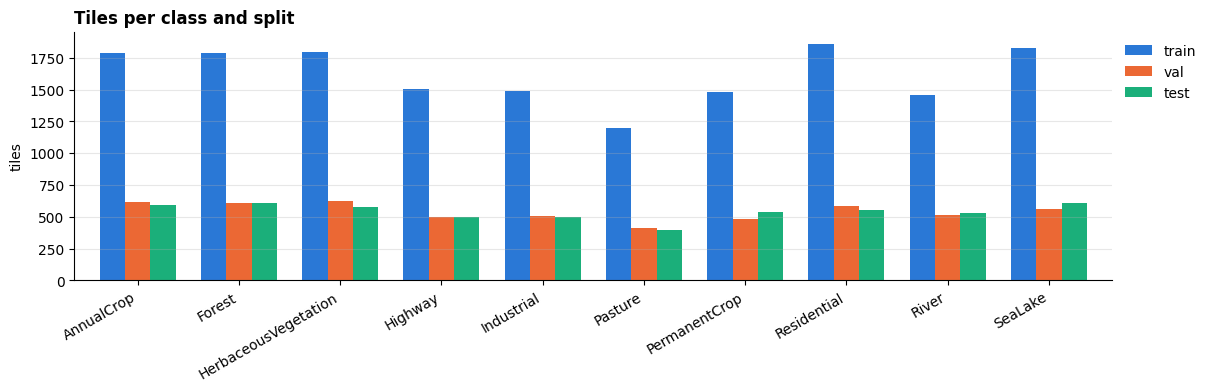

In [ ]:
def class_counts(data: EuroSATData) -> pd.DataFrame:
    """
    Count the number of tiles per class for each dataset split.

    Args:
        data: The EuroSATData object containing train, val, and test splits.

    Returns:
        A pandas DataFrame where rows are classes and columns are splits (train, val, test).
    """
    counts_dict = {
        split.name: np.bincount(split.tiles.targets, minlength=len(data.classes))
        for split in (data.train, data.val, data.test)
    }
    return pd.DataFrame(counts_dict, index=data.classes)


def plot_class_counts(counts: pd.DataFrame) -> plt.Figure:
    """
    Create a bar chart showing the number of tiles per class and split.

    Args:
        counts: A DataFrame containing the class counts per split.

    Returns:
        A matplotlib Figure object displaying the bar chart.
    """
    fig, ax = plt.subplots(figsize=(12, 3.8), layout="constrained")

    # Use predefined split colors
    colors = [SPLIT_COLORS[split] for split in counts.columns]
    counts.plot.bar(ax=ax, color=colors, width=0.75)

    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_ylabel("tiles")
    ax.set_title("Tiles per class and split", loc="left", fontweight="semibold")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))

    return fig


counts = class_counts(data)
plot_class_counts(counts)
counts


**Takeaway:** all ten classes appear in every split with about the same share, and the imbalance
is mild: from ~7% of the tiles (Pasture, the smallest class) to ~11% (the largest), i.e. 1,195 to
1,863 training tiles per class. No re-weighting is needed. Macro F1, which gives every class the
same weight, is reported next to accuracy so that a weak small class would not go unnoticed.

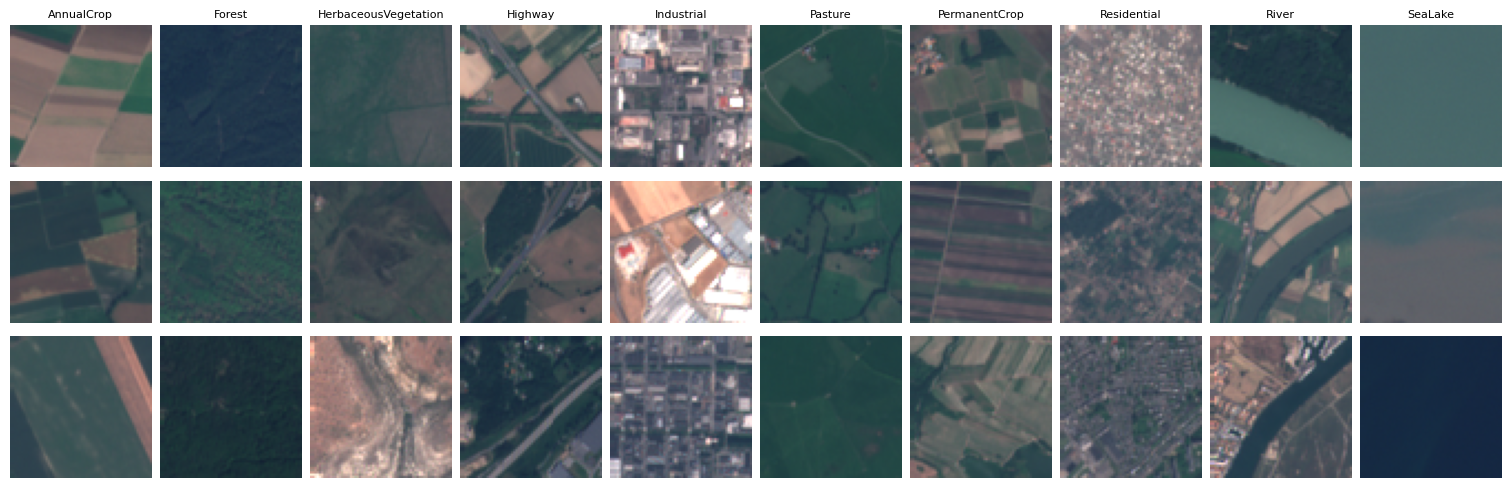

In [ ]:
def to_rgb(image: torch.Tensor) -> np.ndarray:
    """
    Convert a 13-band raw reflectance tile to a 3-band RGB image for display.

    Args:
        image: A tensor of shape (13, 64, 64) containing raw reflectance values.

    Returns:
        A numpy array of shape (64, 64, 3) with values clipped to the [0, 1] range.
    """
    # Extract the indices of the RGB bands
    rgb_indices = [ALL_BANDS.index(b) for b in RGB_BANDS]

    # Select the RGB bands, permute dimensions to (H, W, C), and convert to numpy
    rgb = image[rgb_indices].permute(1, 2, 0).numpy()

    # Normalize reflectance values (typically ~0-3000) to [0, 1] range
    return np.clip(rgb / 3000.0, 0, 1)


def show_tiles(data: EuroSATData, n_per_class: int = 3) -> plt.Figure:
    """
    Display a grid of random training tiles per class in RGB format.

    Args:
        data: The EuroSATData object containing dataset splits and class names.
        n_per_class: The number of random tiles to display for each class.

    Returns:
        A matplotlib Figure object displaying the image grid.
    """
    tiles = data.train.tiles
    targets = np.array(tiles.targets)
    rng = np.random.default_rng(0)

    # Initialize the subplot grid
    fig, axes = plt.subplots(
        n_per_class,
        len(data.classes),
        figsize=(1.5 * len(data.classes), 1.6 * n_per_class),
        layout="constrained"
    )

    for col, class_name in enumerate(data.classes):
        # Pick random tile indices for the current class
        class_indices = np.flatnonzero(targets == col)
        picks = rng.choice(class_indices, size=n_per_class, replace=False)

        for row, idx in enumerate(picks):
            img_rgb = to_rgb(tiles[idx]["image"])
            axes[row, col].imshow(img_rgb)
            axes[row, col].axis("off")

        # Set the column title to the class name
        axes[0, col].set_title(class_name, fontsize=8)

    return fig


show_tiles(data);


**Takeaway:** some classes are easy to tell apart by eye (SeaLake, Forest, Residential); others look
alike. The farmland classes (AnnualCrop, PermanentCrop, HerbaceousVegetation) and Pasture are all
"green fields", and a Highway tile and a River tile are both a line across the tile. These
look-alike groups are where the trained models make most of their mistakes (section 11).

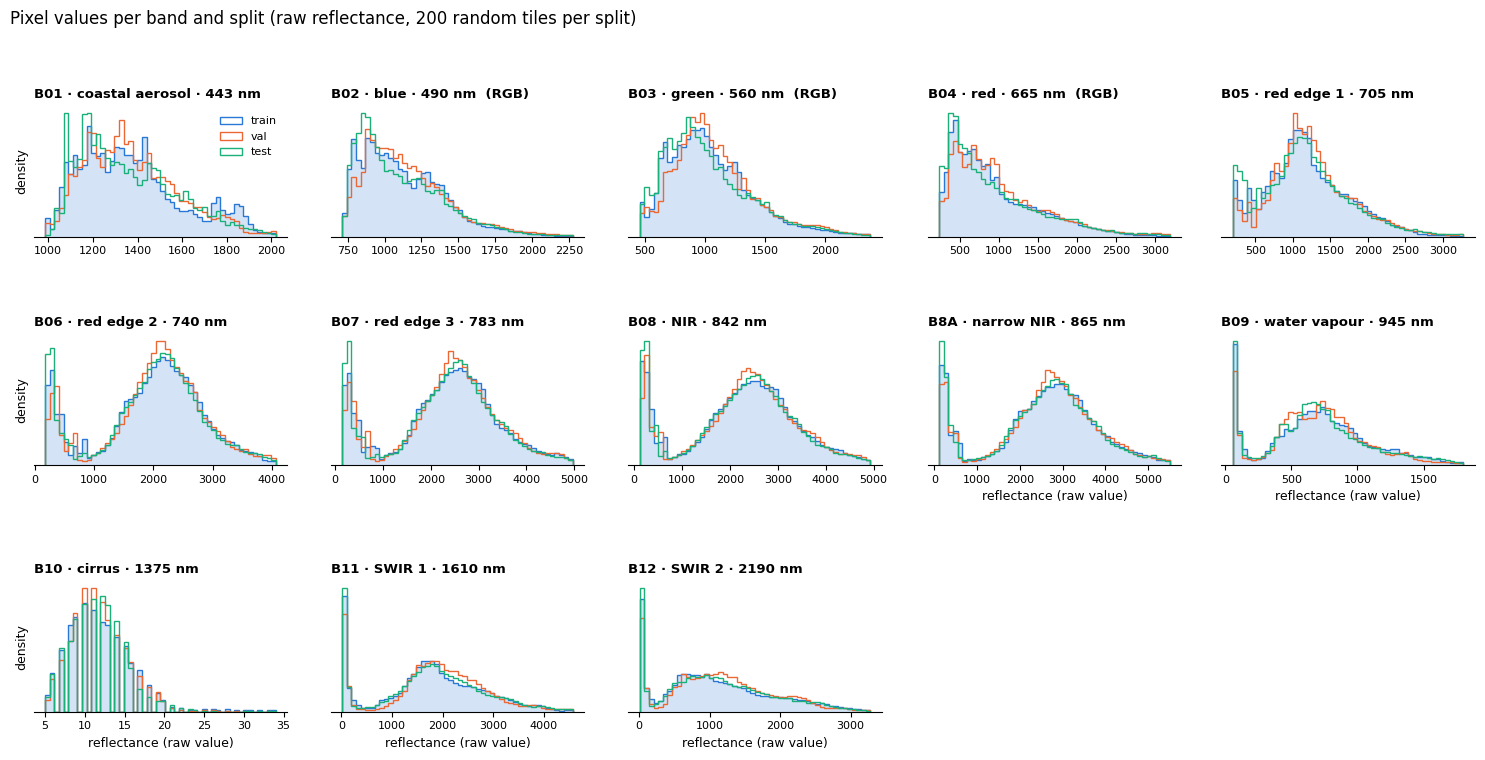

In [ ]:
def sample_pixels(split: Split, n_tiles: int = 200) -> np.ndarray:
    """
    Extract every pixel from a random sample of the split's tiles.

    Args:
        split: The dataset split (e.g., train, val, test) containing tiles.
        n_tiles: The maximum number of random tiles to sample.

    Returns:
        A numpy array of shape (N_pixels, 13) containing raw reflectance values.
    """
    n_available = len(split.tiles)
    n_samples = min(n_tiles, n_available)

    # Pick random tile indices without replacement
    rng = np.random.default_rng(0)
    picks = rng.choice(n_available, size=n_samples, replace=False).tolist()

    # Load the selected tiles using a DataLoader for efficiency
    subset = Subset(split.tiles, picks)
    loader = DataLoader(subset, batch_size=256, num_workers=NUM_WORKERS)

    # Gather all images from the batches
    images = [batch["image"] for batch in loader]

    # Concatenate, permute dimensions to (N, H, W, C), and flatten to (N_pixels, C)
    all_pixels = torch.cat(images).permute(0, 2, 3, 1).reshape(-1, len(ALL_BANDS)).numpy()
    return all_pixels


def band_title(band: str) -> str:
    """
    Generate a descriptive title for a given spectral band.

    Args:
        band: The name of the band (e.g., 'B04').

    Returns:
        A formatted string containing the band name, label, and wavelength.
    """
    label = BAND_LABELS[band]
    wavelength = WAVELENGTH_NM[band]
    rgb_suffix = "  (RGB)" if band in RGB_BANDS else ""
    return f"{band} · {label} · {wavelength} nm{rgb_suffix}"


def plot_band_histograms(pixels: dict[str, np.ndarray]) -> plt.Figure:
    """
    Plot the distribution of raw reflectance for every band, ordered by wavelength.

    Args:
        pixels: A dictionary mapping split names (e.g., 'train') to their pixel arrays.

    Returns:
        A matplotlib Figure object displaying the histograms.
    """
    # Initialize a 3x5 grid of subplots
    fig, axes = plt.subplots(3, 5, figsize=(15, 8), layout="constrained")
    fig.get_layout_engine().set(w_pad=0.2, h_pad=0.3, wspace=0.05, hspace=0.12)

    for ax, band in zip(axes.flat, BANDS_BY_WAVELENGTH):
        b_idx = ALL_BANDS.index(band)

        # Determine x-axis range based on the 0.5th and 99.5th percentiles of training data
        train_pixels = pixels["train"][:, b_idx]
        low, high = np.percentile(train_pixels, [0.5, 99.5])

        # Plot histograms for each split
        for split_name, split_values in pixels.items():
            band_values = split_values[:, b_idx]
            color = SPLIT_COLORS[split_name]

            # Add a filled histogram for the training split
            if split_name == "train":
                ax.hist(band_values, bins=50, range=(low, high), density=True,
                        histtype="stepfilled", color=color, alpha=0.2, lw=0)

            # Add an outlined histogram for all splits
            ax.hist(band_values, bins=50, range=(low, high), density=True,
                    histtype="step", lw=1.4, color=color, label=split_name)

        ax.set_title(band_title(band), loc="left", fontsize=9.5, fontweight="semibold")
        ax.set_yticks([])
        ax.tick_params(labelsize=8)
        ax.spines[["top", "right", "left"]].set_visible(False)

    # Hide any unused subplots (since there are 13 bands and 15 subplots)
    for ax in axes.flat[len(ALL_BANDS):]:
        ax.axis("off")

    # Add x-axis labels to the lowest panel of each column
    for col in range(axes.shape[1]):
        # The last two columns have empty panels in the bottom row
        lowest = axes[-1, col] if col < len(ALL_BANDS) - 2 * axes.shape[1] else axes[-2, col]
        lowest.set_xlabel("reflectance (raw value)", fontsize=9)

    # Add y-axis labels to the first column
    for ax in axes[:, 0]:
        ax.set_ylabel("density", fontsize=9)

    # Add a legend to the first panel
    axes.flat[0].legend(frameon=False, fontsize=8, loc="upper right")

    fig.suptitle("Pixel values per band and split (raw reflectance, 200 random tiles per split)", x=0.01, ha="left")
    return fig


pixels = {split.name: sample_pixels(split) for split in (data.train, data.val, data.test)}
plot_band_histograms(pixels);


**Takeaway:** in every band the train, validation and test curves lie on top of each other, so the
splits are alike and a test score is a fair score. Also visible: value ranges differ by up to ~100×
between bands, and the infrared bands are two-humped, with water pixels near 0 and land pixels
around 2,000–3,000 (water absorbs infrared light, vegetation reflects it strongly).

spectra: 100%|██████████| 12/12 [00:01<00:00,  6.34it/s]


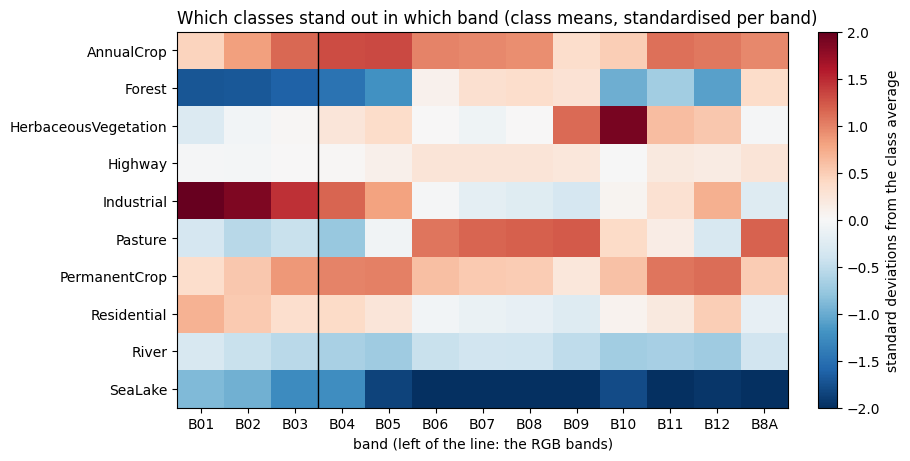

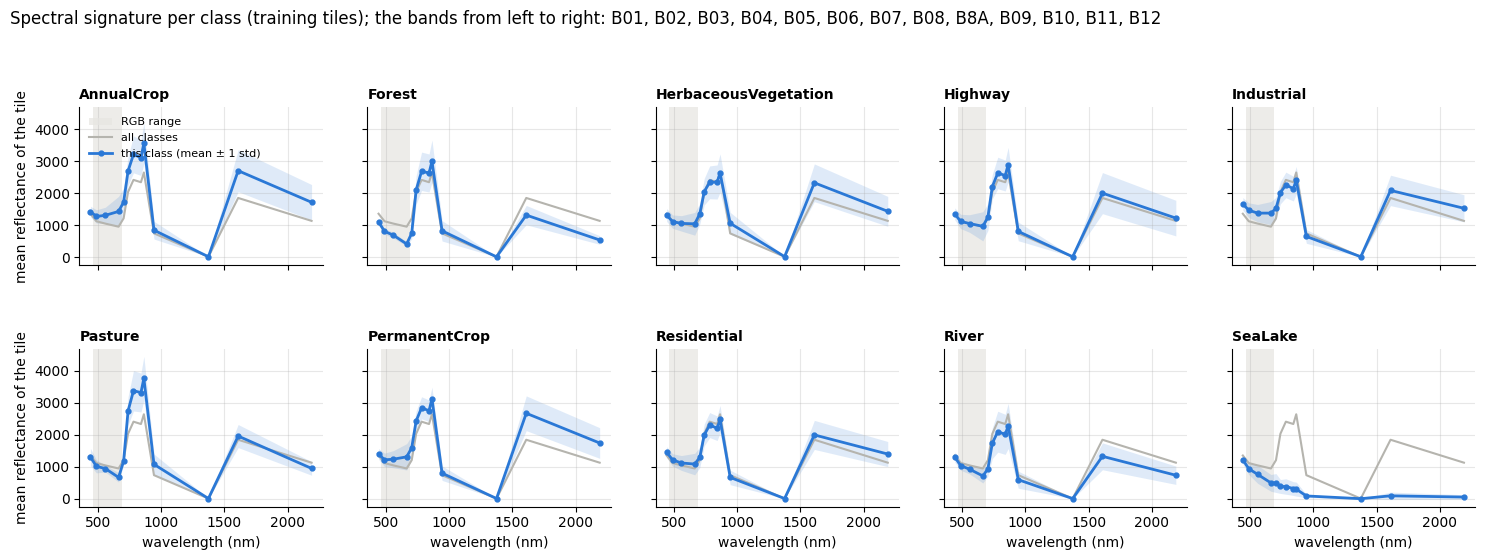

In [ ]:
def class_spectra(data: EuroSATData, n_tiles: int = 3000) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Calculate the mean and standard deviation of reflectance per band for each class.

    Args:
        data: The EuroSAT dataset containing training tiles and classes.
        n_tiles: The number of random tiles to sample.

    Returns:
        A tuple of two DataFrames: the mean and standard deviation of reflectance per class.
    """
    tiles = data.train.tiles
    sample = np.random.default_rng(0).choice(len(tiles), min(n_tiles, len(tiles)), replace=False).tolist()
    sums = np.zeros((len(data.classes), len(ALL_BANDS)))
    sums_sq = np.zeros_like(sums)
    counts = np.zeros(len(data.classes))
    for batch in tqdm(DataLoader(Subset(tiles, sample), batch_size=256, num_workers=NUM_WORKERS), desc="spectra"):
        labels = batch["label"].numpy()
        means = batch["image"].mean(dim=(2, 3)).numpy()   # (tiles, 13): mean reflectance of each band per tile
        np.add.at(sums, labels, means)
        np.add.at(sums_sq, labels, means ** 2)
        np.add.at(counts, labels, 1)
    mean = sums / counts[:, None]
    std = np.sqrt(np.maximum(sums_sq / counts[:, None] - mean ** 2, 0))
    return (
        pd.DataFrame(mean, index=data.classes, columns=ALL_BANDS),
        pd.DataFrame(std, index=data.classes, columns=ALL_BANDS)
    )


def plot_spectra(spectra: pd.DataFrame) -> plt.Figure:
    """
    Plot the standardised class means for each band as a heatmap.

    Args:
        spectra: A DataFrame containing the mean reflectance per class and band.

    Returns:
        A matplotlib Figure showing the heatmap.
    """
    z = (spectra - spectra.mean()) / spectra.std()
    fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
    image = ax.imshow(z.values, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
    ax.set_xticks(range(len(z.columns)), z.columns)
    ax.set_yticks(range(len(z.index)), z.index)
    rgb_columns = sorted(ALL_BANDS.index(b) for b in RGB_BANDS)   # B02, B03, B04 in model order
    for x in (rgb_columns[0] - 0.5, rgb_columns[-1] + 0.5):       # bracket the RGB columns
        ax.axvline(x, color="black", lw=1)
    ax.text(np.mean(rgb_columns), -0.7, "RGB", ha="center", va="bottom", fontsize=9)
    ax.set_xlabel("band (between the lines: the RGB bands B02, B03, B04)")
    ax.set_title("Which classes stand out in which band (class means, standardised per band)", loc="left")
    fig.colorbar(image, ax=ax, label="standard deviations from the class average")
    return fig


def plot_spectral_signatures(mean: pd.DataFrame, std: pd.DataFrame) -> plt.Figure:
    """
    Plot the spectral signature (mean reflectance +/- 1 std) for each class across wavelengths.

    Args:
        mean: A DataFrame containing the mean reflectance per class and band.
        std: A DataFrame containing the standard deviation of reflectance per class and band.

    Returns:
        A matplotlib Figure showing the spectral signatures.
    """
    bands = list(BANDS_BY_WAVELENGTH)
    wavelength = np.array([WAVELENGTH_NM[b] for b in bands])
    overall = mean[bands].mean(axis=0).values
    fig, axes = plt.subplots(2, 5, figsize=(15, 6), layout="constrained", sharex=True, sharey=True)
    fig.get_layout_engine().set(w_pad=0.2, h_pad=0.3, wspace=0.04, hspace=0.1)   # space between panels
    for ax, name in zip(axes.flat, mean.index):
        mu, sd = mean.loc[name, bands].values, std.loc[name, bands].values
        ax.axvspan(WAVELENGTH_NM["B02"] - 25, WAVELENGTH_NM["B04"] + 25, color=GRID, alpha=0.7, lw=0, label="RGB range")
        ax.plot(wavelength, overall, color="#b5b4ae", lw=1.5, label="all classes")
        ax.fill_between(wavelength, mu - sd, mu + sd, color=TRAIN_COLOR, alpha=0.15, lw=0)
        ax.plot(wavelength, mu, color=TRAIN_COLOR, lw=2, marker="o", ms=3.5, label="this class (mean ± 1 std)")
        ax.set_title(name, loc="left", fontsize=10, fontweight="semibold")
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
    for ax in axes[-1]:
        ax.set_xlabel("wavelength (nm)")
    for ax in axes[:, 0]:
        ax.set_ylabel("mean reflectance of the tile")
    axes.flat[0].legend(frameon=False, fontsize=8, loc="upper left")
    fig.suptitle("Spectral signature per class (training tiles); the bands from left to right: "
                 + ", ".join(bands), x=0.01, ha="left")
    return fig


spectra_mean, spectra_std = class_spectra(data)
plot_spectra(spectra_mean)
plot_spectral_signatures(spectra_mean, spectra_std);


**Takeaway:** the extra bands *do* carry class information that RGB misses, which is the reason to
ask whether a model can make use of it.

* **Heat map:** how bright each class is in each band compared with the average class (red =
  brighter, blue = darker, in standard deviations). The RGB bands are **B02, B03 and B04**; the
  other ten are what an RGB model never sees. Some classes already stand out within RGB (Forest
  dark, Industrial bright), others mainly outside it: Pasture is slightly darker than average in
  RGB yet clearly brighter in the red-edge and near-infrared bands (B06–B08, B8A); SeaLake is about
  two standard deviations darker in every infrared band; HerbaceousVegetation stands out most in
  B09 and B10.
* **Caution:** B09 (water vapour) and B10 (cirrus) mainly measure the *atmosphere*. B10 is close to
  zero everywhere, so standardising magnifies tiny differences; a class standing out there may
  partly reflect the weather on the days its tiles were taken, not the land.
* **Spectral signatures:** the same information as curves of mean reflectance against wavelength
  (RGB range shaded). The vegetation classes all show the typical jump from red to near-infrared
  and differ mainly in *how high* the peak is; SeaLake stays near zero beyond the visible range.

*Note on the saved heat map:* its black line is drawn after B03 and labels B01–B03 as RGB, which is
off by one column (B01 is not an RGB band, B04 is). The code now brackets B02–B04; re-running the
cell redraws it correctly.

## 5. Preprocessing

Each run selects its bands (3 or 13) and standardises every band to mean 0 and standard deviation
1, using its own split's statistics from section 4. Runs with augmentation also get random flips,
90° rotations and a mild random crop of the training tiles. These only move pixels around, so the
label stays true and the operation is exactly the same for 3-band and 13-band tiles.

*Technical note:* the data loaders keep their worker processes alive for the whole run
(`persistent_workers=True`). This avoids a harmless but noisy
`AssertionError: can only test a child process` on Colab
([pytorch#149837](https://github.com/pytorch/pytorch/issues/149837),
[pytorch#53703](https://github.com/pytorch/pytorch/issues/53703)).

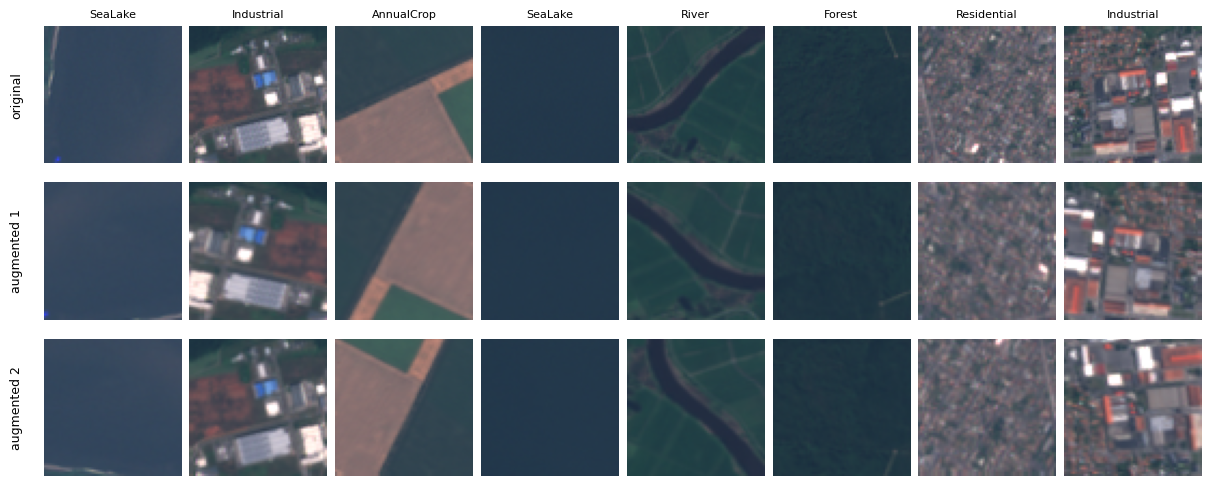

In [ ]:
class RandomRotate90(nn.Module):
    """
    A PyTorch module that randomly rotates an image tensor by a multiple of 90 degrees.
    """
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Apply a random 90-degree rotation to the input tensor.

        Args:
            x: The input image tensor of shape (..., H, W).

        Returns:
            The randomly rotated image tensor.
        """
        return torch.rot90(x, k=random.randrange(4), dims=(-2, -1))


AUGMENT = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    RandomRotate90(),
    T.RandomResizedCrop(TILE_SIZE, scale=(0.8, 1.0), antialias=True),
])


class BandDataset(Dataset):
    """
    A PyTorch Dataset for EuroSAT tiles with specific spectral bands.

    Yields (image, label) pairs where the image contains only the arm's selected bands,
    standardised using the specific split's own statistics.
    """

    def __init__(self, split: Split, bands: tuple[str, ...], augment: bool) -> None:
        """
        Initialize the dataset.

        Args:
            split: The dataset split (train, val, or test) containing tiles and stats.
            bands: A tuple of band names to extract from the raw tiles.
            augment: Whether to apply geometric data augmentations.
        """
        self.tiles = split.tiles
        self.band_idx = [ALL_BANDS.index(b) for b in bands]
        self.mean = split.band_mean[self.band_idx].view(-1, 1, 1)
        self.std = split.band_std[self.band_idx].view(-1, 1, 1)
        self.augment = augment

    def __len__(self) -> int:
        return len(self.tiles)

    def __getitem__(self, i: int) -> tuple[torch.Tensor, torch.Tensor]:
        sample = self.tiles[i]
        x = (sample["image"][self.band_idx] - self.mean) / self.std   # what StandardScaler.transform does
        if self.augment:
            x = AUGMENT(x)
        return x, sample["label"]


def make_datasets(arm: Arm, data: EuroSATData) -> tuple[Dataset, Dataset, Dataset]:
    """
    Create training, validation, and testing datasets for a specific experimental arm.

    Args:
        arm: The experimental arm specifying the selected bands and augmentation settings.
        data: The EuroSATData object containing all dataset splits.

    Returns:
        A tuple containing the initialized train, val, and test Datasets.
    """
    return (
        BandDataset(data.train, arm.bands, augment=arm.augment),
        BandDataset(data.val, arm.bands, augment=False),
        BandDataset(data.test, arm.bands, augment=False)
    )


def show_augmentations(data: EuroSATData, n_tiles: int = 8, n_augmented: int = 2) -> plt.Figure:
    """
    Display a grid of random training tiles in RGB format with augmented versions.

    Args:
        data: The EuroSATData object containing the training split.
        n_tiles: The number of original random tiles to display.
        n_augmented: The number of augmented variations to show per tile.

    Returns:
        A matplotlib Figure showing the original and augmented tiles.
    """
    picks = np.random.default_rng(1).choice(len(data.train.tiles), n_tiles, replace=False)
    fig, axes = plt.subplots(
        1 + n_augmented, n_tiles,
        figsize=(1.5 * n_tiles, 1.6 * (1 + n_augmented)),
        layout="constrained"
    )
    for col, i in enumerate(picks):
        image = data.train.tiles[i]["image"]
        views = [image] + [AUGMENT(image) for _ in range(n_augmented)]
        for row, view in enumerate(views):
            axes[row, col].imshow(to_rgb(view))
            axes[row, col].axis("off")
        axes[0, col].set_title(data.classes[data.train.tiles.targets[i]], fontsize=8)
    for row in range(1 + n_augmented):
        axes[row, 0].text(-0.15, 0.5, "original" if row == 0 else f"augmented {row}",
                          transform=axes[row, 0].transAxes,
                          rotation=90, va="center", ha="right", fontsize=9)
    return fig


show_augmentations(data);


**Takeaway:** the augmented copies (rows 2 and 3) are still clearly the same land cover as the
originals (top row), so their labels stay true. Whether augmentation actually helps is tested, not
assumed (section 10.3).

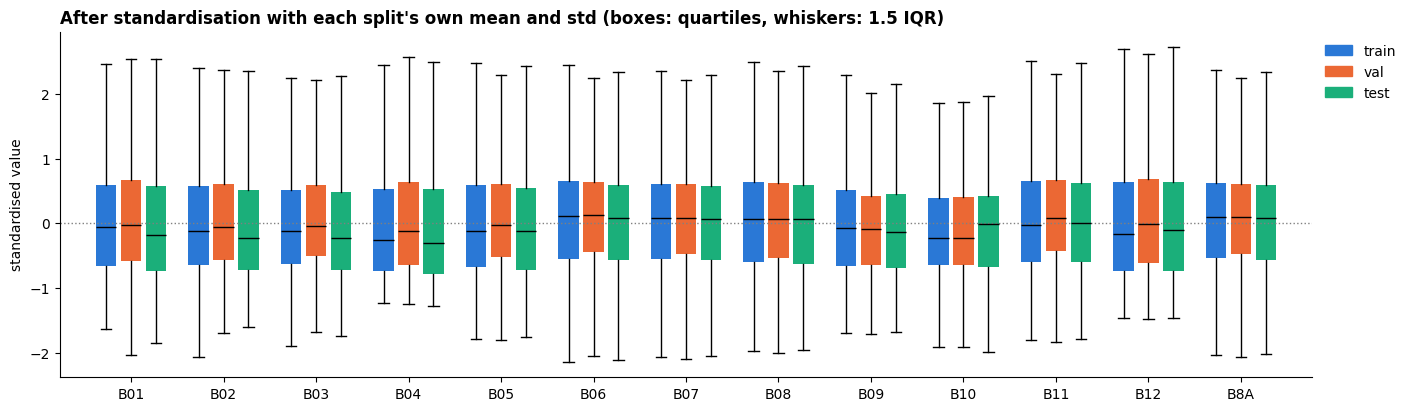

In [ ]:
def plot_standardised_bands(data: EuroSATData, pixels: dict[str, np.ndarray]) -> plt.Figure:
    """
    Plot the distribution of sampled pixels after standardisation using each split's own statistics.

    Displays one box plot per spectral band and dataset split.

    Args:
        data: The EuroSATData object containing train, val, and test splits.
        pixels: A dictionary mapping split names to their corresponding numpy arrays of raw pixels.

    Returns:
        A matplotlib Figure showing the standardised pixel distributions.
    """
    splits = (data.train, data.val, data.test)
    fig, ax = plt.subplots(figsize=(14, 4), layout="constrained")

    for k, split in enumerate(splits):
        # Standardise the raw pixels using the split's own mean and standard deviation
        z = (pixels[split.name] - split.band_mean.numpy()) / split.band_std.numpy()

        # Plot boxplots, shifted slightly for each split to avoid overlap
        positions = np.arange(len(ALL_BANDS)) + (k - 1) * 0.27
        ax.boxplot(
            z,
            positions=positions,
            widths=0.22,
            showfliers=False,
            patch_artist=True,
            boxprops={"facecolor": SPLIT_COLORS[split.name], "edgecolor": "none"},
            medianprops={"color": "black"}
        )

    ax.set_xticks(range(len(ALL_BANDS)), ALL_BANDS)
    ax.axhline(0, color="gray", lw=1, ls=":")
    ax.set_ylabel("standardised value")
    ax.set_title(
        "After standardisation with each split's own mean and std (boxes: quartiles, whiskers: 1.5 IQR)",
        loc="left",
        fontweight="semibold"
    )

    # Create custom legend handles
    legend_handles = [plt.Rectangle((0, 0), 1, 1, color=SPLIT_COLORS[s.name]) for s in splits]
    legend_labels = [s.name for s in splits]
    ax.legend(legend_handles, legend_labels, frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))

    ax.spines[["top", "right"]].set_visible(False)

    return fig


plot_standardised_bands(data, pixels);

**Takeaway:** after standardisation every band is centred near 0 with a similar spread, and the
three splits still match. This is what the model receives: no band dominates just because of its
units.

## 6. Model

One architecture for every run: the 64 × 64 tile is upsampled to 224 × 224 (the size the backbone
was pretrained on) and passed through a **ViT-S/16**, a small vision transformer (~22 M parameters)
pretrained on ImageNet photos; a new linear layer turns its features into scores for the 10
classes.

The only difference for 13-band input is the first layer. The pretrained one expects 3 colour
channels, so timm widens it to 13 by repeating the pretrained RGB filters across the channels
(scaled down). The extra bands therefore start from borrowed RGB filters, not filters learned for
them. Everything else is identical between the RGB and 13-band runs.

`ProbeThenFineTune` handles the two training phases: for the first `probe_epochs` epochs the
backbone is frozen and only the new head learns (a quick "probe" of how useful the pretrained
features already are); after that the whole network is fine-tuned.

In [ ]:
class Classifier(nn.Module):
    """
    A PyTorch image classifier built on a timm backbone.

    The network upsamples input tiles to a fixed INPUT_SIZE, passes them
    through a pretrained backbone, and classifies the pooled features with
    a linear head. Supports freezing the backbone for transfer learning.
    """

    def __init__(self, backbone_name: str, in_chans: int, num_classes: int, pretrained: bool = True) -> None:
        """
        Initialize the Classifier.

        Args:
            backbone_name: The name of the timm backbone model.
            in_chans: The number of input channels (e.g., 3 for RGB, 13 for all bands).
            num_classes: The number of output classes.
            pretrained: Whether to load pretrained weights for the backbone.
        """
        super().__init__()
        self.backbone_frozen = False
        self.resize = nn.Upsample(size=INPUT_SIZE, mode="bilinear", align_corners=False)
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0, in_chans=in_chans)
        self.head = nn.Linear(self.backbone.num_features, num_classes)

    def train(self, mode: bool = True) -> "Classifier":
        """
        Set the model to training or evaluation mode.
        Ensures the backbone remains in eval mode if it is frozen.

        Args:
            mode: True for training mode, False for evaluation mode.

        Returns:
            The model instance itself.
        """
        super().train(mode)
        if self.backbone_frozen:
            self.backbone.eval()   # frozen backbone: BatchNorm statistics stay fixed too
        return self

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Perform a forward pass through the upsampler, backbone, and head.

        Args:
            x: Input tensor of shape (B, C, H, W).

        Returns:
            Logits tensor of shape (B, num_classes).
        """
        return self.head(self.backbone(self.resize(x)))


def build_model(arm: Arm, num_classes: int) -> Classifier:
    """
    Construct a Classifier model for a specific experimental arm.

    Args:
        arm: The experimental arm defining the backbone and input bands.
        num_classes: The number of output classes.

    Returns:
        An instantiated Classifier model.
    """
    return Classifier(arm.backbone, in_chans=len(arm.bands), num_classes=num_classes)


def set_backbone_frozen(model: Classifier, frozen: bool) -> None:
    """
    Freeze or unfreeze the backbone of the classifier.

    When frozen, the backbone's parameters do not receive gradients, and
    the backbone is kept in evaluation mode to fix BatchNorm statistics.

    Args:
        model: The classifier model to modify.
        frozen: True to freeze the backbone, False to unfreeze it.
    """
    model.backbone_frozen = frozen
    model.backbone.requires_grad_(not frozen)
    model.train(model.training)   # re-apply the mode rule above


def count_parameters(model: nn.Module) -> int:
    """
    Count the total number of parameters in a PyTorch module.

    Args:
        model: The PyTorch module.

    Returns:
        The total number of elements in the module's parameters.
    """
    return sum(p.numel() for p in model.parameters())


class ProbeThenFineTune(Callback):
    """
    Callback to manage transfer learning phases.

    Freezes the backbone for the first `probe_epochs` (only the head learns),
    then unfreezes the whole network for fine-tuning.
    """

    def __init__(self, probe_epochs: int) -> None:
        """
        Initialize the callback.

        Args:
            probe_epochs: Number of initial epochs to keep the backbone frozen.
        """
        self.probe_epochs = probe_epochs

    def on_train_begin(self, state: "TrainerState") -> None:
        """
        Freeze the backbone at the start of training if probe epochs > 0.
        """
        set_backbone_frozen(state.model, self.probe_epochs > 0)

    def on_epoch_begin(self, state: "TrainerState") -> None:
        """
        Unfreeze the backbone when the probe epochs have finished.
        """
        if state.epoch == self.probe_epochs + 1:
            set_backbone_frozen(state.model, False)
            tqdm.write(f"Epoch {state.epoch}: backbone unfrozen, fine-tuning the whole network.")


## 7. Running an arm

`run_arm` is one complete run: build the datasets and the model, train (probe, then fine-tune, with
the live plot), keep the weights with the lowest validation loss, and score them **once** on the
test split (accuracy, macro F1, and each tile's predicted class and probabilities). The same
weights also predict the validation split, which is what Experiment 2's augmentation decision uses,
so the test split plays no part in any choice.

Results are saved under `results/<arm>/`. Re-running the notebook reloads a saved run instead of
retraining it, after checking that it was trained as the same arm with the same recipe. (Runs saved
by an older version of the notebook lack probabilities and validation predictions; delete the
folder to retrain.)

In [ ]:
@dataclass(frozen=True)
class RunResult:
    """
    Results and artifacts from a single training run (arm).
    """
    arm: Arm
    config: dict[str, Any]     # config_to_dict of the TrainingConfig used
    history: TrainingHistory
    test_accuracy: float
    test_macro_f1: float
    y_true: np.ndarray         # test labels and predictions, for confusion matrices and paired tests
    y_pred: np.ndarray
    n_parameters: int
    train_minutes: float
    y_prob: np.ndarray | None = None   # (tiles, classes) softmax probabilities on the test split;
                                       # None for a result saved before this field existed
    val_y_true: np.ndarray | None = None   # validation labels and predictions of the same weights: the split
    val_y_pred: np.ndarray | None = None   # Experiment 2's augmentation decision is made on (None if saved before)


def run_arm(arm: Arm, data: EuroSATData, config: TrainingConfig) -> RunResult:
    """
    Execute the training and evaluation pipeline for a specific experimental arm.

    Args:
        arm: The experimental arm definition.
        data: The EuroSAT dataset splits.
        config: The training configuration to use.

    Returns:
        A RunResult object containing the metrics and artifacts of the run.
    """
    print(f"=== {arm.name}: {arm.description} | {len(arm.bands)} bands | augment={arm.augment}")
    train_ds, val_ds, test_ds = make_datasets(arm, data)
    seed_everything(config.seed)   # same head initialisation for every arm
    model = build_model(arm, len(data.classes))
    callbacks = [ProbeThenFineTune(config.probe_epochs), LivePlot(min_interval_s=1.0)]

    start = time.perf_counter()
    model, history = train(model, train_ds, config, val_dataset=val_ds, callbacks=callbacks)
    train_minutes = (time.perf_counter() - start) / 60

    device = resolve_device(config)
    val_y_true, val_y_pred, _ = predict(model, build_loader(config, val_ds, train=False), device)
    y_true, y_pred, y_prob = predict(model, build_loader(config, test_ds, train=False), device)
    result = RunResult(arm, config_to_dict(config), history,
                       test_accuracy=accuracy_score(y_true, y_pred),
                       test_macro_f1=f1_score(y_true, y_pred, average="macro"),
                       y_true=y_true, y_pred=y_pred,
                       n_parameters=count_parameters(model), train_minutes=train_minutes, y_prob=y_prob,
                       val_y_true=val_y_true, val_y_pred=val_y_pred)
    save_result(result)
    best = min(history.validations, key=lambda v: v.loss)
    print(f"best validation at epoch {best.epoch} (val loss {best.loss:.4f}, acc {best.accuracy:.2%}) -> "
          f"test acc {result.test_accuracy:.2%}, macro F1 {result.test_macro_f1:.4f} | {train_minutes:.1f} min\n")
    return result


def save_result(result: RunResult) -> None:
    """
    Save the run result objects and arrays to the disk.

    Args:
        result: The RunResult object to save.
    """
    folder = RESULTS_DIR / result.arm.name
    folder.mkdir(parents=True, exist_ok=True)
    (folder / "history.json").write_text(json.dumps(history_to_dict(result.history)))
    arrays = {"y_true": result.y_true, "y_pred": result.y_pred}
    if result.y_prob is not None:
        arrays["y_prob"] = result.y_prob
    if result.val_y_true is not None:
        arrays["val_y_true"], arrays["val_y_pred"] = result.val_y_true, result.val_y_pred
    np.savez(folder / "predictions.npz", **arrays)
    summary = {"arm": asdict(result.arm), "config": result.config, "test_accuracy": result.test_accuracy,
               "test_macro_f1": result.test_macro_f1, "n_parameters": result.n_parameters,
               "train_minutes": result.train_minutes}
    (folder / "summary.json").write_text(json.dumps(summary, indent=2, default=lambda o: o.item()))


def load_result(arm_name: str) -> RunResult:
    """
    Load a saved RunResult from the disk.

    Args:
        arm_name: The name of the arm to load.

    Returns:
        The reconstructed RunResult object.
    """
    folder = RESULTS_DIR / arm_name
    summary = json.loads((folder / "summary.json").read_text())
    summary["arm"]["bands"] = tuple(summary["arm"]["bands"])
    history = history_from_dict(json.loads((folder / "history.json").read_text()))
    history.probe_epochs = summary["config"]["probe_epochs"]   # also for histories saved without it
    predictions = np.load(folder / "predictions.npz")
    return RunResult(Arm(**summary["arm"]), summary["config"], history, summary["test_accuracy"],
                     summary["test_macro_f1"], predictions["y_true"], predictions["y_pred"],
                     summary["n_parameters"], summary["train_minutes"],
                     y_prob=predictions["y_prob"] if "y_prob" in predictions.files else None,
                     val_y_true=predictions["val_y_true"] if "val_y_true" in predictions.files else None,
                     val_y_pred=predictions["val_y_pred"] if "val_y_pred" in predictions.files else None)


def check_saved(result: RunResult, arm: Arm, config: TrainingConfig) -> RunResult:
    """
    Verify that a loaded result matches the expected arm and configuration.

    Args:
        result: The loaded RunResult.
        arm: The expected experimental arm.
        config: The expected training configuration.

    Returns:
        The validated RunResult.

    Raises:
        ValueError: If the loaded result differs from expectations.
    """
    saved, wanted = result.arm, arm
    if (saved.backbone, saved.bands, saved.augment) != (wanted.backbone, wanted.bands, wanted.augment):
        raise ValueError(f"{arm.name}: the saved result was trained as {saved.description!r}; "
                         f"delete {RESULTS_DIR / arm.name} to retrain it as {wanted.description!r}")
    recipe = {name: getattr(config, name) for name in RECIPE_FIELDS}
    saved_recipe = {name: result.config.get(name) for name in RECIPE_FIELDS}
    if saved_recipe != recipe:
        raise ValueError(f"{arm.name}: the saved result used another recipe {saved_recipe}; "
                         f"delete {RESULTS_DIR / arm.name} to retrain it with {recipe}")
    return result


def run_experiment(experiment: Experiment, data: EuroSATData) -> dict[str, RunResult]:
    """
    Run or load results for all arms in an experiment.

    Args:
        experiment: The experiment containing multiple arms.
        data: The dataset used for the experiment.

    Returns:
        A mapping of arm names to their RunResult objects.
    """
    print(f"##### {experiment.name}: {experiment.question}\n")
    results = {}
    for arm in experiment.arms:
        if (RESULTS_DIR / arm.name / "summary.json").exists():
            print(f"{arm.name}: loading the saved result (delete {RESULTS_DIR / arm.name} to retrain)\n")
            results[arm.name] = check_saved(load_result(arm.name), arm, experiment.config)
        else:
            results[arm.name] = run_arm(arm, data, experiment.config)
    return results


### 7.2 Tuning the recipe with Optuna (Experiment 2)

An Optuna **trial** is one RGB training run (no augmentation) with a recipe proposed by the sampler,
scored by its lowest validation loss. The sampler (TPE) learns from earlier trials which regions of
the search space look promising.

* **Pruning:** after every epoch the trial reports its validation loss. From epoch 6 on, and once 5
  trials have finished, a trial doing worse than the median of earlier trials at the same epoch is
  stopped. This saves time on recipes that are clearly not going to win.
* **Trial 0 = the baseline:** the baseline run (section 10.1) is entered as trial 0, so the search
  starts from the recipe we already have and can only match or beat it.
* A run whose loss becomes NaN (training blew up) is recorded as failed and ignored.
* The study is stored in `results/optuna_e2.db`: an interrupted Colab session resumes where it
  stopped, and a finished study is simply reloaded.

In [ ]:
class OptunaPruning(Callback):
    """
    Reports every validation loss to the trial; when Optuna's pruner gives up on the trial, the run stops.
    """

    def __init__(self, trial: optuna.Trial) -> None:
        """
        Initialize the Optuna pruning callback.

        Args:
            trial: The current Optuna trial being evaluated.
        """
        self.trial = trial
        self.pruned = False

    def on_validation_end(self, state: TrainerState, validation: ValidationMetrics) -> None:
        """
        Report validation loss and check if the trial should be pruned.

        Args:
            state: The current trainer state.
            validation: The validation metrics from the current epoch.
        """
        self.trial.report(validation.loss, step=validation.epoch)
        if self.trial.should_prune():
            self.pruned = True
            state.stop_training = True   # the training loop stops after this step (StopReason.CALLBACK)
            tqdm.write(f"Trial {self.trial.number} pruned at epoch {validation.epoch} (val loss {validation.loss:.4f}).")


TUNING_ARM = EXPERIMENT_2_BASELINE.arms[0]   # every trial trains what the baseline trains: RGB, no augmentation


def objective(trial: optuna.Trial) -> float:
    """
    Execute a single optimization trial to evaluate a suggested training recipe.

    The tuning arm is trained with the suggested recipe, and the trial's score
    is evaluated based on its lowest validation loss.

    Args:
        trial: The Optuna trial containing the suggested hyperparameters.

    Returns:
        The lowest validation loss achieved during training.

    Raises:
        optuna.TrialPruned: If the trial was pruned early by Optuna.
    """
    config = replace(BASELINE_CONFIG, **suggest_recipe(trial))
    print(f"--- trial {trial.number}: {recipe_from_params(trial.params)}")
    train_ds, val_ds, _ = make_datasets(TUNING_ARM, data)
    seed_everything(config.seed)   # the same head initialisation as every arm
    model = build_model(TUNING_ARM, len(data.classes))
    pruning = OptunaPruning(trial)
    try:
        _, history = train(model, train_ds, config, val_dataset=val_ds,
                           callbacks=[ProbeThenFineTune(config.probe_epochs), pruning])
    finally:
        del model
        torch.cuda.empty_cache()
    if pruning.pruned:
        raise optuna.TrialPruned()
    return min(v.loss for v in history.validations)


def baseline_trial(result: RunResult) -> optuna.trial.FrozenTrial:
    """
    Create an Optuna trial representing the baseline arm.

    This serves as trial 0 of the study, providing the reference recipe,
    lowest validation loss, and validation loss per epoch for the pruner.

    Args:
        result: The RunResult of the baseline arm.

    Returns:
        A FrozenTrial populated with the baseline's parameters and metrics.
    """
    params = recipe_params(BASELINE_CONFIG)
    return optuna.trial.create_trial(
        params=params, distributions={name: SEARCH_SPACE[name] for name in params},
        value=min(v.loss for v in result.history.validations),
        intermediate_values={v.epoch: v.loss for v in result.history.validations},
        user_attrs={"minutes": result.train_minutes})


def run_search(baseline: RunResult, n_trials: int = N_TRIALS) -> optuna.Study:
    """
    Execute the hyperparameter search for Experiment 2.

    Initializes the study with the baseline as trial 0, then runs the remaining
    trials to reach the target `n_trials`. Resumes from disk if interrupted.

    Args:
        baseline: The RunResult of the baseline arm to use as trial 0.
        n_trials: The total number of trials to run in the study.

    Returns:
        The completed Optuna study object.
    """
    storage = RESULTS_DIR / "optuna_e2.db"
    study = optuna.create_study(
        study_name="experiment_2_recipe", direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=BASELINE_CONFIG.seed),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=6),
        storage=f"sqlite:///{storage}", load_if_exists=True)
    if not study.trials:
        study.add_trial(baseline_trial(baseline))
    finished = [t for t in study.trials if t.state.is_finished()]
    remaining = n_trials - len(finished)
    if remaining > 0:
        study.optimize(objective, n_trials=remaining, gc_after_trial=True, catch=(torch.cuda.OutOfMemoryError,))
    else:
        print(f"study loaded: {len(finished)} finished trials (delete {storage} to search again)")
    print(f"best trial {study.best_trial.number}: val loss {study.best_value:.4f} with {recipe_from_params(study.best_params)}")
    return study


def search_table(study: optuna.Study) -> pd.DataFrame:
    """
    Create a summary table of the Optuna study trials.

    Args:
        study: The completed or loaded Optuna study.

    Returns:
        A pandas DataFrame detailing each trial's recipe, state, metrics, and runtime.
    """
    rows = []
    for t in study.trials:
        minutes = t.user_attrs.get("minutes", t.duration.total_seconds() / 60 if t.duration else np.nan)
        rows.append({"trial": t.number, **(recipe_from_params(t.params) if t.params else {}),
                     "state": t.state.name.lower(), "epochs run": len(t.intermediate_values),
                     "best val loss": t.value, "minutes": minutes})
    return pd.DataFrame(rows).set_index("trial").pipe(round_sig)


## 8. Evaluation and plots

Helpers for the tables and figures of sections 9 to 11. For any set of models scored on the test
split they give:

* **Summary table:** accuracy, macro F1, number of wrong tiles, and the median *confidence* (the
  probability the model gave to the class it predicted) of the right and of the wrong predictions.
* **Training curves** of several runs on one figure.
* **Confusion matrices** in tile counts (rows: true class, columns: predicted class), on a
  square-root colour scale so that a cell with 3 tiles stays visible next to a diagonal of 600.
* **Confidence of the wrong predictions**, and the **most confident mistakes** with their tiles.
* **Per-class results:** correct tiles and F1 per class and run.
* **Paired comparison** of two runs on the same tiles with the **McNemar test** (next section),
  which says whether a difference in accuracy is more than luck.

### 8.1 The McNemar test in plain words

**What it answers.** Two models score, say, 99.13% and 98.87% on the same 5,400 test tiles. Is the
gap real, or could it be luck (which tiles ended up in the test split, the random start of the
head, the order of the batches)? The test gives a *p-value*: the probability of a gap at least this
large if the two models were in fact equally good. We call p < 0.05 significant.

**How it works.** Both models are scored on exactly the same tiles, so they can be compared tile by
tile. Tiles that both get right, or both get wrong, say nothing about which model is better; only
the disagreements count:

* `b` = tiles that only model 1 gets right (`baseline only right` in the tables),
* `c` = tiles that only model 2 gets right (`treatment only right`).

If the two models were equally good, every disagreement would be a coin flip and `b` and `c` would
be about equal. The test asks whether the split `b : c` is too lopsided for a fair coin (an exact
binomial test, valid however few disagreements there are). For a feel of its sensitivity: with
about 75 disagreements the split must be at least 47 : 28 to reach p < 0.05; Experiment 3's 44 : 30
gives p = 0.13.

**Why it suits this study.**

1. *Same tiles, one right/wrong outcome per tile and model.* Every comparison uses the same 5,400
   test tiles (or the same 5,400 validation tiles for the augmentation decision).
2. *Independent tiles.* Each tile is a separate patch, and section 4 checked that none appears
   twice. Neighbouring tiles can still be similar (two patches of the same field): a mild, known
   violation, listed as a limitation.
3. *Each model trained once.* This is the situation in which McNemar's test is the recommended
   choice (Dietterich, 1998). The price: the p-value is about *these test tiles*, not about the
   randomness of training, so it cannot say what another seed would give. The report therefore
   treats each comparison as one seed's answer.
4. *Decided before looking.* The pairs, the split, the direction and the 5% threshold were fixed in
   section 3 before any test score was seen. There is one main test (Experiment 3); Experiment 3b's
   five tests are a robustness check, not five chances to find a significant result.
5. *Nothing tuned on the tested tiles.* Every choice (recipe, augmentation, the epoch kept) was made
   on the validation split, and each run was scored on the test split once.

**Reading the tables.** `Δ acc (points)` = accuracy difference in percentage points;
`baseline only right` / `treatment only right` = `b` / `c`; `McNemar p` = the two-sided exact
p-value. p < 0.05: the gap is unlikely to be luck. p ≥ 0.05 does **not** show that the two models
are equal, only that these 5,400 tiles cannot tell them apart.

In [ ]:
def best_validation(result: RunResult) -> ValidationMetrics:
    """
    Find the validation phase with the lowest loss for a given run.

    Args:
        result: The RunResult containing the training history.

    Returns:
        The ValidationMetrics object with the lowest validation loss.
    """
    return min(result.history.validations, key=lambda v: v.loss)


def results_table(results: dict[str, RunResult]) -> pd.DataFrame:
    """
    Create a summary table of the training results across multiple arms.

    Args:
        results: A dictionary mapping arm names to their RunResult objects.

    Returns:
        A pandas DataFrame detailing each arm's configuration and evaluation metrics.
    """
    rows = []
    for result in results.values():
        best = best_validation(result)
        epochs_run = result.history.batches[-1].epoch
        rows.append({"arm": result.arm.name, "bands": len(result.arm.bands), "augment": result.arm.augment,
                     "optimizer": result.config["optimizer"], "lr": result.config["lr"],
                     "batch": result.config["batch_size"], "probe": result.config["probe_epochs"],
                     "params (M)": result.n_parameters / 1e6,
                     "epochs run": f"{epochs_run}/{result.config['epochs']}", "best epoch": best.epoch,
                     "best val loss": best.loss, "val acc": best.accuracy, "test acc": result.test_accuracy,
                     "test wrong": int((result.y_pred != result.y_true).sum()),
                     "test macro F1": result.test_macro_f1, "minutes": result.train_minutes})
    return pd.DataFrame(rows).set_index("arm").pipe(round_sig)


def plot_curves(results: dict[str, RunResult], title: str = "") -> plt.Figure:
    """
    Plot per-epoch loss and accuracy curves for multiple runs.

    Dashed lines represent the training epoch mean, solid lines represent validation,
    and dots indicate the epoch chosen for test evaluation.

    Args:
        results: A dictionary mapping arm names to their RunResult objects.
        title: The title of the plot figure.

    Returns:
        A matplotlib Figure showing the loss and accuracy curves.
    """
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")
    for result in results.values():
        color = ARM_COLORS.get(result.arm.name) or ARM_COLORS["vit_all_bands_tuned" if len(result.arm.bands) > 3 else "vit_rgb_tuned"]
        table, best = epoch_table(result.history), best_validation(result)
        ax_loss.plot(table.index, table.train_loss, color=color, ls="--", lw=1.5)
        ax_loss.plot(table.index, table.val_loss, color=color, lw=2, label=result.arm.name)
        ax_acc.plot(table.index, table.train_acc, color=color, ls="--", lw=1.5)
        ax_acc.plot(table.index, table.val_acc, color=color, lw=2, label=result.arm.name)
        ax_acc.plot(best.epoch, best.accuracy, "o", color=color, ms=8, mec="white")

    probe_epochs = {result.config["probe_epochs"] for result in results.values()}   # marked only if the arms agree
    for ax, name in ((ax_loss, "loss"), (ax_acc, "accuracy")):
        if len(probe_epochs) == 1:
            ax.axvline(next(iter(probe_epochs)) + 0.5, color="gray", ls=":", lw=1)
        ax.set_title(name, loc="left", fontweight="semibold")
        ax.set_xlabel("epoch")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
    if len(probe_epochs) == 1:
        ax_loss.text(next(iter(probe_epochs)) + 0.6, 0.97, "probe | fine-tune", transform=ax_loss.get_xaxis_transform(),
                     fontsize=8, va="top", color="gray")
    ax_acc.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax_acc.legend(title="dashed: train, solid: validation", loc="lower right", frameon=False, fontsize=9)
    fig.suptitle(title, x=0.01, ha="left")
    return fig


def per_class_f1(results: dict[str, RunResult], classes: tuple[str, ...]) -> pd.DataFrame:
    """
    Calculate the F1 score per class for each arm.

    Args:
        results: A dictionary of RunResult objects.
        classes: A tuple of class names.

    Returns:
        A pandas DataFrame of F1 scores per class for each arm.
    """
    return pd.DataFrame({name: f1_score(r.y_true, r.y_pred, average=None) for name, r in results.items()},
                        index=classes).pipe(round_sig)


def per_class_correct(results: dict[str, RunResult], classes: tuple[str, ...]) -> pd.DataFrame:
    """
    Count the number of correct test tiles per class and arm.

    Args:
        results: A dictionary of RunResult objects.
        classes: A tuple of class names.

    Returns:
        A pandas DataFrame showing correct predictions per class alongside total test tiles.
    """
    table = pd.DataFrame({name: np.bincount(r.y_true[r.y_pred == r.y_true], minlength=len(classes))
                          for name, r in results.items()}, index=classes)
    table.insert(0, "test tiles", np.bincount(next(iter(results.values())).y_true, minlength=len(classes)))
    return table


def plot_per_class_f1(results: dict[str, RunResult], classes: tuple[str, ...], title: str = "") -> plt.Figure:
    """
    Plot per-class F1 scores comparing different arms.

    Displays one dot per arm and class, joined by a grey line to visualize gaps.

    Args:
        results: A dictionary of RunResult objects.
        classes: A tuple of class names.
        title: The title of the plot figure.

    Returns:
        A matplotlib Figure showing the per-class F1 scores.
    """
    f1 = per_class_f1(results, classes)
    x = np.arange(len(classes))
    fig, ax = plt.subplots(figsize=(12, 4), layout="constrained")
    ax.vlines(x, f1.min(axis=1), f1.max(axis=1), color="lightgray", lw=2, zorder=1)
    for arm_name in f1.columns:
        ax.scatter(x, f1[arm_name], s=70, color=ARM_COLORS[arm_name], edgecolor="white", label=arm_name, zorder=2)
    ax.set_xticks(x, classes, rotation=30, ha="right")
    ax.set_ylabel("test F1")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)
    ax.set_title(title, loc="left", fontweight="semibold")
    return fig


# ---- predictions on the test split: confusion counts and confidence ---------------------------------------
# The functions below take any object with y_true, y_pred and y_prob (a RunResult, or the TestPredictions of
# section 9), keyed by the model's name.

def confidence(predictions: Any) -> np.ndarray:
    """
    Get the highest probability assigned to the predicted class per test tile.

    Args:
        predictions: Object containing true labels, predicted labels, and probabilities.

    Returns:
        A numpy array of the maximum probability for each prediction.

    Raises:
        ValueError: If probabilities were not saved for the run.
    """
    if predictions.y_prob is None:
        raise ValueError("no probabilities saved for this run: delete its results folder and rerun it to get them")
    return predictions.y_prob.max(axis=1)


def predictions_table(predictions: dict[str, Any]) -> pd.DataFrame:
    """
    Create a summary table of accuracy, F1, and prediction confidences per model.

    Args:
        predictions: A dictionary mapping model names to prediction objects.

    Returns:
        A pandas DataFrame detailing metrics and confidences.
    """
    rows = []
    for name, p in predictions.items():
        wrong = p.y_pred != p.y_true
        row = {"model": name, "test acc": accuracy_score(p.y_true, p.y_pred),
               "test macro F1": f1_score(p.y_true, p.y_pred, average="macro"),
               "wrong": int(wrong.sum()), "classes predicted": int(len(np.unique(p.y_pred)))}
        if p.y_prob is not None:
            conf = confidence(p)
            row["median confidence (right)"] = float(np.median(conf[~wrong])) if (~wrong).any() else np.nan
            row["median confidence (wrong)"] = float(np.median(conf[wrong])) if wrong.any() else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index("model").pipe(round_sig)


def plot_confusion_matrices(predictions: dict[str, Any], classes: tuple[str, ...], title: str = "") -> plt.Figure:
    """
    Plot test confusion matrices as tile counts, normalized on a square-root scale.

    Args:
        predictions: A dictionary mapping model names to prediction objects.
        classes: A tuple of class names.
        title: The title of the overall figure.

    Returns:
        A matplotlib Figure containing the plotted confusion matrices.
    """
    names, n_classes = list(predictions), len(classes)
    cols = min(2, len(names))
    rows = math.ceil(len(names) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6.4 * cols, 5.8 * rows), layout="constrained", squeeze=False)
    fig.get_layout_engine().set(w_pad=0.3, h_pad=0.3, wspace=0.08, hspace=0.1)   # space between panels
    for ax, name in zip(axes.flat, names):
        p = predictions[name]
        counts = np.zeros((n_classes, n_classes), dtype=int)
        np.add.at(counts, (p.y_true, p.y_pred), 1)
        norm = PowerNorm(0.5, vmin=0, vmax=max(1, counts.max()))
        ax.imshow(counts, cmap="Blues", norm=norm)
        for i in range(n_classes):
            for j in range(n_classes):
                if counts[i, j]:
                    ax.text(j, i, counts[i, j], ha="center", va="center", fontsize=8,
                            color="white" if norm(counts[i, j]) > 0.55 else INK)
        ax.set_xticks(range(n_classes), classes, rotation=90, fontsize=8)
        ax.set_yticks(range(n_classes), classes, fontsize=8)
        ax.set_xlabel("predicted class")
        ax.set_ylabel("true class")
        ax.grid(False)
        wrong = int((p.y_pred != p.y_true).sum())
        ax.set_title(f"{name}: {wrong} wrong of {len(p.y_true)} ({accuracy_score(p.y_true, p.y_pred):.2%} accuracy)",
                     loc="left", fontweight="semibold", fontsize=10)
    for ax in axes.flat[len(names):]:
        ax.axis("off")
    fig.suptitle(title, x=0.01, ha="left")
    return fig


def plot_wrong_confidence(predictions: dict[str, Any], title: str = "") -> plt.Figure:
    """
    Plot the distribution of confidences for incorrect predictions per model.

    Args:
        predictions: A dictionary mapping model names to prediction objects.
        title: The title of the overall figure.

    Returns:
        A matplotlib Figure showing the confidence distributions.
    """
    names = list(predictions)
    bins = np.linspace(0, 1, 11)
    centers = (bins[:-1] + bins[1:]) / 2
    fig, axes = plt.subplots(1, len(names), figsize=(4.3 * len(names), 4.2), layout="constrained", squeeze=False)
    fig.get_layout_engine().set(w_pad=0.3, wspace=0.06)   # space between panels
    for ax, name in zip(axes[0], names):
        p = predictions[name]
        wrong = p.y_pred != p.y_true
        ax.set_xlim(0, 1)
        ax.set_xlabel("confidence in the (wrong) predicted class")
        ax.spines[["top", "right"]].set_visible(False)
        if p.y_prob is None:
            ax.text(0.5, 0.5, "no probabilities saved for this run\n(delete its results folder and rerun)",
                    ha="center", va="center", transform=ax.transAxes, color=INK_MUTED, fontsize=9)
            ax.set_title(name, loc="left", fontweight="semibold", fontsize=10)
            continue
        counts, _ = np.histogram(confidence(p)[wrong], bins=bins)
        bars = ax.bar(centers, counts, width=0.085, color=VAL_COLOR)
        ax.bar_label(bars, labels=[str(c) if c else "" for c in counts], fontsize=8, padding=2)
        ax.set_ylim(0, max(1, counts.max()) * 1.15)
        median = f", median confidence {np.median(confidence(p)[wrong]):.2f}" if wrong.any() else ""
        ax.set_title(f"{name}: {int(wrong.sum())} wrong{median}", loc="left", fontweight="semibold", fontsize=10)
    axes[0, 0].set_ylabel("wrong test tiles")
    fig.suptitle(title, x=0.01, ha="left")
    return fig


def most_confident_mistakes(predictions: Any, classes: tuple[str, ...], n: int = 10) -> pd.DataFrame:
    """
    Identify the wrong predictions with the highest confidence.

    Args:
        predictions: Object containing labels, predictions, and probabilities.
        classes: A tuple of class names.
        n: Number of mistakes to return.

    Returns:
        A pandas DataFrame listing the most confident mistakes.
    """
    wrong = np.flatnonzero(predictions.y_pred != predictions.y_true)
    conf = confidence(predictions)
    top = wrong[np.argsort(-conf[wrong])][:n]
    return pd.DataFrame({"test tile": top, "true": [classes[i] for i in predictions.y_true[top]],
                         "predicted": [classes[i] for i in predictions.y_pred[top]],
                         "confidence": conf[top]}).set_index("test tile")


def show_mistakes(predictions: Any, data: EuroSATData, n: int = 8) -> plt.Figure | None:
    """
    Display the images of the most confident wrong predictions.

    Args:
        predictions: Object containing labels, predictions, and probabilities.
        data: EuroSAT data object to extract original images.
        n: Number of mistake tiles to display.

    Returns:
        A matplotlib Figure displaying the images, or None if no mistakes are found.
    """
    top = most_confident_mistakes(predictions, data.classes, n).index
    if len(top) == 0:
        print("no wrong predictions on the test split")
        return None
    conf = confidence(predictions)
    fig, axes = plt.subplots(1, len(top), figsize=(1.75 * len(top), 2.5), layout="constrained", squeeze=False)
    for ax, i in zip(axes[0], top):
        ax.imshow(to_rgb(data.test.tiles[i]["image"]))
        ax.axis("off")
        ax.set_title(f"true: {data.classes[predictions.y_true[i]]}\npredicted: {data.classes[predictions.y_pred[i]]}"
                     f"\nconfidence {conf[i]:.0%}", fontsize=7)
    fig.suptitle("Most confident mistakes on the test split", x=0.01, ha="left", fontsize=10)
    return fig


# ---- paired comparison of two arms --------------------------------------------------------------------------

@dataclass(frozen=True)
class Comparison:
    """
    Configuration for a paired statistical comparison between two arms.

    Attributes:
        question: Descriptive question being answered.
        baseline: Name of the baseline arm.
        treatment: Name of the treatment arm.
        split: The dataset split on which the comparison is made (e.g., 'test', 'val').
    """
    question: str
    baseline: str              # arm names
    treatment: str
    split: str = "test"        # the tiles the two arms are compared on: "test", or "val" for a decision


def predictions_on(result: RunResult, split: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Retrieve the true and predicted labels of a run for a specific split.

    Args:
        result: The RunResult object.
        split: The dataset split ('test' or 'val').

    Returns:
        A tuple of numpy arrays containing true labels and predictions.

    Raises:
        ValueError: If validation predictions are missing when 'val' is requested.
    """
    if split == "test":
        return result.y_true, result.y_pred
    if result.val_y_true is None:
        raise ValueError(f"{result.arm.name}: no validation predictions saved; delete {RESULTS_DIR / result.arm.name} and rerun")
    return result.val_y_true, result.val_y_pred


def mcnemar_pvalue(y_true: np.ndarray, pred_baseline: np.ndarray, pred_treatment: np.ndarray) -> float:
    """
    Compute the exact McNemar p-value for the significance of difference between two classifiers.

    Tests if the split is 50/50 among instances where only one model makes a correct prediction.

    Args:
        y_true: Ground truth labels.
        pred_baseline: Predictions of the baseline model.
        pred_treatment: Predictions of the treatment model.

    Returns:
        The calculated p-value.
    """
    baseline_only = int(((pred_baseline == y_true) & (pred_treatment != y_true)).sum())
    treatment_only = int(((pred_treatment == y_true) & (pred_baseline != y_true)).sum())
    if baseline_only + treatment_only == 0:
        return 1.0
    return binomtest(treatment_only, baseline_only + treatment_only, 0.5).pvalue


def comparison_table(results: dict[str, RunResult], comparisons: tuple[Comparison, ...]) -> pd.DataFrame:
    """
    Generate a statistical comparison table evaluating specific pairs of arms.

    Args:
        results: Dictionary mapping arm names to their RunResult.
        comparisons: A tuple of Comparison configurations.

    Returns:
        A pandas DataFrame detailing performance metrics and McNemar p-values.
    """
    rows = []
    for comparison in comparisons:
        y_true, pred_baseline = predictions_on(results[comparison.baseline], comparison.split)
        _, pred_treatment = predictions_on(results[comparison.treatment], comparison.split)
        acc_baseline, acc_treatment = accuracy_score(y_true, pred_baseline), accuracy_score(y_true, pred_treatment)
        rows.append({"question": comparison.question, "baseline": comparison.baseline, "treatment": comparison.treatment,
                     "split": comparison.split, "baseline acc": acc_baseline, "treatment acc": acc_treatment,
                     "Δ acc (points)": 100 * (acc_treatment - acc_baseline),
                     "Δ macro F1": f1_score(y_true, pred_treatment, average="macro") - f1_score(y_true, pred_baseline, average="macro"),
                     "baseline only right": int(((pred_baseline == y_true) & (pred_treatment != y_true)).sum()),
                     "treatment only right": int(((pred_treatment == y_true) & (pred_baseline != y_true)).sum()),
                     "McNemar p": mcnemar_pvalue(y_true, pred_baseline, pred_treatment)})
    return pd.DataFrame(rows).set_index("question").pipe(round_sig)


## 9. Experiment 1 · before training: the untrained models on the test split

A sanity check of the starting point. Each model is built exactly as its runs start (pretrained
backbone, new randomly initialised head, seed 0) and scored on the test split without any training.
Expected: accuracy near chance (10% for ten classes), low confidence, and predictions piled onto a
few classes (a random head has no reason to spread them). Recipe and augmentation play no part
before training, so one check per input (RGB, 13 bands) covers every run. Section 11 shows the same
tables and plots after training.

In [ ]:
@dataclass(frozen=True)
class TestPredictions:
    """
    Predictions from a model on the test split.

    Attributes:
        y_true: Ground truth labels.
        y_pred: Predicted class indices.
        y_prob: Softmax probabilities for each class per tile (shape: tiles, classes).
    """
    y_true: np.ndarray
    y_pred: np.ndarray
    y_prob: np.ndarray


def predict_untrained(arm: Arm, data: EuroSATData, config: TrainingConfig) -> TestPredictions:
    """
    Evaluate a model exactly as its run starts (pretrained backbone, randomly initialised head) on the test split.

    Args:
        arm: The experimental arm defining the model architecture and bands.
        data: The dataset containing the test split.
        config: The training configuration providing the random seed and device.

    Returns:
        A TestPredictions object containing the true labels, predictions, and probabilities.
    """
    _, _, test_ds = make_datasets(arm, data)
    seed_everything(config.seed)   # the same head initialisation as run_arm
    device = resolve_device(config)
    model = build_model(arm, len(data.classes)).to(device)
    y_true, y_pred, y_prob = predict(model, build_loader(config, test_ds, train=False), device)
    del model
    return TestPredictions(y_true, y_pred, y_prob)


untrained = {arm.name: predict_untrained(arm, data, BASELINE_CONFIG) for arm in EXPERIMENT_1.arms}   # vit_rgb, vit_all_bands
predictions_table(untrained)


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

,test acc,test macro F1,wrong,classes predicted,median confidence (right),median confidence (wrong)
model,,,,,,
vit_rgb,0.1493,0.1318,4594,10,0.2978,0.2836
vit_all_bands,0.1019,0.0951,4850,10,0.3170,0.3350


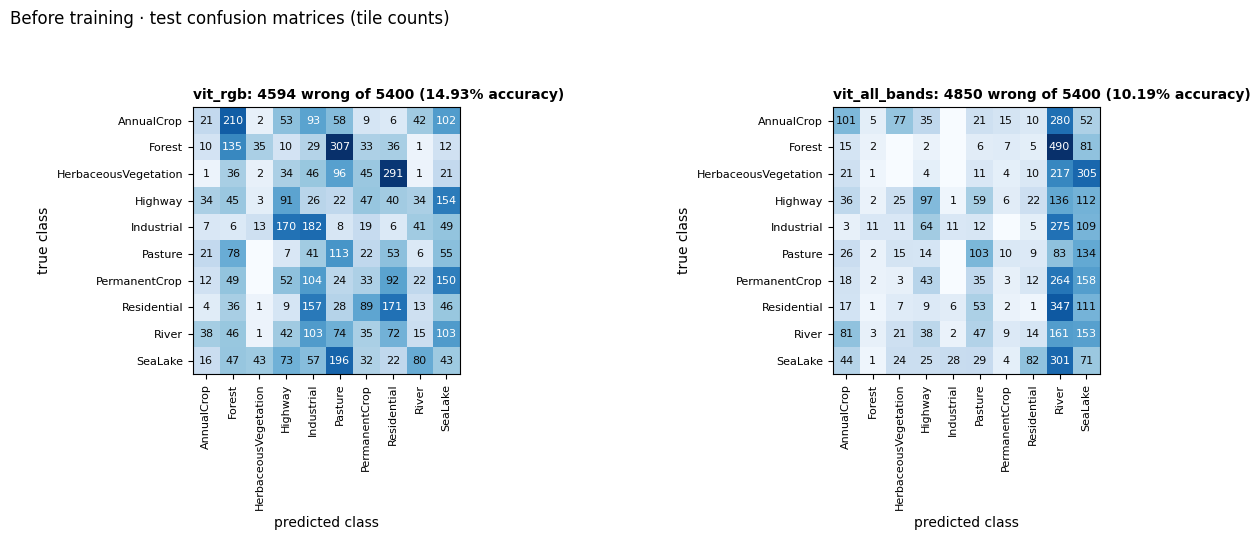

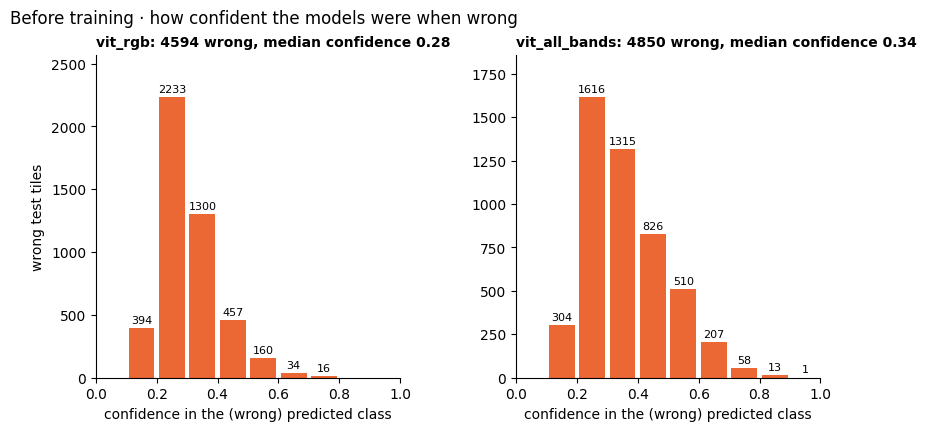

In [ ]:
plot_confusion_matrices(untrained, data.classes, "Before training · test confusion matrices (tile counts)")
plot_wrong_confidence(untrained, "Before training · how confident the models were when wrong");


**Takeaway:** before training both models are guessing, as they should be. This is the "before"
picture that training has to move away from.

* Accuracy is at chance level: 15% with RGB and 10% with 13 bands (random guessing: 10%).
* The models are unsure: the typical confidence in the predicted class is only about 0.3 (after
  training it is about 1.0).
* The random head has arbitrary favourites: the 13-band model sends 71% of all tiles to River or
  SeaLake, while the RGB model spreads its guesses more. Nothing here is learned.

## 10. Run the experiments

Each cell below runs one step of the study with the progress bar and live plot, then shows the
per-epoch table (the `phase` column marks the probe epochs). Re-running a cell reloads the saved
result, and the Optuna study resumes from `results/optuna_e2.db`. Compute on the Colab GPU used
here: about 3–4 minutes per run, about 66 minutes for the search and about 25 minutes for the extra
runs of Experiment 3b, roughly two GPU-hours in all.

### 10.1 Experiment 2 · baseline: the default recipe on RGB

##### experiment_2_baseline: The default recipe on RGB without augmentation: the reference of the search and of arm A.

=== vit_rgb_baseline: ViT-S/16 + RGB, default recipe | 3 bands | augment=False
Training on cuda (adamw, 15 epochs x 254 steps).
Training:   0%|          | 0/3810 [00:00<?, ?step/s]

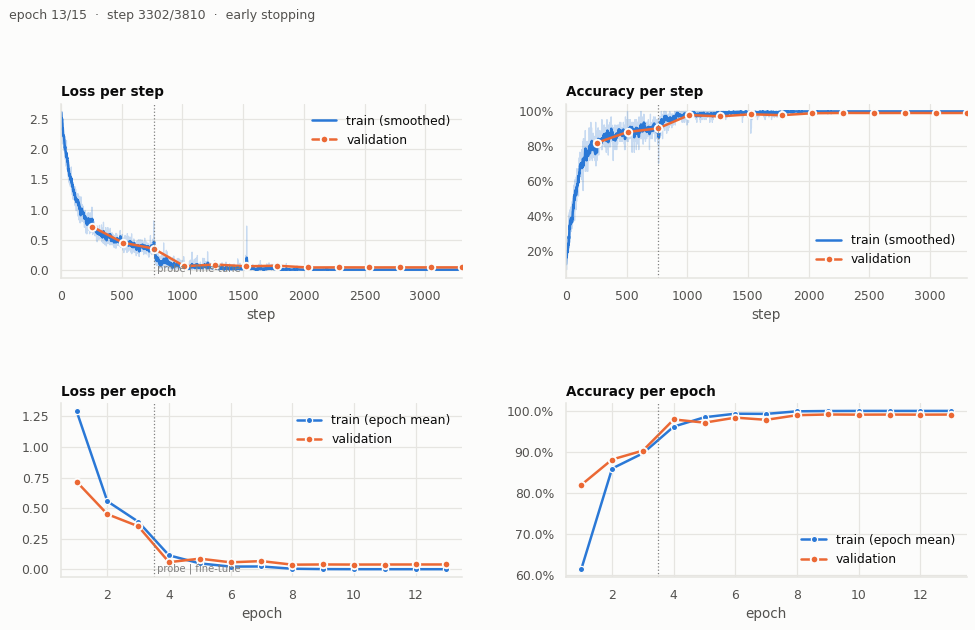

Epoch 4: backbone unfrozen, fine-tuning the whole network.
Training:  87%|████████▋ | 3302/3810 [02:55<00:26, 18.84step/s, epoch=13/15, loss=0.0001, acc=100.00%, val_loss=0.0389, val_acc=99.11%, val_f1=0.9908, lr=9.55e-06]
Early stopping: no lower validation loss for 5 validations (best 0.0373).
best validation at epoch 8 (val loss 0.0373, acc 98.96%) -> test acc 99.06%, macro F1 0.9904 | 2.9 min



,phase,train_loss,train_acc,lr,val_loss,val_acc,f1
epoch,,,,,,,
1,probe,1.2946,0.6151,1.000e-04,0.7168,0.8200,0.8094
2,probe,0.5557,0.8599,9.891e-05,0.4501,0.8819,0.8753
3,probe,0.3891,0.8969,9.568e-05,0.3516,0.9035,0.8986
4,fine-tune,0.1136,0.9619,9.045e-05,0.0578,0.9793,0.9787
5,fine-tune,0.0478,0.9846,8.346e-05,0.0863,0.9715,0.9712
6,fine-tune,0.0214,0.9932,7.500e-05,0.0565,0.9837,0.9834
7,fine-tune,0.0224,0.9928,6.545e-05,0.0664,0.9783,0.9775
8,fine-tune,0.0039,0.9990,5.523e-05,0.0373,0.9896,0.9892
9,fine-tune,9.310e-04,0.9998,4.477e-05,0.0389,0.9913,0.9910


,epoch,step,batch_index,batch_size,batch_loss,accuracy,lr
0,1,1,1,64,2.6120,0.1250,1.000e-04
1,1,2,2,64,2.3050,0.2656,1.000e-04
2,1,3,3,64,2.4628,0.1875,1.000e-04
3,1,4,4,64,2.4860,0.2031,1.000e-04
4,1,5,5,64,2.2191,0.2344,1.000e-04


In [ ]:
# Execute the baseline experiment (Experiment 2) using the default RGB recipe.
# This runs the initial ViT-S/16 model on RGB bands without augmentation.
results_2_baseline = run_experiment(EXPERIMENT_2_BASELINE, data)

# Display the summarized epoch-level training and validation metrics.
display(epoch_table(results_2_baseline["vit_rgb_baseline"].history))

# Output the first few rows of the batch-level training history.
# These represent the step losses from which the epoch means are calculated.
batch_table(results_2_baseline["vit_rgb_baseline"].history).head()

**Takeaway:** the default recipe already works very well (99.06% test accuracy, i.e. 51 wrong tiles
out of 5,400, in under 3 minutes), and the run tells a typical transfer-learning story:

* **Probe epochs 1–3 (backbone frozen):** validation accuracy climbs from 82% to 90%. Features
  learned on everyday photos already separate the land-use classes fairly well.
* **Fine-tuning from epoch 4:** unfreezing the backbone lifts validation accuracy to 98% in a single
  epoch. Adapting the features to satellite images is what really matters.
* **Memorising:** after the best epoch (epoch 8: validation loss 0.037, accuracy 99.0%) the training
  loss drops to ~0 and training accuracy reaches 100% while validation no longer improves: the model
  is memorising the training tiles. Early stopping ends the run at epoch 13 and keeps the epoch-8
  weights.
* **Sanity check:** the first batch losses are about 2.2–2.6, close to ln(10) ≈ 2.3, the loss of an
  even guess over ten classes, which is what an untrained head should give.

### 10.2 Experiment 2 · the Optuna search (the baseline is trial 0)

In [ ]:
# Execute the Optuna hyperparameter search for Experiment 2.
# This uses the baseline arm's results as trial 0 to ensure the search
# starts from and improves upon the default baseline recipe.
study = run_search(results_2_baseline["vit_rgb_baseline"])

# Display a summary table of the search trials, including the chosen
# hyperparameters, state, validation loss, and execution time.
search_table(study)


[I 2026-09-30 05:17:26,011] A new study created in RDB with name: experiment_2_recipe


--- trial 1: {'optimizer': 'sgd', 'lr': 0.012296071107325713, 'weight_decay': 0.0018662266976517971, 'batch_size': 256, 'probe_epochs': 1, 'lr_schedule': 'cosine', 'momentum': 0.8038414955136619}
Training on cuda (sgd, 15 epochs x 64 steps).
Epoch 2: backbone unfrozen, fine-tuning the whole network.
Training:  73%|███████▎  | 704/960 [02:26<00:53,  4.81step/s, epoch=11/15, loss=0.0014, acc=100.00%, val_loss=0.0377, val_acc=98.85%, val_f1=0.9881, lr=0.00307]

[I 2026-09-30 05:19:52,759] Trial 1 finished with value: 0.03708023071289063 and parameters: {'optimizer': 'sgd', 'lr_sgd': 0.012296071107325713, 'weight_decay': 0.0018662266976517971, 'batch_size': 256, 'probe_epochs': 1, 'lr_schedule': 'cosine', 'momentum': 0.8038414955136619}. Best is trial 1 with value: 0.03708023071289063.



Early stopping: no lower validation loss for 5 validations (best 0.0371).
--- trial 2: {'optimizer': 'adam', 'lr': 0.000906226347126195, 'weight_decay': 0.0249732861040606, 'batch_size': 64, 'probe_epochs': 1, 'lr_schedule': 'step'}
Training on cuda (adam, 15 epochs x 254 steps).
Epoch 2: backbone unfrozen, fine-tuning the whole network.
Training:  40%|████      | 1524/3810 [01:16<01:55, 19.88step/s, epoch=6/15, loss=0.6407, acc=62.50%, val_loss=0.7257, val_acc=74.56%, val_f1=0.7382, lr=0.000906]

[I 2026-09-30 05:21:10,030] Trial 2 finished with value: 0.20806125217013888 and parameters: {'optimizer': 'adam', 'lr_adam': 0.000906226347126195, 'weight_decay': 0.0249732861040606, 'batch_size': 64, 'probe_epochs': 1, 'lr_schedule': 'step'}. Best is trial 1 with value: 0.03708023071289063.


...

[I 2026-09-30 06:22:42,688] Trial 38 finished with value: 0.03519161930790654 and parameters: {'optimizer': 'adamw', 'lr_adamw': 4.09825130139682e-05, 'weight_decay': 0.00033875834165784377, 'batch_size': 256, 'probe_epochs': 3, 'lr_schedule': 'cosine'}. Best is trial 20 with value: 0.03314844202112269.



Early stopping: no lower validation loss for 5 validations (best 0.0352).
--- trial 39: {'optimizer': 'adamw', 'lr': 3.540772657819599e-05, 'weight_decay': 0.0010132969938442832, 'batch_size': 128, 'probe_epochs': 3, 'lr_schedule': 'cosine'}
Training on cuda (adamw, 15 epochs x 127 steps).
Epoch 4: backbone unfrozen, fine-tuning the whole network.
Trial 39 pruned at epoch 6 (val loss 0.0437).
Training:  40%|████      | 762/1905 [01:16<01:55,  9.90step/s, epoch=6/15, loss=0.0100, acc=100.00%, val_loss=0.0437, val_acc=98.76%, val_f1=0.9872, lr=2.66e-05]

[I 2026-09-30 06:24:00,249] Trial 39 pruned. 



Training stopped by callback after 762 steps in 77.0s.
best trial 20: val loss 0.0331 with {'optimizer': 'adamw', 'lr': 0.00011777287243352646, 'weight_decay': 0.00204354492253598, 'batch_size': 256, 'probe_epochs': 0, 'lr_schedule': 'cosine'}


,optimizer,lr,weight_decay,batch_size,probe_epochs,lr_schedule,state,epochs run,best val loss,minutes,momentum
trial,,,,,,,,,,,
0,adamw,1.000e-04,0.0500,64,3,cosine,complete,13,0.0373,2.9247,NaN
1,sgd,0.0123,0.0019,256,1,cosine,complete,11,0.0371,2.4451,0.8038
2,adam,9.062e-04,0.0250,64,1,step,complete,6,0.2081,1.2831,NaN
3,adam,1.676e-04,0.0071,32,0,None,complete,6,0.2236,1.2775,NaN
4,sgd,0.0948,2.024e-04,128,0,cosine,fail,5,NaN,1.0636,0.8701
5,adam,1.557e-05,0.0850,64,5,None,complete,13,0.0769,2.7699,NaN
6,sgd,0.0034,0.0037,128,3,step,pruned,8,0.0754,1.7174,0.9575
7,sgd,0.0295,0.0770,128,1,None,pruned,6,1.7183,1.2858,0.8753
8,adam,2.427e-04,0.0150,64,5,step,pruned,6,0.3299,1.2944,NaN


**Takeaway:** the search found only a small improvement. Many recipes are about equally good; what
matters most is the optimizer and its learning rate.

* **40 trials in 66 minutes:** 13 completed, 25 were pruned (behind the median at epoch 6 or later)
  and 2 failed (SGD with a learning rate of about 0.09 blew up to NaN).
* **Best: trial 20** (AdamW, learning rate 1.2e-4, weight decay 0.002, batch size 256, no probe
  epochs, cosine schedule), with a validation loss of 0.0331 against 0.0373 for the baseline. A
  small gain: ten trials lie between these two values, so the top of the search is flat.
* **AdamW is robust:** with a learning rate around 1e-4 (roughly 4e-5 to 1.2e-4), every completed
  AdamW trial landed in that same narrow band, whatever the other settings. Higher learning rates
  (2e-4 and above) were clearly worse.
* **SGD is touchy:** only 3 of its 20 trials matched AdamW; at large learning rates (about 0.03 and
  above) training broke down.
* **Plain Adam** (weight decay applied as L2) never came close in its 5 trials (best 0.077).
* Pruning roughly halved the cost of a hopeless trial (1.3–1.8 minutes instead of 2.5–3).

/tmp/ipykernel_844/4053628612.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_844/4053628612.py:11: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study);


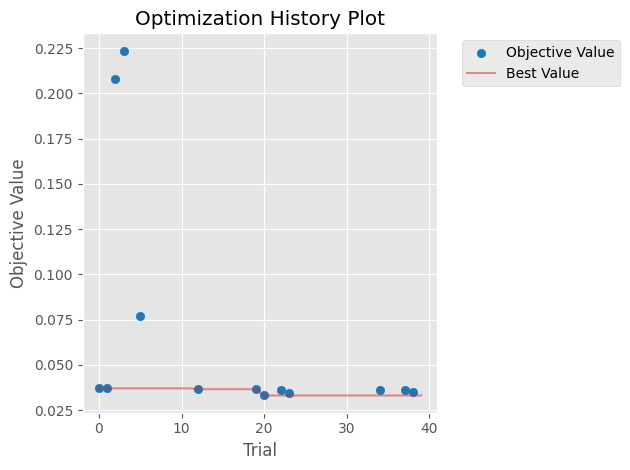

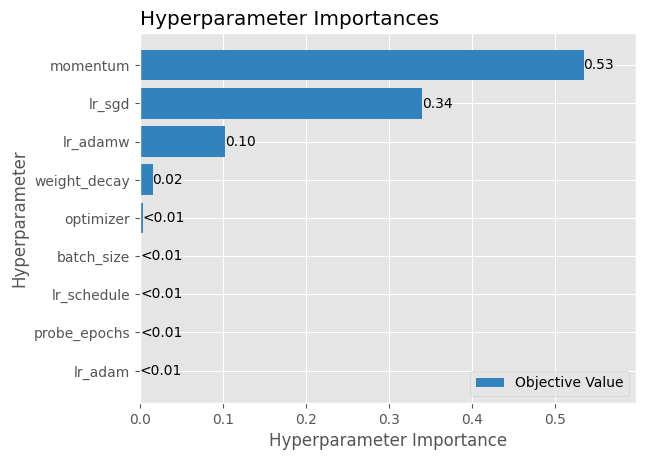

In [ ]:
# Visualize the results of the Optuna hyperparameter search.

# 1. Optimization History:
# Displays the objective value (validation loss) across all trials,
# highlighting the best values found over the course of the study.
optuna.visualization.matplotlib.plot_optimization_history(study)

# 2. Hyperparameter Importances:
# Evaluates and plots which hyperparameters had the most significant
# impact on minimizing the validation loss.
optuna.visualization.matplotlib.plot_param_importances(study);

**Takeaway:** the search had settled; more trials would most likely not have found a better recipe.

* **Left, best validation loss so far:** it falls from 0.0373 (the baseline) to 0.0331 at trial 20
  and does not improve in the last 19 trials. (Pruned and failed trials have no value here.)
* **Right, which settings mattered most:** the SGD momentum and learning rate, then the AdamW
  learning rate; batch size, probe epochs and the schedule barely register. In short: choose a
  sensible optimizer and learning rate, and the rest is detail. (A rough estimate, based on the 13
  completed trials only.)

### 10.3 Experiment 2 · arms A and B with the best recipe, and the augmentation decision

##### experiment_2: With the tuned recipe, does augmentation help? (decided on the validation split)

=== vit_rgb_tuned: ViT-S/16 + RGB, tuned recipe | 3 bands | augment=False
Training on cuda (adamw, 15 epochs x 64 steps).
Training:   0%|          | 0/960 [00:00<?, ?step/s]

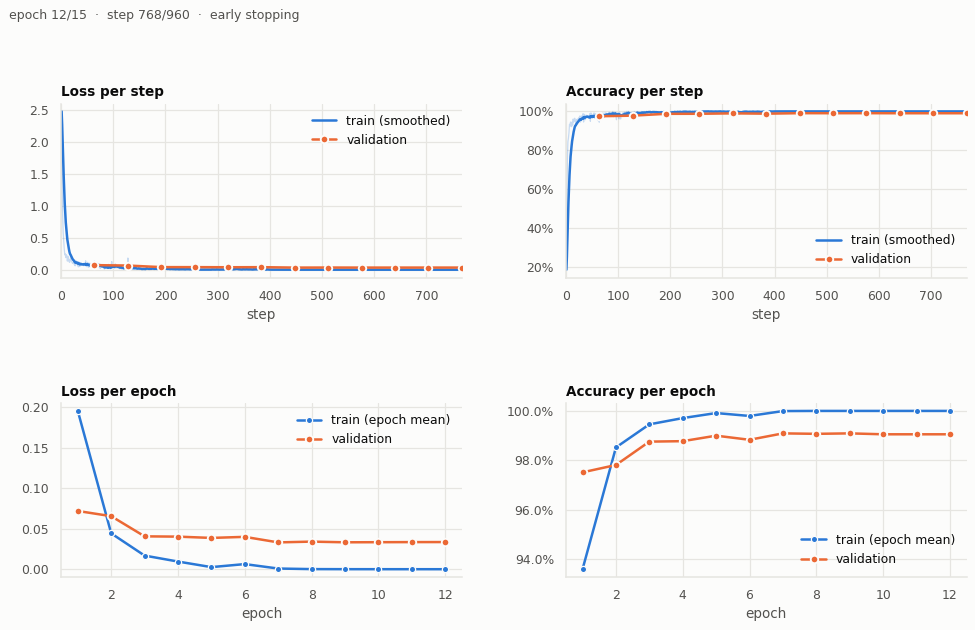

Epoch 1: backbone unfrozen, fine-tuning the whole network.
Training:  80%|████████  | 768/960 [02:41<00:40,  4.75step/s, epoch=12/15, loss=0.0001, acc=100.00%, val_loss=0.0336, val_acc=99.06%, val_f1=0.9902, lr=1.95e-05]
Early stopping: no lower validation loss for 5 validations (best 0.0331).
best validation at epoch 7 (val loss 0.0331, acc 99.09%) -> test acc 99.13%, macro F1 0.9912 | 2.7 min

=== vit_rgb_tuned_aug: ViT-S/16 + RGB, tuned recipe + augmentation | 3 bands | augment=True
Training on cuda (adamw, 15 epochs x 64 steps).
Training:   0%|          | 0/960 [00:00<?, ?step/s]

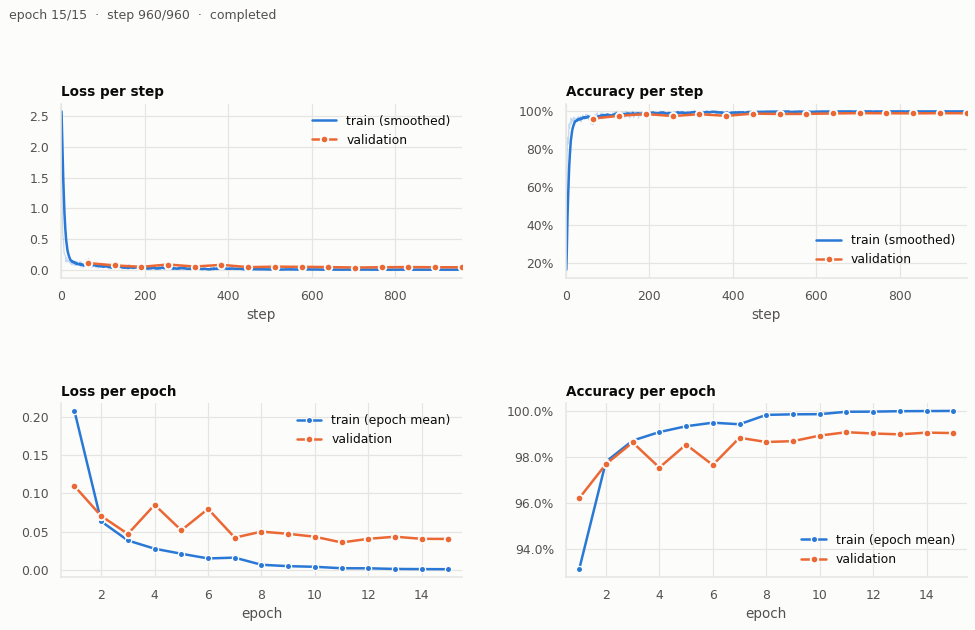

Epoch 1: backbone unfrozen, fine-tuning the whole network.
Training: 100%|██████████| 960/960 [03:48<00:00,  4.19step/s, epoch=15/15, loss=0.0004, acc=100.00%, val_loss=0.0403, val_acc=99.04%, val_f1=0.9900, lr=1.29e-06]
Training completed after 960 steps in 228.9s.
best validation at epoch 11 (val loss 0.0357, acc 99.07%) -> test acc 99.09%, macro F1 0.9907 | 3.8 min



backbone  \
experiment            arm                                                    
experiment_2_baseline vit_rgb_baseline   vit_small_patch16_224.augreg_in1k   
experiment_2          vit_rgb_tuned      vit_small_patch16_224.augreg_in1k   
                      vit_rgb_tuned_aug  vit_small_patch16_224.augreg_in1k   

                                         bands  augment optimizer        lr  \
experiment            arm                                                     
experiment_2_baseline vit_rgb_baseline       3    False     adamw 1.000e-04   
experiment_2          vit_rgb_tuned          3    False     adamw 1.178e-04   
                      vit_rgb_tuned_aug      3     True     adamw 1.178e-04   

                                         weight_decay  epochs  probe_epochs  \
experiment            arm                                                     
experiment_2_baseline vit_rgb_baseline         0.0500      15             3   
experiment_2          vit_rgb_tuned            0.0020      15             0   
                      vit_rgb_tuned_aug        0.0020      15             0   

                                         batch_size lr_schedule  \
experiment            arm                                         
experiment_2_baseline vit_rgb_baseline           64      cosine   
experiment_2          vit_rgb_tuned             256      cosine   
                      vit_rgb_tuned_aug         256      cosine   

                                         early_stopping_patience  seed  \
experiment            arm                                                
experiment_2_baseline vit_rgb_baseline                         5     0   
experiment_2          vit_rgb_tuned                            5     0   
                      vit_rgb_tuned_aug                        5     0   

                                         momentum  
experiment            arm                          
experiment_2_baseline vit_rgb_baseline     0.9000  
experiment_2          vit_rgb_tuned        0.9000  
                      vit_rgb_tuned_aug    0.9000

In [ ]:
# Construct the best configuration from the Optuna study results
# by replacing the baseline parameters with the optimal ones found.
BEST_CONFIG = replace(BASELINE_CONFIG, **recipe_from_params(study.best_params))

# Define Experiment 2: Evaluates the impact of data augmentation
# using the best hyperparameter recipe found via Optuna.
# The decision to use augmentation in subsequent experiments will be
# based on the validation split performance of these two arms.
EXPERIMENT_2 = Experiment(
    name="experiment_2",
    question="With the tuned recipe, does augmentation help? (decided on the validation split)",
    arms=(
        # Arm A: Tuned recipe without data augmentation
        Arm(
            name="vit_rgb_tuned",
            description="ViT-S/16 + RGB, tuned recipe",
            backbone=VIT_S16,
            bands=RGB_BANDS,
            augment=False
        ),
        # Arm B: Tuned recipe with data augmentation
        Arm(
            name="vit_rgb_tuned_aug",
            description="ViT-S/16 + RGB, tuned recipe + augmentation",
            backbone=VIT_S16,
            bands=RGB_BANDS,
            augment=True
        ),
    ),
    config=BEST_CONFIG,
)

# Execute Experiment 2 and collect the results
results_2 = run_experiment(EXPERIMENT_2, data)

# Display a summary table comparing the baseline experiment and Experiment 2
design_table((EXPERIMENT_2_BASELINE, EXPERIMENT_2))


**Takeaway:** the tuned recipe is reproducible, and augmentation does not improve it.

* **Arm A** (`vit_rgb_tuned`) is trial 20 trained again with the same seed, and it gets exactly the
  same result (lowest validation loss 0.0331, early stop at epoch 12): runs are reproducible. Test:
  99.13% (47 wrong).
* **Arm B** (same recipe + augmentation) learns a little more slowly (best epoch 11, uses all 15
  epochs), ends slightly worse on validation (loss 0.0357) and practically the same on test (99.09%,
  49 wrong).
* The design table above confirms that the two arms differ only in augmentation.

A plausible reason for the missing gain: the model is already near its ceiling (about 50 wrong tiles
left), and overhead images have no natural "up", so the training set already shows fields and roads
in every orientation.

In [ ]:
# Evaluate the impact of data augmentation on the validation split.
# The test split is strictly held out from this decision.

arm_tuned = results_2["vit_rgb_tuned"]
arm_tuned_aug = results_2["vit_rgb_tuned_aug"]

# Calculate validation accuracy for both arms
val_acc_tuned = accuracy_score(arm_tuned.val_y_true, arm_tuned.val_y_pred)
val_acc_tuned_aug = accuracy_score(arm_tuned_aug.val_y_true, arm_tuned_aug.val_y_pred)

# Perform McNemar's test to check for statistical significance in prediction differences
p_augmentation = mcnemar_pvalue(
    y_true=arm_tuned.val_y_true,
    pred_baseline=arm_tuned.val_y_pred,
    pred_treatment=arm_tuned_aug.val_y_pred
)

# Adopt augmentation only if it yields a statistically significant improvement
# (p < 0.05) and the absolute validation accuracy is indeed higher.
is_significant = p_augmentation < 0.05
is_better = val_acc_tuned_aug > val_acc_tuned
USE_AUGMENTATION = bool(is_significant and is_better)

# Determine the reference RGB arm that Experiment 3 will be compared against
RGB_REFERENCE = arm_tuned_aug if USE_AUGMENTATION else arm_tuned

# Display the decision summary
print(
    f"Validation Accuracy:\n"
    f" - Tuned (No Aug): {val_acc_tuned:.2%}\n"
    f" - Tuned (+ Aug):  {val_acc_tuned_aug:.2%}\n"
    f" - McNemar p-value: {p_augmentation:.3f}\n\n"
    f"-> Experiment 3 will run {'WITH' if USE_AUGMENTATION else 'WITHOUT'} augmentation, "
    f"against '{RGB_REFERENCE.arm.name}'."
)


Validation Accuracy:
 - Tuned (No Aug): 99.09%
 - Tuned (+ Aug):  99.07%
 - McNemar p-value: 1.000

-> Experiment 3 will run WITHOUT augmentation, against 'vit_rgb_tuned'.


**Takeaway:** augmentation brings no measurable gain, so Experiment 3 runs **without** it.

On the validation split the two arms are level: 99.09% without augmentation against 99.07% with
it, and 25 tiles that only arm A gets right against 24 that only arm B gets right, as even as a coin
flip (McNemar p = 1.0). By the rule fixed in section 3, the 13-band model is therefore compared with
`vit_rgb_tuned`. The test split played no part in this choice.

### 10.4 Experiment 3 · the research question, and Experiment 3b · the same question under the five best recipes

**Experiment 3** trains the 13-band model with the recipe chosen in Experiment 2 (trial 20) and
compares it with `vit_rgb_tuned` on the test split: the main test of the study.

That recipe was tuned on RGB, so it might favour RGB. **Experiment 3b** checks this: the five best
completed trials of the search (20, 23, 38, 37, 22) are each trained on RGB and on 13 bands
(existing runs are reused), and then each input gets whichever of the five recipes suits it best,
chosen on the *validation* loss. The rule is printed before the runs; test scores are reported for
every run but never used to choose.

Selection rule, fixed before the runs: for each input, the recipe with the lowest VALIDATION loss among the 5 candidates; the test split plays no part in the choice.

Trial 20, rgb: reusing vit_rgb_tuned
##### experiment_3b_trial20: Recipe of trial 20 (search val loss 0.0331) on both inputs

=== vit_all_bands_t20: ViT-S/16 + 13 bands, recipe of trial 20 | 13 bands | augment=False
Training on cuda (adamw, 15 epochs x 64 steps).
Training:   0%|          | 0/960 [00:00<?, ?step/s]

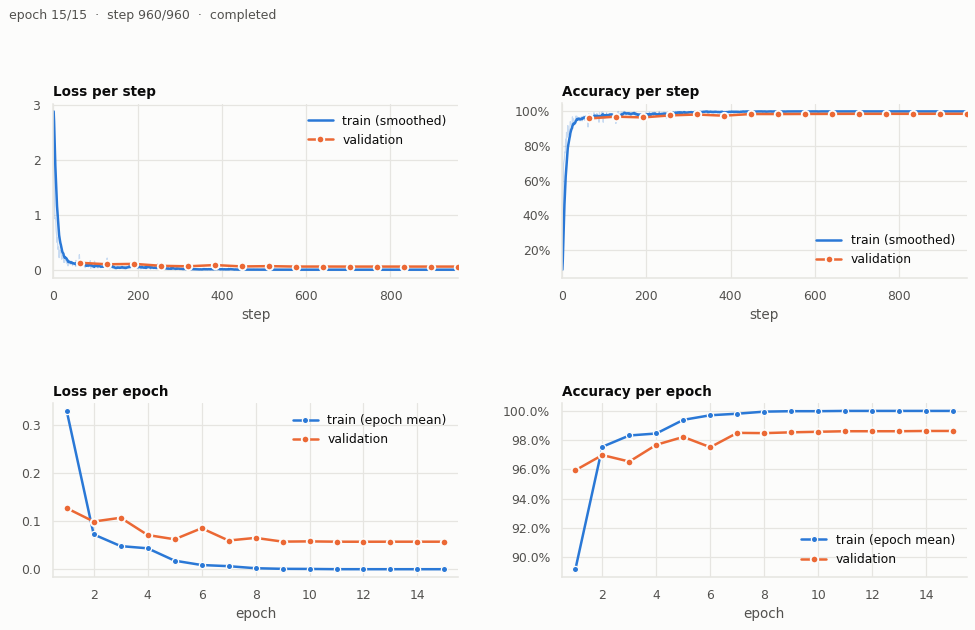

Epoch 1: backbone unfrozen, fine-tuning the whole network.
Training: 100%|██████████| 960/960 [03:33<00:00,  4.51step/s, epoch=15/15, loss=0.0002, acc=100.00%, val_loss=0.0572, val_acc=98.63%, val_f1=0.9857, lr=1.29e-06]
Training completed after 960 steps in 213.0s.
best validation at epoch 12 (val loss 0.0571, acc 98.61%) -> test acc 98.87%, macro F1 0.9885 | 3.6 min

##### experiment_3b_trial23: Recipe of trial 23 (search val loss 0.0343) on both inputs

=== vit_rgb_t23: ViT-S/16 + RGB, recipe of trial 23 | 3 bands | augment=False
Training on cuda (sgd, 15 epochs x 254 steps).
Training:   0%|          | 0/3810 [00:00<?, ?step/s]

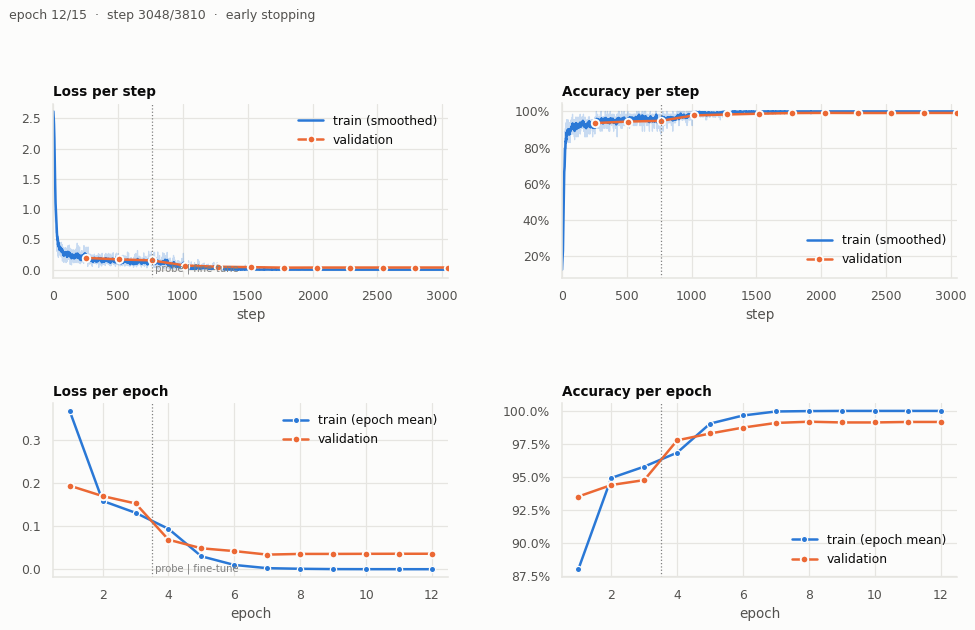

Epoch 4: backbone unfrozen, fine-tuning the whole network.
Training:  80%|████████  | 3048/3810 [02:41<00:40, 18.82step/s, epoch=12/15, loss=0.0000, acc=100.00%, val_loss=0.0363, val_acc=99.17%, val_f1=0.9913, lr=0.000273]
Early stopping: no lower validation loss for 5 validations (best 0.0343).
best validation at epoch 7 (val loss 0.0343, acc 99.09%) -> test acc 98.98%, macro F1 0.9895 | 2.7 min

=== vit_all_bands_t23: ViT-S/16 + 13 bands, recipe of trial 23 | 13 bands | augment=False
Training on cuda (sgd, 15 epochs x 254 steps).
Training:   0%|          | 0/3810 [00:00<?, ?step/s]

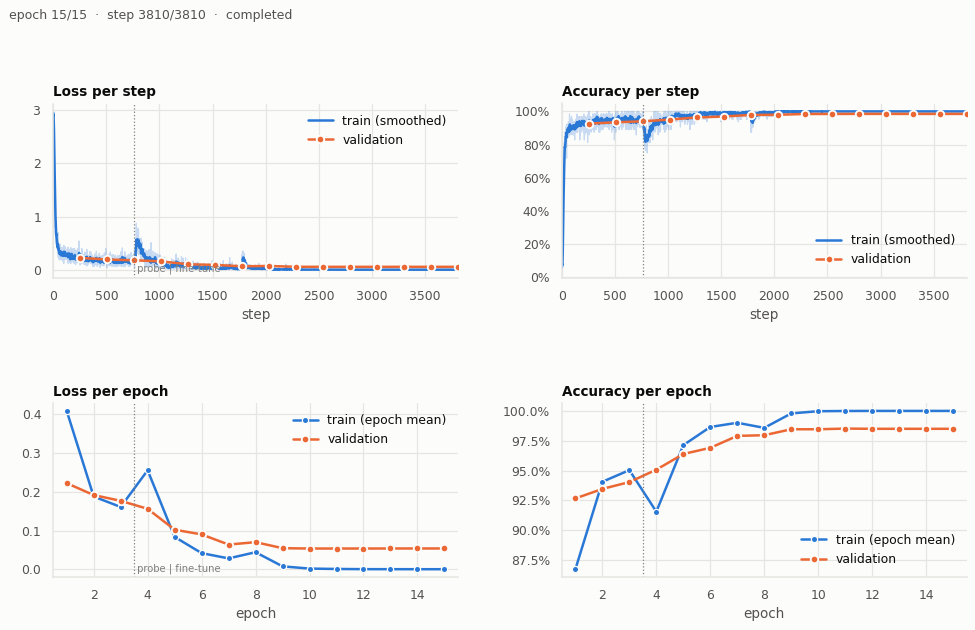

Epoch 4: backbone unfrozen, fine-tuning the whole network.
Training: 100%|██████████| 3810/3810 [03:36<00:00, 17.60step/s, epoch=15/15, loss=0.0001, acc=100.00%, val_loss=0.0542, val_acc=98.50%, val_f1=0.9845, lr=1.8e-05]
Training completed after 3810 steps in 216.5s.
best validation at epoch 12 (val loss 0.0540, acc 98.50%) -> test acc 98.50%, macro F1 0.9846 | 3.6 min

##### experiment_3b_trial38: Recipe of trial 38 (search val loss 0.0352) on both inputs

=== vit_rgb_t38: ViT-S/16 + RGB, recipe of trial 38 | 3 bands | augment=False
Training on cuda (adamw, 15 epochs x 64 steps).
Training:   0%|          | 0/960 [00:00<?, ?step/s]

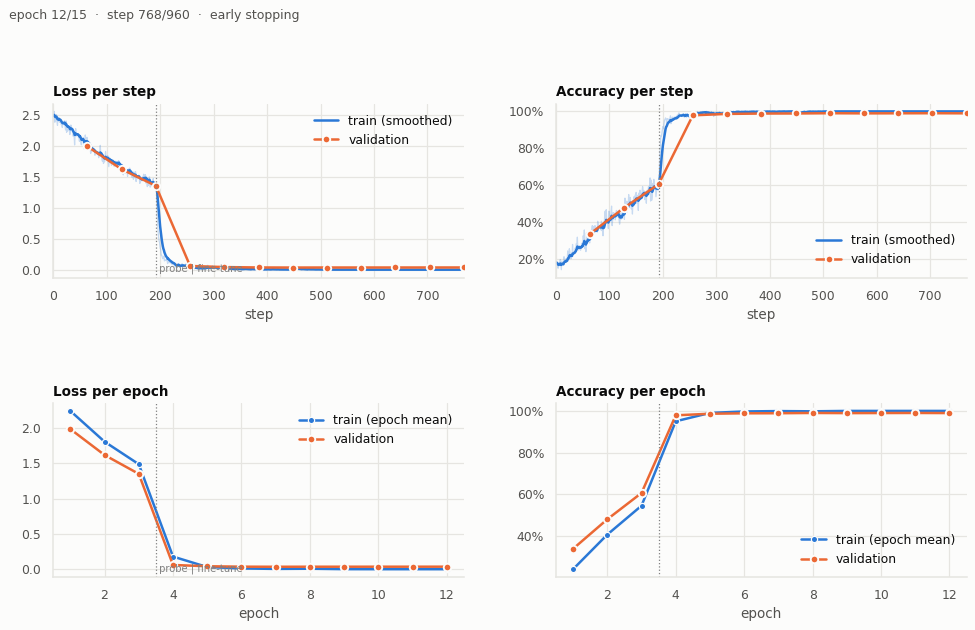

Epoch 4: backbone unfrozen, fine-tuning the whole network.
Training:  80%|████████  | 768/960 [02:41<00:40,  4.74step/s, epoch=12/15, loss=0.0004, acc=100.00%, val_loss=0.0364, val_acc=98.96%, val_f1=0.9893, lr=6.78e-06]
Early stopping: no lower validation loss for 5 validations (best 0.0352).
best validation at epoch 7 (val loss 0.0352, acc 98.89%) -> test acc 98.81%, macro F1 0.9879 | 2.7 min

=== vit_all_bands_t38: ViT-S/16 + 13 bands, recipe of trial 38 | 13 bands | augment=False
Training on cuda (adamw, 15 epochs x 64 steps).
Training:   0%|          | 0/960 [00:00<?, ?step/s]

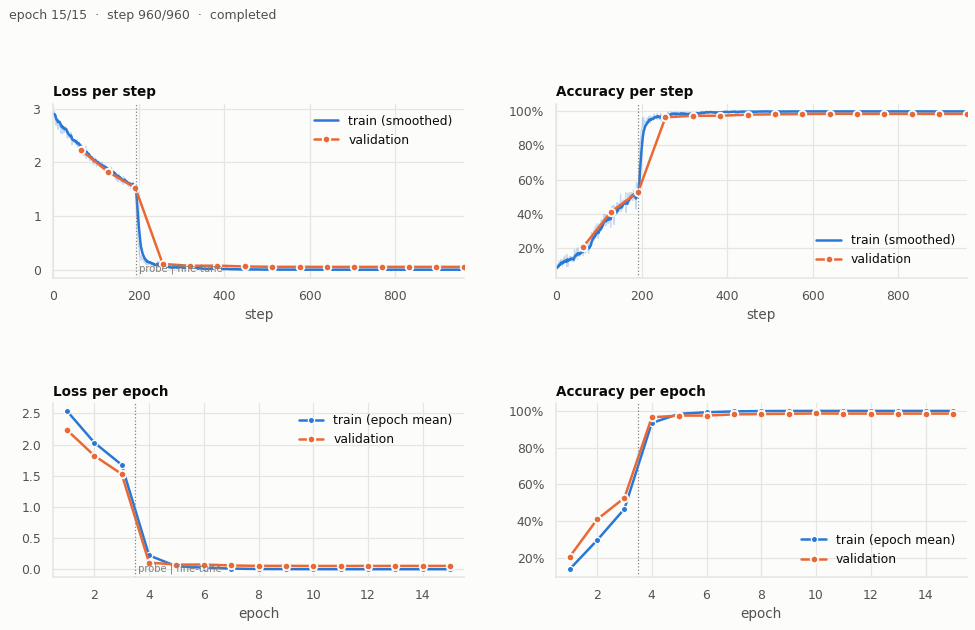

Epoch 4: backbone unfrozen, fine-tuning the whole network.
Training: 100%|██████████| 960/960 [03:32<00:00,  4.51step/s, epoch=15/15, loss=0.0004, acc=100.00%, val_loss=0.0535, val_acc=98.54%, val_f1=0.9847, lr=4.48e-07]
Training completed after 960 steps in 212.8s.
best validation at epoch 11 (val loss 0.0529, acc 98.54%) -> test acc 98.65%, macro F1 0.9859 | 3.6 min

##### experiment_3b_trial37: Recipe of trial 37 (search val loss 0.0361) on both inputs

=== vit_rgb_t37: ViT-S/16 + RGB, recipe of trial 37 | 3 bands | augment=False
Training on cuda (adamw, 15 epochs x 64 steps).
Training:   0%|          | 0/960 [00:00<?, ?step/s]

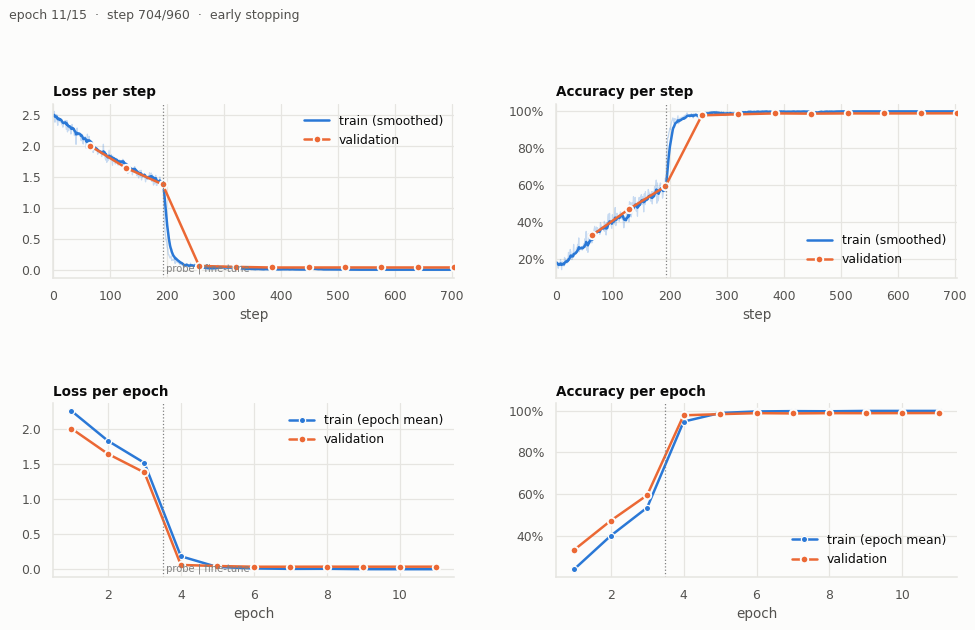

Epoch 4: backbone unfrozen, fine-tuning the whole network.
Training:  73%|███████▎  | 704/960 [02:28<00:53,  4.75step/s, epoch=11/15, loss=0.0011, acc=100.00%, val_loss=0.0368, val_acc=98.98%, val_f1=0.9894, lr=9.9e-06]
Early stopping: no lower validation loss for 5 validations (best 0.0361).
best validation at epoch 6 (val loss 0.0361, acc 98.93%) -> test acc 98.81%, macro F1 0.9878 | 2.5 min

=== vit_all_bands_t37: ViT-S/16 + 13 bands, recipe of trial 37 | 13 bands | augment=False
Training on cuda (adamw, 15 epochs x 64 steps).
Training:   0%|          | 0/960 [00:00<?, ?step/s]

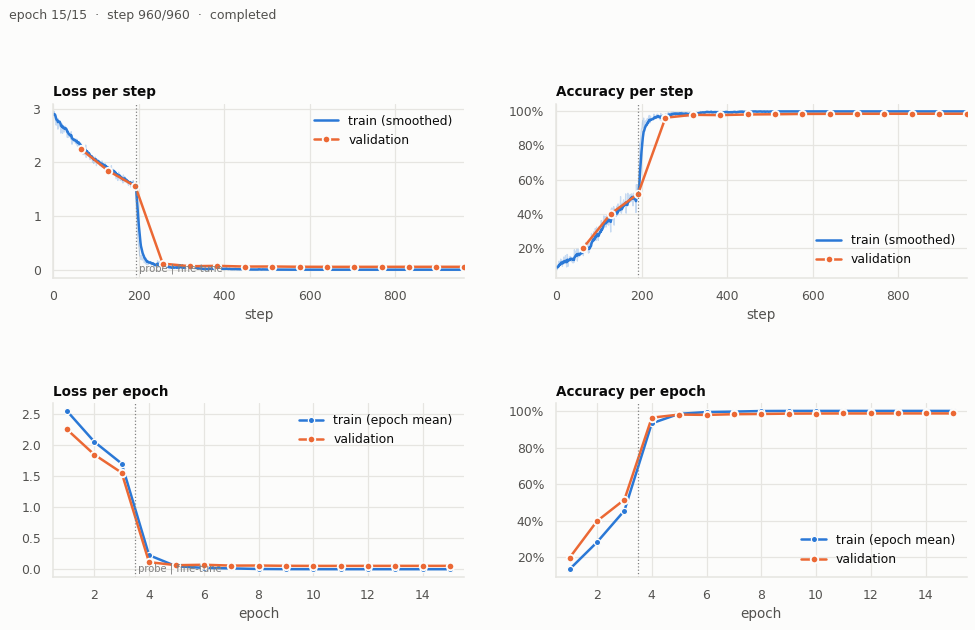

Epoch 4: backbone unfrozen, fine-tuning the whole network.
Training: 100%|██████████| 960/960 [03:32<00:00,  4.51step/s, epoch=15/15, loss=0.0005, acc=100.00%, val_loss=0.0546, val_acc=98.63%, val_f1=0.9857, lr=4.33e-07]
Training completed after 960 steps in 212.9s.
best validation at epoch 11 (val loss 0.0539, acc 98.61%) -> test acc 98.74%, macro F1 0.9868 | 3.6 min

##### experiment_3b_trial22: Recipe of trial 22 (search val loss 0.0362) on both inputs

=== vit_rgb_t22: ViT-S/16 + RGB, recipe of trial 22 | 3 bands | augment=False
Training on cuda (sgd, 15 epochs x 254 steps).
Training:   0%|          | 0/3810 [00:00<?, ?step/s]

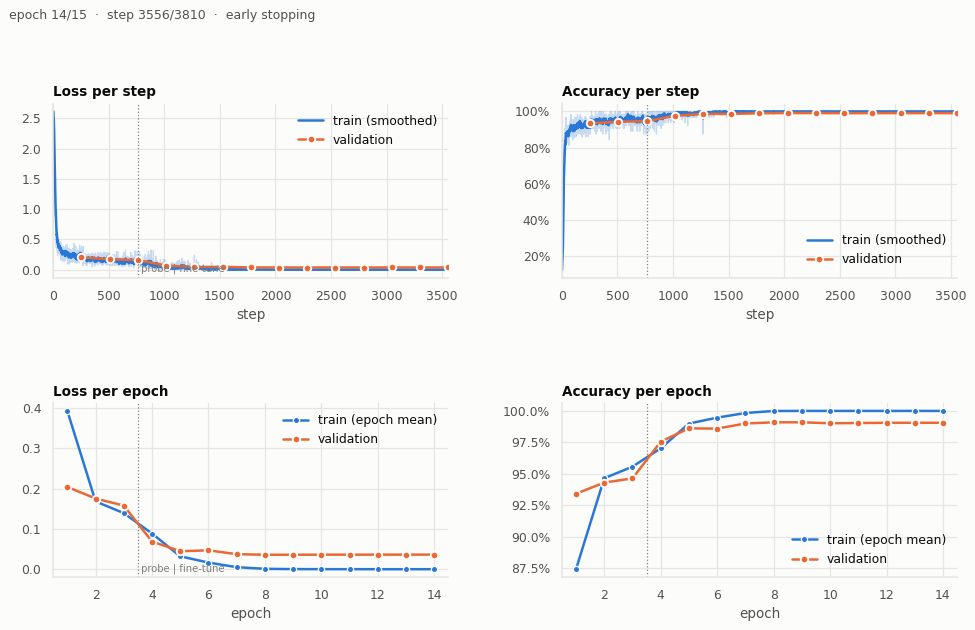

Epoch 4: backbone unfrozen, fine-tuning the whole network.
Training:  93%|█████████▎| 3556/3810 [03:08<00:13, 18.83step/s, epoch=14/15, loss=0.0007, acc=100.00%, val_loss=0.0366, val_acc=99.06%, val_f1=0.9902, lr=5.66e-05]
Early stopping: no lower validation loss for 5 validations (best 0.0362).
best validation at epoch 9 (val loss 0.0362, acc 99.09%) -> test acc 99.07%, macro F1 0.9905 | 3.2 min

=== vit_all_bands_t22: ViT-S/16 + 13 bands, recipe of trial 22 | 13 bands | augment=False
Training on cuda (sgd, 15 epochs x 254 steps).
Training:   0%|          | 0/3810 [00:00<?, ?step/s]

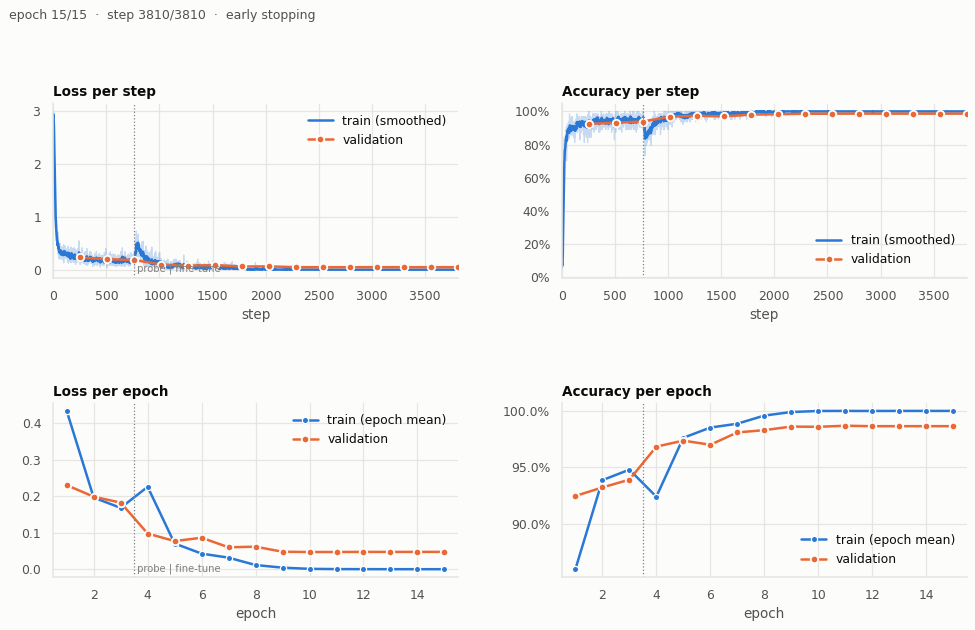

Epoch 4: backbone unfrozen, fine-tuning the whole network.
Training: 100%|██████████| 3810/3810 [03:35<00:00, 17.65step/s, epoch=15/15, loss=0.0000, acc=100.00%, val_loss=0.0481, val_acc=98.65%, val_f1=0.9860, lr=1.43e-05]
Early stopping: no lower validation loss for 5 validations (best 0.0477).
best validation at epoch 10 (val loss 0.0477, acc 98.59%) -> test acc 98.80%, macro F1 0.9876 | 3.6 min


Experiment 3 (primary), recipe of trial 20:
 - RGB test accuracy: 99.13%
 - 13 bands test accuracy: 98.87%
 - McNemar p-value = 0.1302


,optimizer,lr,weight_decay,batch_size,probe_epochs,lr_schedule,RGB val loss,RGB val acc,RGB test acc,13 val loss,13 val acc,13 test acc,Δ test (13 − RGB),only RGB / only 13 right,McNemar p,momentum
trial,,,,,,,,,,,,,,,,
20,adamw,1.178e-04,0.0020,256,0,cosine,0.0331,0.9909,0.9913,0.0571,0.9861,0.9887,-0.0026,44 / 30,0.1302,NaN
23,sgd,0.0016,1.841e-04,64,3,cosine,0.0343,0.9909,0.9898,0.0540,0.9850,0.9850,-0.0048,57 / 31,0.0073,0.9323
38,adamw,4.098e-05,3.388e-04,256,3,cosine,0.0352,0.9889,0.9881,0.0529,0.9854,0.9865,-0.0017,47 / 38,0.3857,NaN
37,adamw,3.961e-05,3.360e-04,256,3,cosine,0.0361,0.9893,0.9881,0.0539,0.9861,0.9874,-7.407e-04,46 / 42,0.7493,NaN
22,sgd,0.0013,2.434e-04,64,3,cosine,0.0362,0.9909,0.9907,0.0477,0.9859,0.9880,-0.0028,45 / 30,0.1053,0.9352



Experiment 3b, selected on validation loss:
 - RGB -> vit_rgb_tuned (val loss 0.0331)
 - 13 bands -> vit_all_bands_t22 (val loss 0.0477)

Test split comparison (selected arms):
 - RGB test accuracy: 99.13%
 - 13 bands test accuracy: 98.80%
 - McNemar p-value = 0.0444

13 bands beat RGB on the test split under 0 of the 5 recipes.


In [ ]:
"""
Experiment 3b: the five best recipes, each applied to both inputs
-----------------------------------------------------------------
Experiment 3 used one recipe, the best of a search run on RGB. This extension asks whether the answer depends on that
choice: the five best completed trials of the search (lowest validation loss) are each applied to RGB and to the
13 bands, with the augmentation decision of Experiment 2. Then each input gets the recipe that suits it best among
the same five candidates, chosen on the VALIDATION split (lowest validation loss, the criterion of the search).
The test split is reported for every run but never used to choose; the primary result stays the one of Experiment 3.
Runs that already exist with the same recipe (the E2 baseline, arm A and the Experiment 3 arm) are reused.
"""

from typing import Any, Dict, List, Optional, Tuple
from dataclasses import replace
import optuna
import pandas as pd

TOP_K = 5


def get_top_completed_trials(study: optuna.Study, top_k: int = 5) -> List[optuna.trial.FrozenTrial]:
    """
    Retrieve the top 'k' completed trials from the given Optuna study based on validation loss.

    Args:
        study: The completed Optuna study.
        top_k: Number of top trials to retrieve.

    Returns:
        A list of the top 'k' completed FrozenTrial objects.
    """
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    return sorted(completed, key=lambda t: t.value)[:top_k]


def extract_recipe(config: TrainingConfig) -> Dict[str, Any]:
    """
    Extract the hyperparameter recipe from a TrainingConfig.

    Args:
        config: The training configuration object.

    Returns:
        A dictionary containing the relevant recipe fields.
    """
    return {name: getattr(config, name) for name in RECIPE_FIELDS}


def find_matching_result(
    pool: Dict[str, RunResult],
    bands: Tuple[str, ...],
    augment: bool,
    config: TrainingConfig
) -> Optional[RunResult]:
    """
    Search for an existing run result that matches the given arm parameters and recipe.

    Args:
        pool: Dictionary of existing run results.
        bands: Tuple of spectral band names used in the run.
        augment: Boolean indicating if data augmentation was used.
        config: The training configuration.

    Returns:
        The matching RunResult if found, otherwise None.
    """
    target_recipe = extract_recipe(config)
    for result in pool.values():
        if (result.arm.bands, result.arm.augment) == (bands, augment):
            result_recipe = {name: result.config.get(name) for name in RECIPE_FIELDS}
            if result_recipe == target_recipe:
                return result
    return None


def execute_experiment_3b(
    top_trials: List[optuna.trial.FrozenTrial],
    pool: Dict[str, RunResult]
) -> Dict[Tuple[int, str], RunResult]:
    """
    Execute Experiment 3b over the top trials for both RGB and 13-band inputs.

    Args:
        top_trials: List of top Optuna trials to evaluate.
        pool: Existing pool of RunResult objects to reuse if a match is found.

    Returns:
        A dictionary mapping (trial_number, input_type) to the corresponding RunResult.
    """
    inputs = {"rgb": RGB_BANDS, "all_bands": ALL_BANDS}
    runs_3b: Dict[Tuple[int, str], RunResult] = {}

    for trial in top_trials:
        config = replace(BASELINE_CONFIG, **recipe_from_params(trial.params))
        new_arms = []

        for tag, bands in inputs.items():
            existing_result = find_matching_result(pool, bands, USE_AUGMENTATION, config)
            if existing_result is not None:
                runs_3b[(trial.number, tag)] = existing_result
                print(f"Trial {trial.number}, {tag}: reusing {existing_result.arm.name}")
            else:
                label = "RGB" if tag == "rgb" else "13 bands"
                augment_suffix = " + augmentation" if USE_AUGMENTATION else ""
                arm_name = f"vit_{tag}_t{trial.number}"
                arm_desc = f"ViT-S/16 + {label}, recipe of trial {trial.number}{augment_suffix}"
                new_arms.append(Arm(arm_name, arm_desc, VIT_S16, bands, augment=USE_AUGMENTATION))

        if new_arms:
            exp_name = f"experiment_3b_trial{trial.number}"
            exp_desc = f"Recipe of trial {trial.number} (search val loss {trial.value:.4f}) on both inputs"
            experiment = Experiment(exp_name, exp_desc, tuple(new_arms), config)

            results = run_experiment(experiment, data)
            for name, result in results.items():
                tag = name.rsplit("_t", 1)[0].removeprefix("vit_")
                runs_3b[(trial.number, tag)] = result

    return runs_3b


def generate_experiment_3b_table(
    runs: Dict[Tuple[int, str], RunResult],
    trials: List[optuna.trial.FrozenTrial]
) -> pd.DataFrame:
    """
    Generate a summary table for Experiment 3b comparing RGB and 13 bands per recipe.

    Args:
        runs: Dictionary of run results mapped by (trial_number, input_type).
        trials: List of Optuna trials evaluated.

    Returns:
        A pandas DataFrame summarizing the validation and test metrics.
    """
    rows = []
    for trial in trials:
        rgb = runs[(trial.number, "rgb")]
        all_bands = runs[(trial.number, "all_bands")]

        best_rgb = best_validation(rgb)
        best_all = best_validation(all_bands)

        rgb_only = int(((rgb.y_pred == rgb.y_true) & (all_bands.y_pred != rgb.y_true)).sum())
        all_only = int(((all_bands.y_pred == rgb.y_true) & (rgb.y_pred != rgb.y_true)).sum())

        row = {
            "trial": trial.number,
            **recipe_from_params(trial.params),
            "RGB val loss": best_rgb.loss,
            "RGB val acc": best_rgb.accuracy,
            "RGB test acc": rgb.test_accuracy,
            "13 val loss": best_all.loss,
            "13 val acc": best_all.accuracy,
            "13 test acc": all_bands.test_accuracy,
            "Δ test (13 − RGB)": all_bands.test_accuracy - rgb.test_accuracy,
            "only RGB / only 13 right": f"{rgb_only} / {all_only}",
            "McNemar p": mcnemar_pvalue(rgb.y_true, rgb.y_pred, all_bands.y_pred)
        }
        rows.append(row)

    return pd.DataFrame(rows).set_index("trial").pipe(round_sig)


if __name__ == "__main__":
    print(f"Selection rule, fixed before the runs: for each input, the recipe with the lowest VALIDATION loss among the "
          f"{TOP_K} candidates; the test split plays no part in the choice.\n")

    # 1. Retrieve the top completed trials from Optuna search
    top_trials = get_top_completed_trials(study, top_k=TOP_K)
    best_trial = top_trials[0]  # same as study.best_trial: the recipe of Experiment 3

    # 2. Pool existing run results to avoid retraining (Experiment 3 is produced below)
    result_pool = results_2_baseline | results_2

    # 3. Execute Experiment 3b across the best trials
    runs_3b = execute_experiment_3b(top_trials, result_pool)

    # 4. Experiment 3 (primary result): the best recipe applied to both inputs
    results_3 = {runs_3b[(best_trial.number, tag)].arm.name: runs_3b[(best_trial.number, tag)]
                 for tag in ("rgb", "all_bands")}
    rgb_3 = runs_3b[(best_trial.number, "rgb")]
    all_3 = runs_3b[(best_trial.number, "all_bands")]
    p_3 = mcnemar_pvalue(rgb_3.y_true, rgb_3.y_pred, all_3.y_pred)

    print(f"\nExperiment 3 (primary), recipe of trial {best_trial.number}:")
    print(f" - RGB test accuracy: {rgb_3.test_accuracy:.2%}")
    print(f" - 13 bands test accuracy: {all_3.test_accuracy:.2%}")
    print(f" - McNemar p-value = {p_3:.4f}")

    # 5. Generate and display the results table
    table_3b = generate_experiment_3b_table(runs_3b, top_trials)
    display(table_3b)

    # 6. Selection on the validation split: one recipe per input, followed by a paired comparison
    inputs = ["rgb", "all_bands"]
    selected = {
        tag: min((runs_3b[(t.number, tag)] for t in top_trials), key=lambda r: best_validation(r).loss)
        for tag in inputs
    }

    rgb_best = selected["rgb"]
    all_best = selected["all_bands"]
    p_selected = mcnemar_pvalue(rgb_best.y_true, rgb_best.y_pred, all_best.y_pred)
    wins = int((table_3b["Δ test (13 − RGB)"] > 0).sum())

    print(f"\nExperiment 3b, selected on validation loss:")
    print(f" - RGB -> {rgb_best.arm.name} (val loss {best_validation(rgb_best).loss:.4f})")
    print(f" - 13 bands -> {all_best.arm.name} (val loss {best_validation(all_best).loss:.4f})")
    print(f"\nTest split comparison (selected arms):")
    print(f" - RGB test accuracy: {rgb_best.test_accuracy:.2%}")
    print(f" - 13 bands test accuracy: {all_best.test_accuracy:.2%}")
    print(f" - McNemar p-value = {p_selected:.4f}")
    print(f"\n13 bands beat RGB on the test split under {wins} of the {len(top_trials)} recipes.")


**Takeaway:** the 13 bands do **not** beat RGB. Under every recipe the 13-band model is slightly
*worse*; the gap is small, but it always points the same way.

* **Experiment 3 (the main test).** With the tuned recipe: 98.87% (61 wrong) with 13 bands against
  99.13% (47 wrong) with RGB. Of the 74 tiles where the two disagree, RGB is right on 44 and the
  13-band model on 30: p = 0.13, not significant on its own. The 13-band model is also worse on
  validation (loss 0.057 vs 0.033) and needs more epochs to get there (best epoch 12 vs 7).
* **Experiment 3b (is it the recipe?).** No. Under all five recipes the 13-band model is below RGB
  on test (by 0.07 to 0.48 points; 0 wins out of 5) and has a higher validation loss (0.048–0.057 vs
  0.033–0.036). One gap is significant (trial 23, p = 0.007, which would survive a correction for
  five tests); the other four are not (p = 0.11 to 0.75).
* **Each input with its own best recipe.** RGB keeps trial 20; the 13-band input prefers trial 22
  (SGD). Even then 13 bands is behind: 98.80% vs 99.13%, p = 0.044 (borderline significant).

**What might explain it** (hypotheses, not tested here):

* *The pretrained weights are made for RGB.* The backbone learned from RGB photos, and the extra
  bands enter through copied RGB filters rather than filters learned for them. The 13-band model
  starts behind in every run (sections 10.5 and 11.1) and usually stays a little behind, although
  it fits the training tiles perfectly.
* *RGB is already near the ceiling.* At 99% only about 50 test tiles are wrong, and several of them
  look like ambiguous labels (section 11) that no extra band can fix. There is little left to gain,
  but room to lose.
* *Some bands add noise.* B09 and B10 mostly see the atmosphere (section 4), so they may carry more
  about the acquisition day than about the land.

### 10.5 Extra · the earlier runs: default recipe with augmentation (reloaded if already saved)

Running Extra Experiment (Default Recipe + Augmentation)...
##### extra: Earlier runs: does the answer hold with the default recipe and augmentation?

=== vit_rgb: ViT-S/16 + RGB + augmentation | 3 bands | augment=True
Training on cuda (adamw, 15 epochs x 254 steps).
Training:   0%|          | 0/3810 [00:00<?, ?step/s]

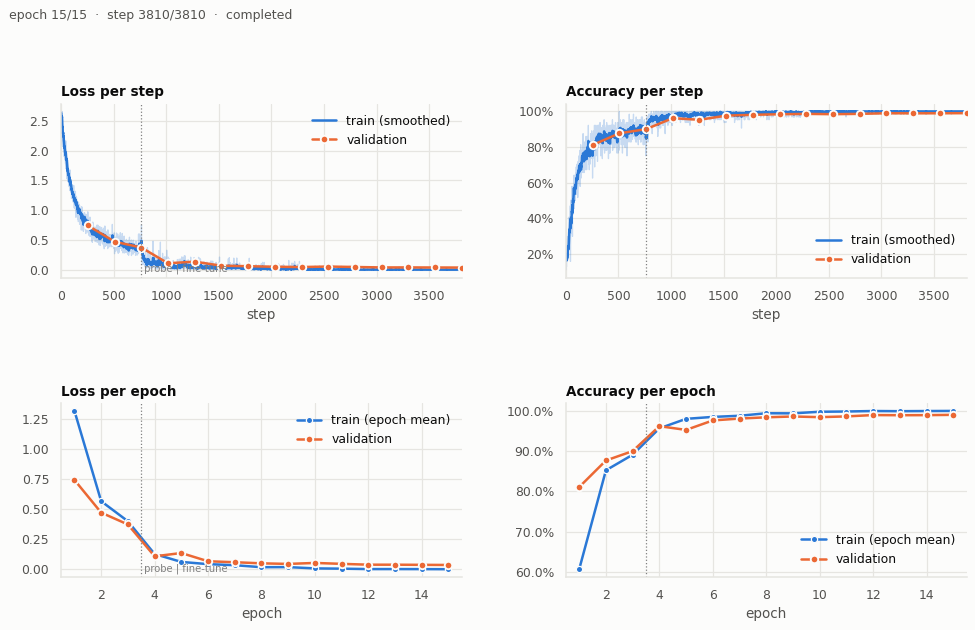

Epoch 4: backbone unfrozen, fine-tuning the whole network.
Training: 100%|██████████| 3810/3810 [03:56<00:00, 16.12step/s, epoch=15/15, loss=0.0001, acc=100.00%, val_loss=0.0361, val_acc=99.02%, val_f1=0.9898, lr=1.09e-06]
Training completed after 3810 steps in 236.4s.
best validation at epoch 15 (val loss 0.0361, acc 99.02%) -> test acc 99.11%, macro F1 0.9910 | 3.9 min

=== vit_all_bands: ViT-S/16 + 13 bands + augmentation | 13 bands | augment=True
Training on cuda (adamw, 15 epochs x 254 steps).
Training:   0%|          | 0/3810 [00:00<?, ?step/s]

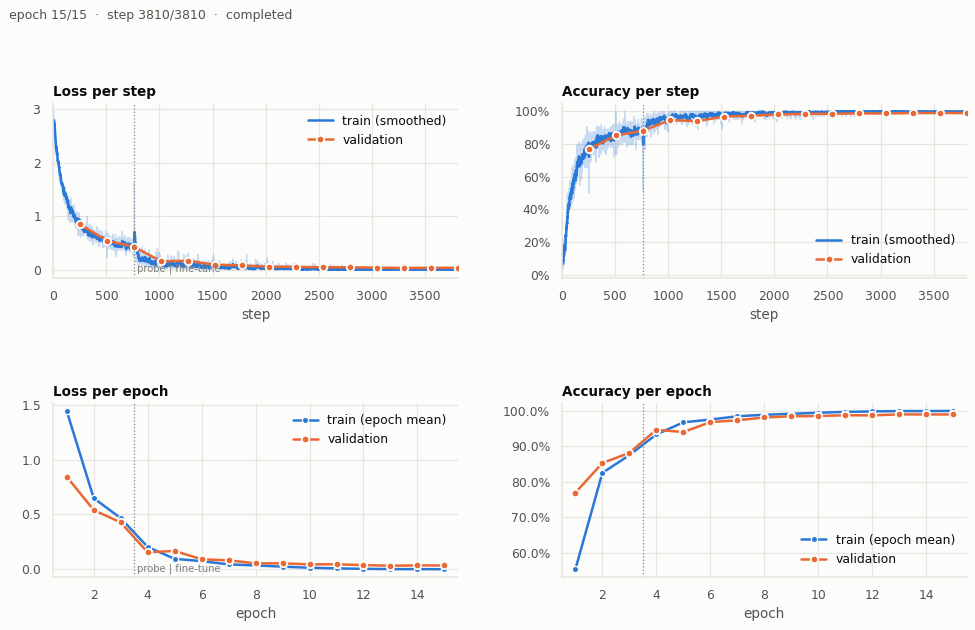

Epoch 4: backbone unfrozen, fine-tuning the whole network.
Training: 100%|██████████| 3810/3810 [04:18<00:00, 14.74step/s, epoch=15/15, loss=0.0001, acc=100.00%, val_loss=0.0353, val_acc=99.00%, val_f1=0.9895, lr=1.09e-06]
Training completed after 3810 steps in 258.4s.
best validation at epoch 13 (val loss 0.0329, acc 99.02%) -> test acc 98.93%, macro F1 0.9889 | 4.3 min


Epoch-level metrics for the RGB model (Extra):


,phase,train_loss,train_acc,lr,val_loss,val_acc,f1
epoch,,,,,,,
1,probe,1.3166,0.6070,1.000e-04,0.7428,0.8109,0.8017
2,probe,0.5661,0.8525,9.891e-05,0.4711,0.8769,0.8709
3,probe,0.3996,0.8911,9.568e-05,0.3728,0.9002,0.8959
4,fine-tune,0.1270,0.9566,9.045e-05,0.1081,0.9620,0.9610
5,fine-tune,0.0614,0.9802,8.346e-05,0.1355,0.9528,0.9526
6,fine-tune,0.0431,0.9851,7.500e-05,0.0669,0.9763,0.9757
7,fine-tune,0.0342,0.9879,6.545e-05,0.0590,0.9809,0.9802
8,fine-tune,0.0176,0.9941,5.523e-05,0.0497,0.9841,0.9835
9,fine-tune,0.0183,0.9939,4.477e-05,0.0449,0.9861,0.9857



Epoch-level metrics for the 13-band model (Extra):


,phase,train_loss,train_acc,lr,val_loss,val_acc,f1
epoch,,,,,,,
1,probe,1.4434,0.5534,1.000e-04,0.8447,0.7694,0.7629
2,probe,0.6484,0.8252,9.891e-05,0.5400,0.8530,0.8488
3,probe,0.4669,0.8751,9.568e-05,0.4273,0.8817,0.8779
4,fine-tune,0.2042,0.9336,9.045e-05,0.1553,0.9469,0.9460
5,fine-tune,0.0957,0.9678,8.346e-05,0.1676,0.9404,0.9413
6,fine-tune,0.0748,0.9756,7.500e-05,0.0918,0.9683,0.9679
7,fine-tune,0.0451,0.9849,6.545e-05,0.0815,0.9735,0.9725
8,fine-tune,0.0355,0.9891,5.523e-05,0.0548,0.9815,0.9808
9,fine-tune,0.0245,0.9919,4.477e-05,0.0546,0.9848,0.9840


In [ ]:
"""
Extra Experiment: Default Recipe + Augmentation
-----------------------------------------------
This experiment serves as an additional check to see if the findings hold
when using the default baseline recipe with data augmentation applied to
both the RGB and the 13-band models.
"""

# 1. Execute the extra experiment (will load from disk if already saved)
print("Running Extra Experiment (Default Recipe + Augmentation)...")
results_extra = run_experiment(EXPERIMENT_EXTRA, data)

# 2. Display the summarized epoch-level metrics for the RGB arm
print("\nEpoch-level metrics for the RGB model (Extra):")
display(epoch_table(results_extra["vit_rgb"].history))

# 3. Display the summarized epoch-level metrics for the 13-band arm
print("\nEpoch-level metrics for the 13-band model (Extra):")
display(epoch_table(results_extra["vit_all_bands"].history))

**Takeaway:** the same answer with a different recipe: 13 bands can match RGB on validation, but not
on test.

* With the default recipe and augmentation, both models reach 99.02% validation accuracy, and the
  13-band model even has the lowest validation loss of any run in this notebook (0.0329).
* On test it is behind again: 98.93% (58 wrong) against 99.11% (48 wrong); 36 vs 26 disagreements,
  p = 0.25, not significant. At this level, small validation differences do not reliably carry over
  to the test split.
* A pattern seen in every run: the 13-band model starts lower while the backbone is frozen (77% vs
  81% validation accuracy after epoch 1, 88% vs 90% after epoch 3), because the pretrained first
  layer was made for RGB, and it catches up once the whole network is fine-tuned.

## 11. Compare the arms

All runs side by side: the summary table, the paired tests, training curves, per-class results and
the errors.

In [ ]:
"""
Final Evaluation: Aggregated Results
------------------------------------
Merge the results from all experiments (Baseline, Experiment 2, Experiment 3,
and Extra) into a single dictionary and display the summarized metrics table.
"""

# 1. Aggregate results from all experimental runs
print("Aggregating results from all experiments...")
results = results_2_baseline | results_2 | results_3 | results_extra

# 2. Display the final summary table of evaluation metrics
print("\nSummary of test metrics across all arms:")
display(results_table(results))

Aggregating results from all experiments...

Summary of test metrics across all arms:


,bands,augment,optimizer,lr,batch,probe,params (M),epochs run,best epoch,best val loss,val acc,test acc,test wrong,test macro F1,minutes
arm,,,,,,,,,,,,,,,
vit_rgb_baseline,3,False,adamw,1.000e-04,64,3,21.6695,13/15,8,0.0373,0.9896,0.9906,51,0.9904,2.9247
vit_rgb_tuned,3,False,adamw,1.178e-04,256,0,21.6695,12/15,7,0.0331,0.9909,0.9913,47,0.9912,2.6969
vit_rgb_tuned_aug,3,True,adamw,1.178e-04,256,0,21.6695,15/15,11,0.0357,0.9907,0.9909,49,0.9907,3.8192
vit_all_bands_t20,13,False,adamw,1.178e-04,256,0,22.6526,15/15,12,0.0571,0.9861,0.9887,61,0.9885,3.5544
vit_rgb,3,True,adamw,1.000e-04,64,3,21.6695,15/15,15,0.0361,0.9902,0.9911,48,0.9910,3.9444
vit_all_bands,13,True,adamw,1.000e-04,64,3,22.6526,15/15,13,0.0329,0.9902,0.9893,58,0.9889,4.3122


**Takeaway:** all runs sit in a very narrow band near the ceiling, so differences have to be judged
with a paired test (next table), not by eye.

* The six main runs score between 98.87% and 99.13% on test: 47 to 61 wrong tiles out of 5,400. The
  whole study plays out within 14 tiles.
* Tuning the recipe gained 4 tiles over the baseline; augmentation changed 2.
* The two 13-band runs have the most errors (61 and 58), and with the tuned recipe the 13-band model
  is the only run with a validation loss above 0.04.
* The 13-band model has about 1 million more parameters (22.7 M vs 21.7 M), all in its wider first
  layer.

In [ ]:
"""
Statistical Comparisons (McNemar's Test)
----------------------------------------
Perform paired statistical comparisons between specific models to determine
if the differences in their performance are statistically significant.
"""

# 1. Add the Experiment 3b runs to the results, and take the Experiment 3 arm names from them
results = results | {r.arm.name: r for r in runs_3b.values()}
E3_RGB = runs_3b[(best_trial.number, "rgb")].arm.name
E3_ALL_BANDS = runs_3b[(best_trial.number, "all_bands")].arm.name

# 2. Define the specific pairwise comparisons to evaluate
print("Evaluating paired statistical comparisons...")
COMPARISONS = (
    Comparison("E2 · does the tuned recipe beat the baseline? (for information)", "vit_rgb_baseline", "vit_rgb_tuned"),
    Comparison("E2 · does augmentation help? (the decision, validation split)", "vit_rgb_tuned", "vit_rgb_tuned_aug", split="val"),
    Comparison("E2 · does augmentation help? (for information, test split)", "vit_rgb_tuned", "vit_rgb_tuned_aug"),
    Comparison("E3 · main question: do 13 bands beat RGB with the tuned recipe?", E3_RGB, E3_ALL_BANDS),
    Comparison("Extra · 13 bands vs RGB with the default recipe + augmentation", "vit_rgb", "vit_all_bands"),
)

# 3. Skip comparisons whose models are missing, instead of crashing
missing = [c for c in COMPARISONS if c.baseline not in results or c.treatment not in results]
for c in missing:
    print(f"Skipped (model not found): {c.question}")
COMPARISONS = tuple(c for c in COMPARISONS if c not in missing)

# 4. Display the comparison table
display(comparison_table(results, COMPARISONS))

Evaluating paired statistical comparisons...


,baseline,treatment,split,baseline acc,treatment acc,Δ acc (points),Δ macro F1,baseline only right,treatment only right,McNemar p
question,,,,,,,,,,
E2 · does the tuned recipe beat the baseline? (for information),vit_rgb_baseline,vit_rgb_tuned,test,0.9906,0.9913,0.0741,8.271e-04,18,22,0.6358
"E2 · does augmentation help? (the decision, validation split)",vit_rgb_tuned,vit_rgb_tuned_aug,val,0.9909,0.9907,-0.0185,-1.923e-04,25,24,1.0000
"E2 · does augmentation help? (for information, test split)",vit_rgb_tuned,vit_rgb_tuned_aug,test,0.9913,0.9909,-0.0370,-5.738e-04,22,20,0.8776
E3 · main question: do 13 bands beat RGB with the tuned recipe?,vit_rgb_tuned,vit_all_bands_t20,test,0.9913,0.9887,-0.2593,-0.0028,44,30,0.1302
Extra · 13 bands vs RGB with the default recipe + augmentation,vit_rgb,vit_all_bands,test,0.9911,0.9893,-0.1852,-0.0021,36,26,0.2529


**Takeaway:** no planned comparison is significant on its own, but together they give a clear
answer: the 13 bands did not help this model, and if anything they cost a few tiles.

* *Tuned recipe vs baseline* (for information): +0.07 points for the tuned recipe (right alone on 22
  tiles vs 18 for the baseline), p = 0.64. The search lowered the validation loss but did not
  produce a measurably better model on test.
* *Augmentation:* p = 1.0 on validation (the decision) and 0.88 on test (for information). No effect.
* **Main question, 13 bands vs RGB with the tuned recipe:** −0.26 points for 13 bands (RGB right
  alone on 44 tiles, 13 bands on 30), p = 0.13. Not significant; the direction favours RGB.
* *Extra, 13 bands vs RGB with the default recipe and augmentation:* −0.19 points (RGB right alone
  on 36 tiles, 13 bands on 26), p = 0.25. Same direction, same verdict.

Together with Experiment 3b, all six same-recipe RGB-vs-13-band pairs in this notebook favour RGB,
one of them significantly (trial 23).

### 11.1 Training curves of the three experiments

Per-epoch loss (left) and accuracy (right) of the runs of each experiment: dashed = training,
solid = validation, dot = the epoch whose weights were kept.

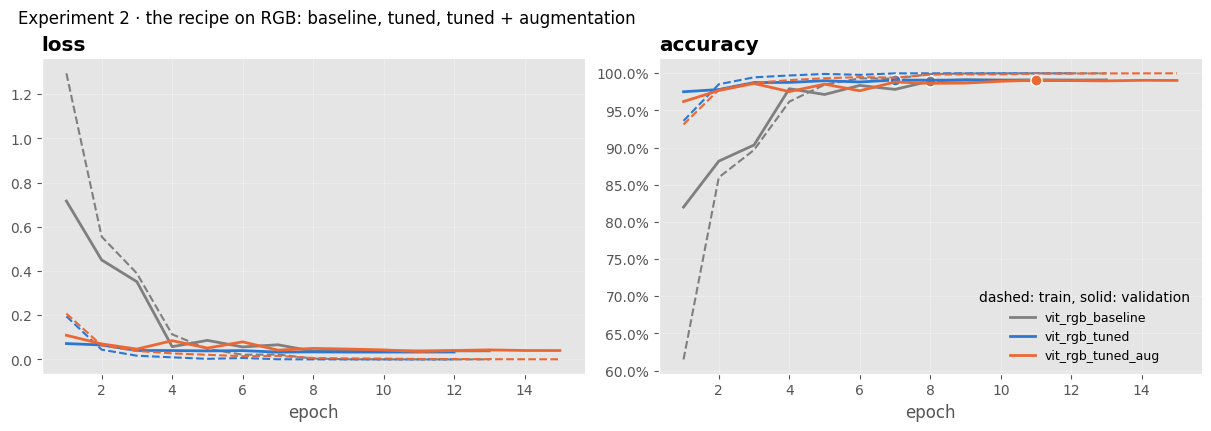

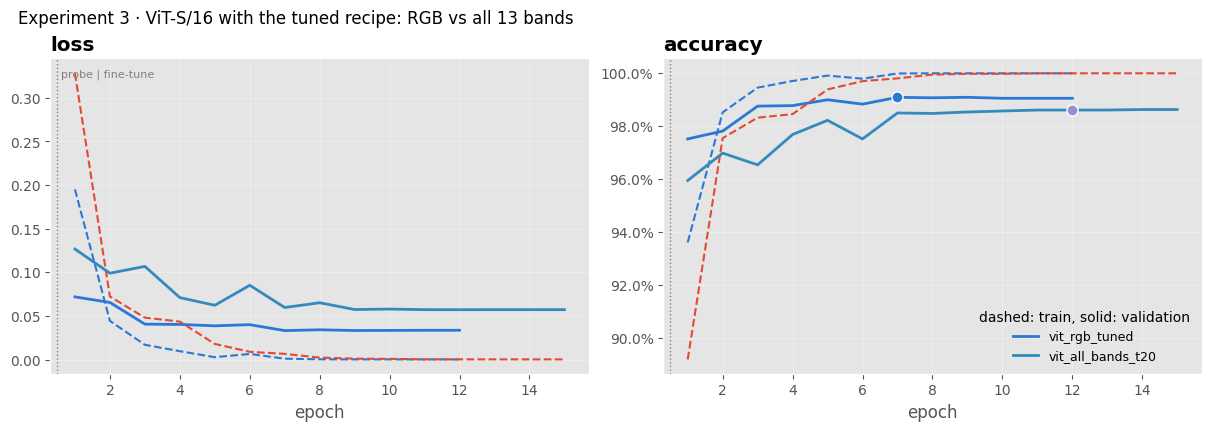

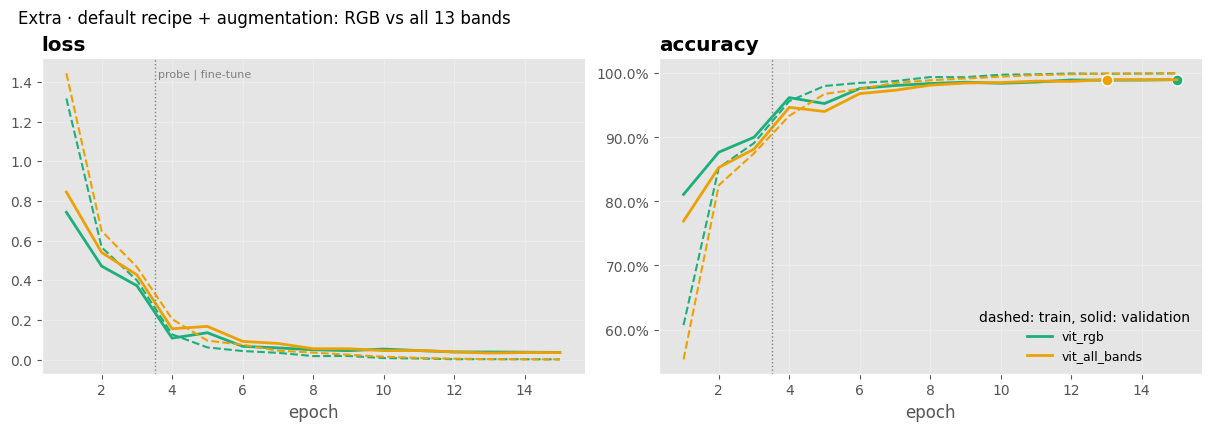

In [ ]:
"""
Training Curves Visualization
-----------------------------
Plot the training and validation loss/accuracy curves for all experiments.
This helps to visually compare the learning dynamics of different arms.
"""
from collections import defaultdict

# Give each Experiment 3b arm the colour of the arm it stands in for (RGB tuned or 13 bands tuned);
# any other unknown arm name gets a new colour instead of raising KeyError.
palette = iter(plt.cm.tab10.colors)
for r in runs_3b.values():
    if r.arm.name not in ARM_COLORS:
        reference = "vit_rgb_tuned" if r.arm.bands == RGB_BANDS else "vit_all_bands_tuned"
        ARM_COLORS[r.arm.name] = ARM_COLORS.get(reference, next(palette))
ARM_COLORS = defaultdict(lambda: next(palette), ARM_COLORS)

# 1. Define the main comparison pair for the primary research question
main_pair = {RGB_REFERENCE.arm.name: RGB_REFERENCE, **results_3}

# 2. Plot the curves for Experiment 2 (baseline vs. tuned vs. tuned + aug)
plot_curves(
    results_2_baseline | results_2,
    "Experiment 2 · the recipe on RGB: baseline, tuned, tuned + augmentation"
)

# 3. Plot the curves for Experiment 3 (RGB vs. 13 bands with tuned recipe)
plot_curves(
    main_pair,
    "Experiment 3 · ViT-S/16 with the tuned recipe: RGB vs all 13 bands"
)

# 4. Plot the curves for the Extra Experiment (RGB vs. 13 bands with default recipe)
plot_curves(
    results_extra,
    "Extra · default recipe + augmentation: RGB vs all 13 bands"
);


**Takeaway:** the 13-band model is not under-trained. It fits the training tiles as well as RGB
does but generalises slightly worse.

* *Experiment 2 (RGB only):* the baseline (grey) starts with three frozen-backbone epochs; the tuned
  runs (blue, orange) fine-tune from the start and are above 96% after one epoch. All three meet by
  epoch 4–5. With augmentation (orange) the training loss falls more slowly, since the model sees a
  new variant of every tile each epoch, but validation ends in the same place.
* *Experiment 3:* the 13-band validation loss is above RGB's at every epoch and its accuracy below,
  with bigger wobbles at epochs 3 and 6. Both training losses reach ~0, so the gap is not a matter
  of training too little.
* *Extra:* during the three frozen-backbone epochs the 13-band model lags; it then converges slowly
  and reaches RGB's validation accuracy only at epochs 13–15.

*Note on the saved Experiment 3 figure:* the 13-band run is drawn in mismatched default colours
(steel-blue validation line, red dashed training line, purple dot) because its name only got a
colour later; re-running the cell draws it all in purple.

,vit_rgb_baseline,vit_rgb_tuned,vit_rgb_tuned_aug,vit_all_bands_t20,vit_rgb,vit_all_bands,vit_rgb_t23,vit_all_bands_t23,vit_rgb_t38,vit_all_bands_t38,vit_rgb_t37,vit_all_bands_t37,vit_rgb_t22,vit_all_bands_t22
AnnualCrop,0.9900,0.9916,0.9958,0.9892,0.9941,0.9916,0.9916,0.9832,0.9899,0.9883,0.9916,0.9900,0.9925,0.9867
Forest,0.9967,0.9959,0.9967,0.9951,0.9967,0.9943,0.9959,0.9918,0.9951,0.9959,0.9917,0.9951,0.9967,0.9934
HerbaceousVegetation,0.9799,0.9834,0.9816,0.9783,0.9807,0.9816,0.9774,0.9696,0.9782,0.9758,0.9781,0.9775,0.9809,0.9765
Highway,0.9960,0.9930,0.9920,0.9849,0.9930,0.9869,0.9900,0.9819,0.9880,0.9809,0.9880,0.9820,0.9880,0.9859
Industrial,0.9920,0.9910,0.9900,0.9900,0.9930,0.9880,0.9930,0.9870,0.9880,0.9910,0.9901,0.9910,0.9930,0.9870
Pasture,0.9860,0.9911,0.9861,0.9861,0.9886,0.9836,0.9810,0.9760,0.9834,0.9732,0.9800,0.9744,0.9886,0.9810
PermanentCrop,0.9786,0.9842,0.9824,0.9812,0.9825,0.9851,0.9813,0.9738,0.9787,0.9803,0.9804,0.9831,0.9831,0.9850
Residential,0.9937,0.9937,0.9964,0.9937,0.9946,0.9901,0.9973,0.9919,0.9928,0.9928,0.9937,0.9937,0.9973,0.9910
River,0.9953,0.9934,0.9906,0.9886,0.9924,0.9905,0.9905,0.9924,0.9895,0.9839,0.9905,0.9858,0.9886,0.9915
SeaLake,0.9959,0.9951,0.9950,0.9975,0.9942,0.9975,0.9967,0.9984,0.9951,0.9967,0.9943,0.9959,0.9967,0.9984


,test tiles,vit_rgb_baseline,vit_rgb_tuned,vit_rgb_tuned_aug,vit_all_bands_t20,vit_rgb,vit_all_bands,vit_rgb_t23,vit_all_bands_t23,vit_rgb_t38,vit_all_bands_t38,vit_rgb_t37,vit_all_bands_t37,vit_rgb_t22,vit_all_bands_t22
AnnualCrop,596,593,593,593,594,592,590,593,587,591,592,593,593,594,592
Forest,608,605,605,607,606,608,606,605,603,605,605,600,605,607,604
HerbaceousVegetation,573,561,562,561,563,560,561,563,559,561,564,557,565,565,562
Highway,496,496,496,496,490,495,491,493,488,493,489,494,490,493,489
Industrial,501,496,497,493,495,494,492,498,495,496,496,498,495,497,494
Pasture,396,388,392,390,389,391,390,387,386,385,382,392,381,391,388
PermanentCrop,538,526,528,530,522,532,530,525,520,528,522,524,525,524,525
Residential,554,551,549,553,551,553,551,552,550,549,550,551,551,552,550
River,529,526,524,525,521,525,524,522,522,520,518,520,520,520,523
SeaLake,609,607,607,603,608,602,607,607,609,608,609,607,607,607,608


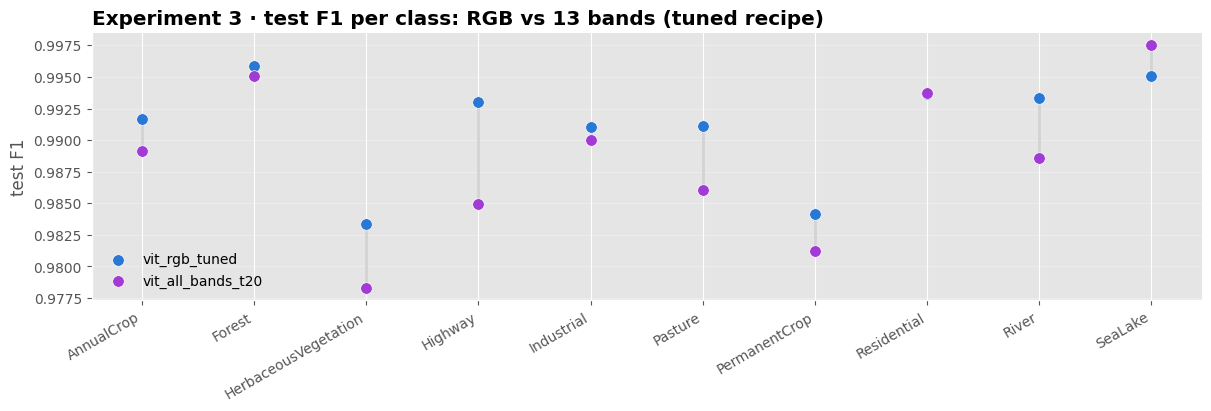

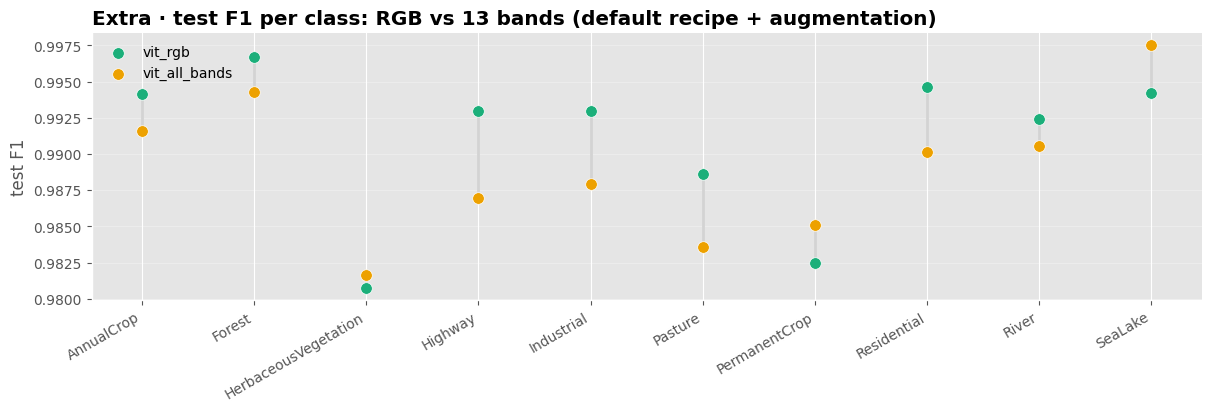

In [ ]:
"""
Per-Class Performance Analysis
------------------------------
Evaluate and visualize the F1 score and correctness per class across experiments.
"""

# 1. Plot per-class F1 scores for Experiment 3 (RGB vs. 13 bands with tuned recipe)
plot_per_class_f1(
    main_pair,
    data.classes,
    "Experiment 3 · test F1 per class: RGB vs 13 bands (tuned recipe)"
)

# 2. Plot per-class F1 scores for the Extra Experiment (default recipe + augmentation)
plot_per_class_f1(
    results_extra,
    data.classes,
    "Extra · test F1 per class: RGB vs 13 bands (default recipe + augmentation)"
)

# 3. Display tabular F1 scores for all experiments per class
display(per_class_f1(results, data.classes))

# 4. Display the raw count of correct test tiles per class for all experiments
per_class_correct(results, data.classes)


**Takeaway:** the extra bands do not help where one would expect them to. In F1, the 13-band model
is lower on 8 of the 10 classes, level on Residential and better only on SeaLake (first figure).

* *Experiment 3:* it loses the most tiles on Highway (−6) and PermanentCrop (−6), then Pasture and
  River (−3 each). The crop and grassland classes (AnnualCrop, PermanentCrop, HerbaceousVegetation,
  Pasture) lose 7 tiles together, the opposite of the expectation that the infrared bands would help
  vegetation most.
* *Across the five recipes of Experiment 3b* the pattern is stable: Highway (−23 tiles in total,
  worse under all 5 recipes), Pasture (−21, worse under all 5) and PermanentCrop (−15) lose
  consistently. SeaLake is the only class that improves consistently (better under 4 of 5, +5
  tiles), and it is the class that stood out most in the infrared in the EDA heat map.
* All per-class F1 scores are about 0.97 or higher, so per-class differences are only a handful of
  tiles. That is why the conclusion rests on the paired test over all tiles, not on these numbers.

,test acc,test macro F1,wrong,classes predicted,median confidence (right),median confidence (wrong)
model,,,,,,
vit_rgb_baseline,0.9906,0.9904,51,10,1.0000,0.8120
vit_rgb_tuned,0.9913,0.9912,47,10,1.0000,0.9064
vit_rgb_tuned_aug,0.9909,0.9907,49,10,1.0000,0.8847
vit_all_bands_t20,0.9887,0.9885,61,10,1.0000,0.9480
vit_rgb,0.9911,0.9910,48,10,1.0000,0.8320
vit_all_bands,0.9893,0.9889,58,10,1.0000,0.7543
vit_rgb_t23,0.9898,0.9895,55,10,1.0000,0.8483
vit_all_bands_t23,0.9850,0.9846,81,10,1.0000,0.8255
vit_rgb_t38,0.9881,0.9879,64,10,0.9998,0.7942


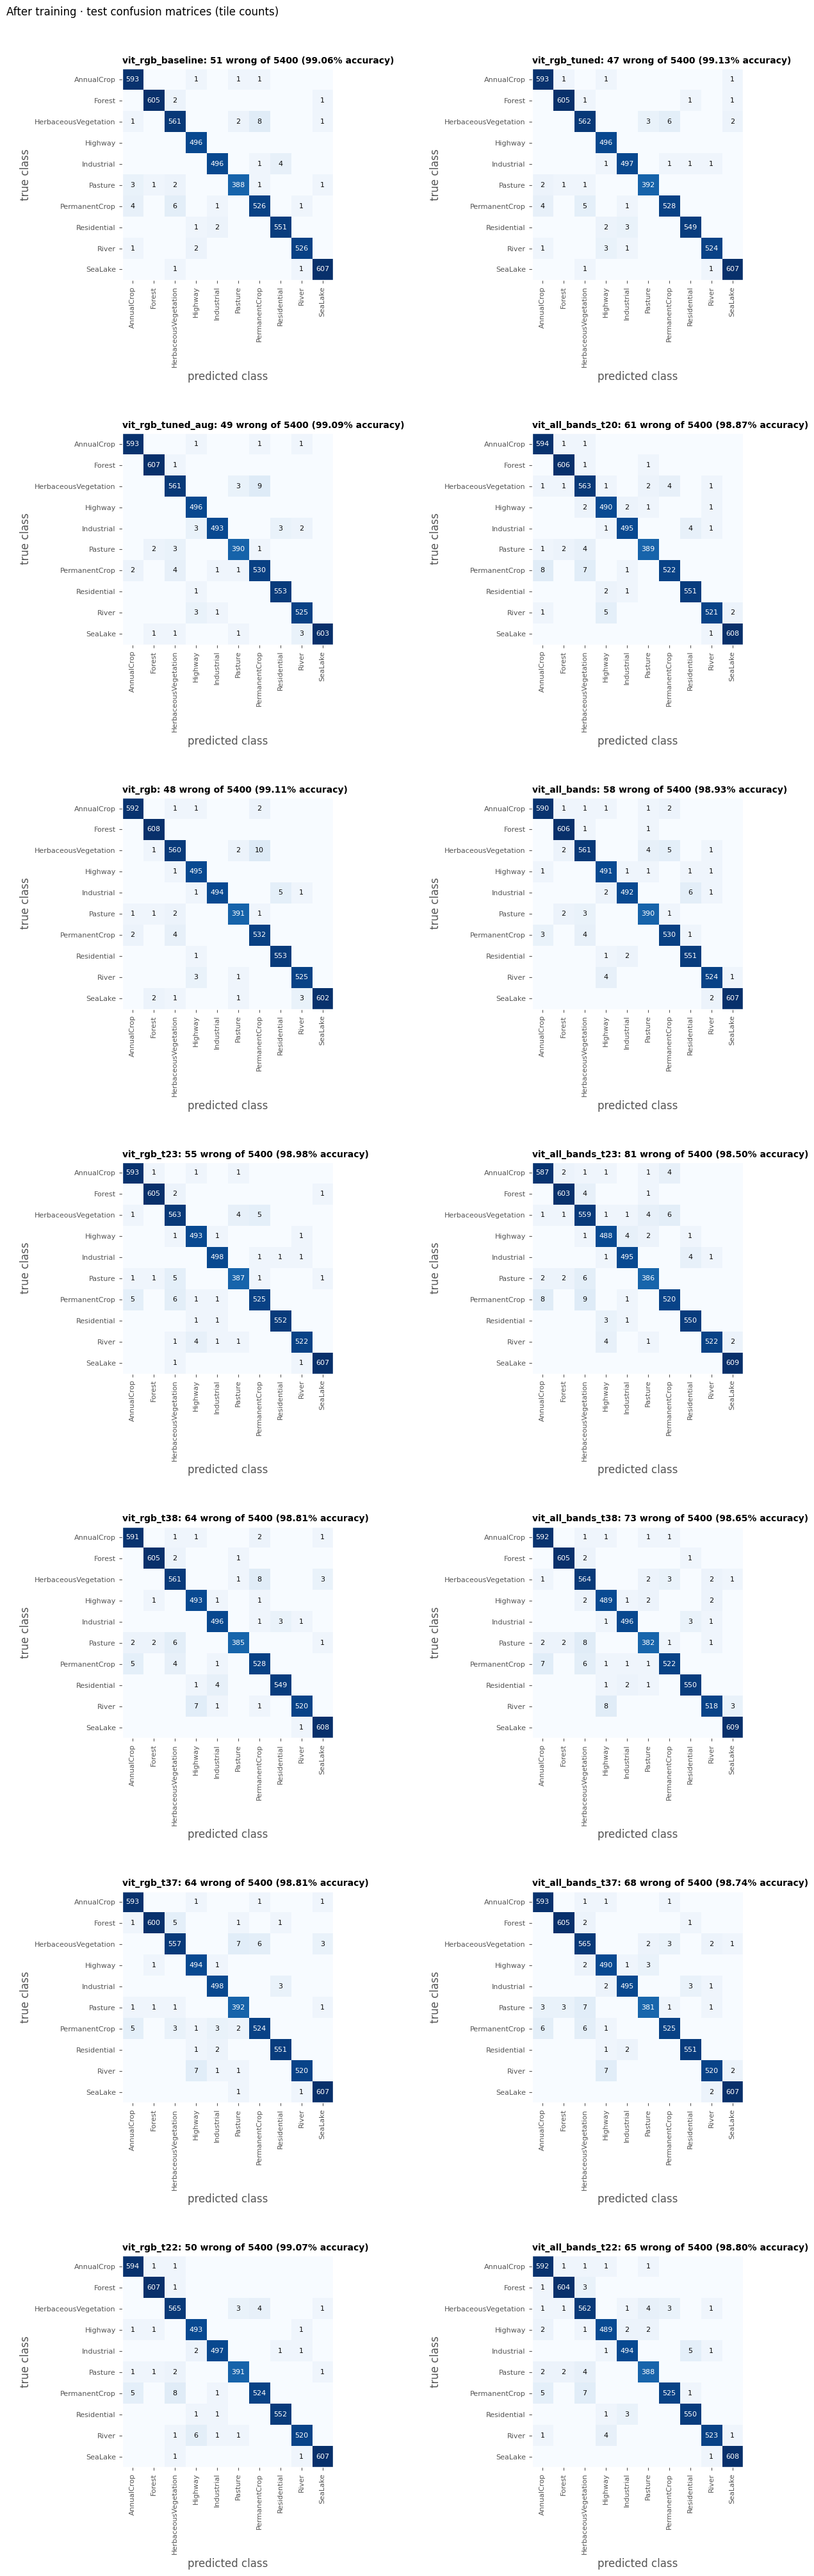

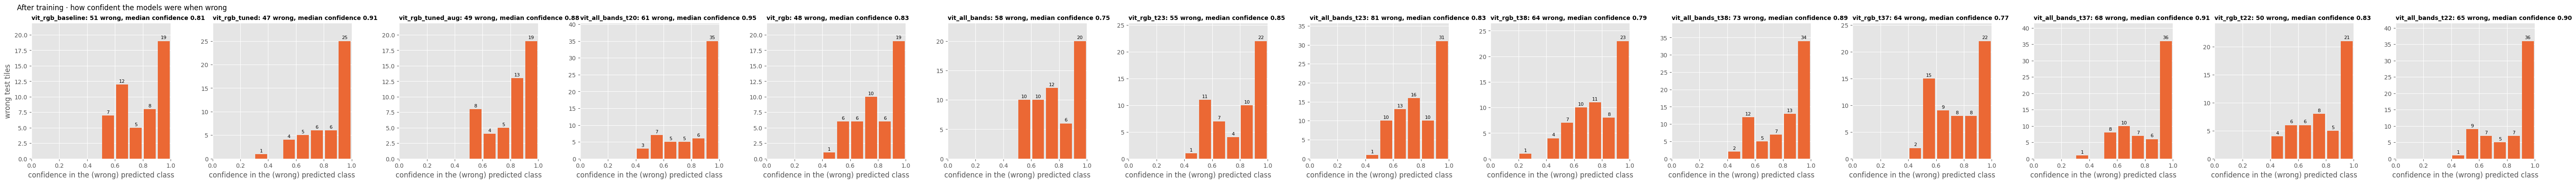

In [ ]:
"""
Post-Training Evaluation & Error Analysis
-----------------------------------------
Visualize confusion matrices and error confidence distributions for all trained models,
and summarize their final performance metrics.
"""

# 1. Plot test confusion matrices showing absolute tile counts for all models
plot_confusion_matrices(
    results,
    data.classes,
    "After training · test confusion matrices (tile counts)"
)

# 2. Plot the distribution of confidence scores for incorrect predictions
plot_wrong_confidence(
    results,
    "After training · how confident the models were when wrong"
)

# 3. Display the comprehensive predictions table (accuracy, macro F1, error counts, confidences)
predictions_table(results)


**Takeaway:** after training every model uses all ten classes and puts almost every tile on the
diagonal. The remaining errors are between the look-alike classes from the EDA, and the models are
confidently wrong.

* The 13-band model adds errors in two places (Experiment 3 pair): among the farmland classes (e.g.
  PermanentCrop taken for AnnualCrop 8 times vs 4 for RGB; Pasture taken for HerbaceousVegetation)
  and between line-shaped and built-up classes (Highway misclassified 6 times vs never for RGB;
  River → Highway; Industrial → Residential). It fixes a few elsewhere.
* All models are sure of themselves even when wrong: the median confidence of a wrong prediction is
  0.75–0.95. So a model's confidence cannot be used to catch its mistakes.

,true,predicted,confidence
test tile,,,
3144,Pasture,Forest,0.9999
4594,River,Highway,0.9987
2313,Industrial,Residential,0.9986
1488,HerbaceousVegetation,Pasture,0.9986
3580,PermanentCrop,HerbaceousVegetation,0.9976
2964,Pasture,HerbaceousVegetation,0.9962
3450,PermanentCrop,HerbaceousVegetation,0.9955
1329,HerbaceousVegetation,PermanentCrop,0.9946
4239,Residential,Highway,0.9944


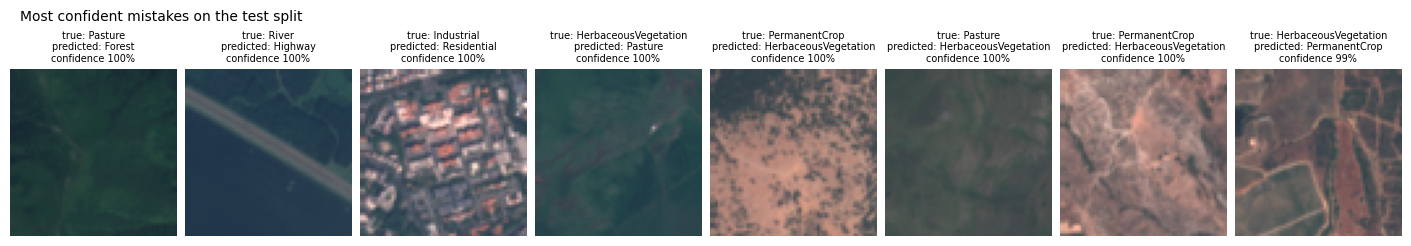

In [ ]:
"""
Error Analysis: Most Confident Mistakes
---------------------------------------
Identify the best performing model and visualize the test tiles where it made
incorrect predictions with the highest confidence.
"""

# 1. Identify the best model based on test accuracy
best_arm = max(results, key=lambda name: results[name].test_accuracy)

# 2. Check if probability scores were saved for this run
if results[best_arm].y_prob is None:
    print(f"{best_arm}: no probabilities saved with this run; delete {RESULTS_DIR / best_arm} and rerun it to get them")
else:
    # 3. Visualize the most confident mistakes made by the best model
    show_mistakes(results[best_arm], data, n=8)

    # 4. Display a detailed table of these most confident mistakes
    display(most_confident_mistakes(results[best_arm], data.classes))


**Takeaway:** some of the remaining errors are ambiguous tiles rather than clear model failures.
Shown are the wrong test tiles that the best run (`vit_rgb_tuned`, 99.13%) was most sure about, all
at 99–100% confidence. Most are between the vegetation classes (Pasture, HerbaceousVegetation,
PermanentCrop, Forest), and several look like the predicted class even to the eye: a road crossing
a "River" tile predicted as Highway, a bare field labelled PermanentCrop predicted as
HerbaceousVegetation. No extra band can resolve this kind of label ambiguity.

### 11.2 The full training figure of every saved run

The live 2 × 2 figure of each run (per step on top, per epoch below), redrawn from the saved
histories; useful for inspecting one run in detail.

In [ ]:
"""
Training History Visualization
------------------------------
Iterate through all experimental results and display the full training history plots.
Each plot shows the live figure of the saved run:
- Top row: metrics per step
- Bottom row: metrics per epoch
"""

# Iterate over every saved result and display its training history plot
for experiment_name, experiment_result in results.items():
    # Generate and display the plot for the current experiment
    display(plot_history(experiment_result.history, title=experiment_name))


## 12. Save the results (Colab only, optional)

The two cells below are for Google Colab: mount Google Drive if you want to keep `results/` there,
and download `results.zip` (histories, predictions, summaries, the Optuna database and the band
statistics; about 100 MB, no model weights). With that folder restored next to the notebook, every
cell above reloads its saved result instead of retraining.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import shutil
from google.colab import files

RESULTS_DIR = '/content/results'   # change to your folder path

shutil.make_archive('/content/results', 'zip', RESULTS_DIR)
files.download('/content/results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

**Answer to the research question: no.** With a pretrained ViT-S/16 on EuroSAT, giving the model all
13 Sentinel-2 bands instead of RGB did not improve land-use classification. Both inputs reach about
99% test accuracy, and the 13-band model is slightly behind in all six same-recipe comparisons
(main test p = 0.13; significant for one of the five recipes of Experiment 3b).

**What it may mean.** A backbone pretrained on RGB photos gets most of its value from RGB. At ~99%
there is little left to gain, part of the remaining error is label ambiguity, and the extra bands
enter through a first layer that was never trained for them. Extra bands might pay off with a
backbone pretrained on multispectral satellite images, or on a harder task where RGB is not already
near the ceiling; neither was tested here.

**Caveats and how the material is used.**

* All numbers come from a single seed (`TrainingConfig.seed`). The McNemar p-values describe the
  test tiles, not training randomness; rerunning Experiment 3 with two or three more seeds would
  tighten the comparison. Experiment 3b (five recipes, five paired tests, all in RGB's favour) is
  the robustness check that fitted the compute budget.
* Near-duplicate tiles across splits cannot be ruled out (section 4).
* Every choice (recipe, augmentation) was made on the validation split; the test split was scored
  once per final run.
* These tables and figures are the material for the results and discussion of the project report:
  section 9 gives the "before" picture, section 11 the "after".

*Note:* results saved by an older version of this notebook still load; their per-epoch training loss
is then a plain mean over batches (no batch sizes were saved), and they have no validation
predictions.